# Análise da baseline COPA/Lattes — inline HTML/JSON separados

Este notebook analisa a baseline a partir de uma pasta extraída ou de um arquivo `.tar.gz`.

Ele calcula:

- custo de resposta;
- custo corrigido de avaliação a partir de `judge_votes.jsonl`;
- sucesso por maioria;
- sucesso unânime completo;
- consenso entre juízes;
- custo por sucesso;
- sucessos unânimes por 100k tokens;
- wasted tokens;
- discrepâncias no campo `agreement`;
- comportamento das respostas;
- lacunas de instrumentação dos traces;
- tabelas e gráficos para uso no artigo.

**Perspectiva analítica adotada:** como o fator `format` varia apenas para a estratégia `inline`, o notebook cria uma estratégia analítica chamada `strategy_view`:

- `inline` + `html` → `inline_html`
- `inline` + `json` → `inline_json`
- demais estratégias permanecem como `local_function`, `local_mcp` e `mcp`

Assim, as comparações principais usam cinco estratégias analíticas em vez de misturar HTML e JSON dentro de `inline`.


In [1]:
from pathlib import Path
import json
import tarfile
import zipfile
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 240)
pd.set_option("display.width", 220)

# ---------------------------------------------------------------------
# Entradas
# ---------------------------------------------------------------------
# Pode ser arquivo .tar.gz ou pasta extraída.
BASELINE_INPUT = Path("outputs/baseline_001/")
EXPERIMENT_JSON = Path("experiment.baseline.json")
QUESTIONS_JSON = Path("datasets/lattes/questions.json")

if not EXPERIMENT_JSON.exists() and Path("/mnt/data/experiment.baseline.json").exists():
    EXPERIMENT_JSON = Path("/mnt/data/experiment.baseline.json")

if not QUESTIONS_JSON.exists() and Path("/mnt/data/questions.json").exists():
    QUESTIONS_JSON = Path("/mnt/data/questions.json")

EXTRACT_DIR = Path("baseline_extract_notebook")
OUTPUT_DIR = Path("baseline_analysis_notebook_outputs")
FIG_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

print("BASELINE_INPUT:", BASELINE_INPUT.resolve() if BASELINE_INPUT.exists() else BASELINE_INPUT)
print("EXPERIMENT_JSON:", EXPERIMENT_JSON.resolve() if EXPERIMENT_JSON.exists() else EXPERIMENT_JSON)
print("QUESTIONS_JSON:", QUESTIONS_JSON.resolve() if QUESTIONS_JSON.exists() else QUESTIONS_JSON)
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())


BASELINE_INPUT: /home/michel/repos/doutorado/copa-benchmark/outputs/baseline_001
EXPERIMENT_JSON: /home/michel/repos/doutorado/copa-benchmark/experiment.baseline.json
QUESTIONS_JSON: /home/michel/repos/doutorado/copa-benchmark/datasets/lattes/questions.json
OUTPUT_DIR: /home/michel/repos/doutorado/copa-benchmark/baseline_analysis_notebook_outputs


## 1. Carregamento e normalização dos dados

In [2]:
def safe_extract_tar_gz(tar_path: Path, extract_dir: Path) -> Path:
    extract_dir.mkdir(parents=True, exist_ok=True)
    marker = extract_dir / ".extracted_from"
    if marker.exists() and marker.read_text(encoding="utf-8") == str(tar_path.resolve()):
        return extract_dir

    for child in extract_dir.iterdir():
        if child.name == ".extracted_from":
            continue
        if child.is_dir():
            import shutil
            shutil.rmtree(child)
        else:
            child.unlink()

    with tarfile.open(tar_path, "r:gz") as tf:
        try:
            tf.extractall(extract_dir, filter="data")
        except TypeError:
            tf.extractall(extract_dir)

    marker.write_text(str(tar_path.resolve()), encoding="utf-8")
    return extract_dir


def find_baseline_dir(root: Path) -> Path:
    root = Path(root)
    if root.is_file() and root.suffixes[-2:] == [".tar", ".gz"]:
        root = safe_extract_tar_gz(root, EXTRACT_DIR)

    candidates = []
    if root.is_dir():
        for p in [root, *root.rglob("*")]:
            if p.is_dir() and (p / "answers.jsonl").exists() and (p / "evals.jsonl").exists():
                candidates.append(p)

    if not candidates:
        raise FileNotFoundError(f"Não encontrei answers.jsonl/evals.jsonl dentro de {root}")

    candidates = sorted(candidates, key=lambda p: (not (p / "judge_votes.jsonl").exists(), len(str(p))))
    return candidates[0]


def read_jsonl(path: Path):
    rows = []
    if not path.exists():
        return rows
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


baseline_dir = find_baseline_dir(BASELINE_INPUT)
answers_raw = read_jsonl(baseline_dir / "answers.jsonl")
evals_raw = read_jsonl(baseline_dir / "evals.jsonl")
votes_raw = read_jsonl(baseline_dir / "judge_votes.jsonl")
queries_raw = read_jsonl(baseline_dir / "queries.jsonl")

experiment = json.loads(EXPERIMENT_JSON.read_text(encoding="utf-8")) if EXPERIMENT_JSON.exists() else {}
questions_doc = json.loads(QUESTIONS_JSON.read_text(encoding="utf-8")) if QUESTIONS_JSON.exists() else {}

print("Baseline dir:", baseline_dir.resolve())
print("answers:", len(answers_raw))
print("evals:", len(evals_raw))
print("judge_votes:", len(votes_raw))
print("queries:", len(queries_raw))
print("judges:", experiment.get("evaluation", {}).get("judges"))


Baseline dir: /home/michel/repos/doutorado/copa-benchmark/outputs/baseline_001
answers: 1200
evals: 1200
judge_votes: 3600
queries: 1200
judges: ['juiz-gpt', 'juiz-gemini', 'juiz-claude']


In [3]:
question_meta_rows = []
for q in questions_doc.get("questions", []):
    question_meta_rows.append({
        "questionId": q.get("id"),
        "question_text_catalog": q.get("question"),
        "question_tags_catalog": tuple(q.get("tags") or []),
        "contextBlock_catalog": tuple(q.get("contextBlock") or []),
        "validation_type_catalog": (q.get("validation") or {}).get("type"),
    })

questions_meta = pd.DataFrame(question_meta_rows)
tag_definitions = questions_doc.get("tagDefinitions", {})

display(Markdown(f"""
**Escopo detectado**

- Instâncias declaradas: `{len(experiment.get("scope", {}).get("instances", []))}`
- Perguntas declaradas: `{len(experiment.get("scope", {}).get("questions", []))}`
- Modelos de resposta: `{experiment.get("factors", {}).get("model")}`
- Estratégias originais: `{experiment.get("factors", {}).get("strategy")}`
- Formatos originais: `{experiment.get("factors", {}).get("format")}`
- Estratégias analíticas: `inline_html`, `inline_json`, `local_function`, `local_mcp`, `mcp`
- Juízes: `{experiment.get("evaluation", {}).get("judges")}`
"""))

display(questions_meta)



**Escopo detectado**

- Instâncias declaradas: `5`
- Perguntas declaradas: `12`
- Modelos de resposta: `['gpt1', 'gpt2', 'gemini1', 'gemini2']`
- Estratégias originais: `['inline', 'local_function', 'local_mcp', 'mcp']`
- Formatos originais: `['html', 'json']`
- Estratégias analíticas: `inline_html`, `inline_json`, `local_function`, `local_mcp`, `mcp`
- Juízes: `['juiz-gpt', 'juiz-gemini', 'juiz-claude']`


,questionId,question_text_catalog,question_tags_catalog,contextBlock_catalog,validation_type_catalog
0,q_phd,Where and how long ago did the researcher complete their PhD?,"(factual, temporal)","(education,)",judge
1,q_field,What is the main field of knowledge in which this researcher works?,"(inferential, ranking)","(profile,)",judge
2,q_venue,Where does this researcher publish most frequently?,"(inferential, quantitative, ranking)","(pub,)",judge
3,q_coauth,Who are the most frequent co-authors of this researcher?,"(inferential, quantitative, ranking, matching)","(publications,)",judge
4,q_advpub,Does this researcher usually publish with their advisees?,"(inferential, cross-block, quantitative, matching)","(supervisions, supervisionsPublications)",judge
5,q_advareas,What are the research areas of this researcher’s advisees?,"(inferential,)","(supervision,)",judge
6,q_pubyear,What is the most relevant bibliographic production of this researcher in {pub_year}?,"(weak-data, temporal, ranking)","(publications2024,)",judge
7,q_en,Does this researcher speak English?,"(factual,)","(profile,)",judge
8,q_projfit_1,How does the candidate’s academic and professional background align with the project “{project}”?,"(inferential, cross-block)","(profile_projects,)",judge
9,q_projfit_2,How does the candidate’s academic and professional background align with the project “{project}”?,"(inferential, cross-block)","(profile, education, projects)",judge


In [4]:
def first_not_none(*values):
    for value in values:
        if value is not None:
            return value
    return None


def flatten_answers(rows):
    out = []
    for r in rows:
        ms = r.get("metricsSummary") or {}
        usage = r.get("usage") or {}
        timing = r.get("timing") or {}
        answer = r.get("answer") or ""
        out.append({
            "runId": r.get("runId"),
            "experimentId": r.get("experimentId"),
            "questionId": r.get("questionId"),
            "instanceId": r.get("instanceId"),
            "modelId": r.get("modelId"),
            "model": r.get("model"),
            "provider": r.get("provider"),
            "strategy": r.get("strategy"),
            "format": r.get("format"),
            "repeatIndex": r.get("repeatIndex"),
            "status_answer": r.get("status"),
            "errorMessage": r.get("errorMessage"),
            "question": r.get("question"),
            "questionTemplate": r.get("questionTemplate"),
            "answer": answer,
            "questionTags": tuple(r.get("questionTags") or []),
            "contextBlock": tuple(r.get("contextBlock") or []),
            "validationType": r.get("validationType"),
            "traceRef_answer": r.get("traceRef"),
            "inputTokens_answer": first_not_none(usage.get("inputTokens"), ms.get("inputTokens")),
            "outputTokens_answer": first_not_none(usage.get("outputTokens"), ms.get("outputTokens")),
            "totalTokens_answer": first_not_none(usage.get("totalTokens"), ms.get("totalTokens")),
            "cachedInputTokens_answer": first_not_none(usage.get("cachedInputTokens"), ms.get("cachedInputTokens")),
            "totalDurationMs_answer": first_not_none(ms.get("totalDurationMs"), timing.get("durationMs")),
            "strategyDurationMs": ms.get("strategyDurationMs"),
            "modelDurationMs": ms.get("modelDurationMs"),
            "toolDurationMs": ms.get("toolDurationMs"),
            "rateLimitWaitMs": ms.get("rateLimitWaitMs"),
            "retryCount": ms.get("retryCount"),
            "toolCalls": ms.get("toolCalls"),
            "functionCalls": ms.get("functionCalls"),
            "mcpToolCalls": ms.get("mcpToolCalls"),
            "modelCalls": ms.get("modelCalls"),
            "contextChars": ms.get("contextChars"),
            "contextBytes": ms.get("contextBytes"),
            "promptChars": ms.get("promptChars"),
            "answerChars": len(answer),
            "answerWords": len(re.findall(r"\w+", answer, flags=re.UNICODE)),
        })
    df = pd.DataFrame(out)
    for c in df.columns:
        if c.endswith("_answer") or c in [
            "strategyDurationMs", "modelDurationMs", "toolDurationMs", "rateLimitWaitMs",
            "retryCount", "toolCalls", "functionCalls", "mcpToolCalls", "modelCalls",
            "contextChars", "contextBytes", "promptChars", "answerChars", "answerWords",
        ]:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def flatten_evals(rows):
    out = []
    for r in rows:
        outcome = r.get("outcome") or {}
        corr = outcome.get("correctness") or {}
        comp = outcome.get("completeness") or {}
        out.append({
            "runId": r.get("runId"),
            "experimentId": r.get("experimentId"),
            "questionId": r.get("questionId"),
            "instanceId": r.get("instanceId"),
            "repeatIndex": r.get("repeatIndex"),
            "strategy_eval": r.get("strategy"),
            "status_eval": r.get("status"),
            "evaluationMethod": r.get("evaluationMethod"),
            "evaluationDurationMs_reported": r.get("evaluationDurationMs"),
            "evaluationInputTokens_reported": r.get("evaluationInputTokens"),
            "evaluationOutputTokens_reported": r.get("evaluationOutputTokens"),
            "evaluationTotalTokens_reported": r.get("evaluationTotalTokens"),
            "judgeCount_reported": r.get("judgeCount"),
            "judgeErrorCount_reported": r.get("judgeErrorCount"),
            "correctness_outcome_rating": corr.get("rating"),
            "correctness_outcome_agreement": corr.get("agreement"),
            "completeness_outcome_rating": comp.get("rating"),
            "completeness_outcome_agreement": comp.get("agreement"),
            "traceRef_eval": r.get("traceRef"),
            "contextBlocks_eval": tuple(r.get("contextBlocks") or []),
        })
    df = pd.DataFrame(out)
    for c in df.columns:
        if c.endswith("_reported"):
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def flatten_votes(rows):
    out = []
    for r in rows:
        for criterion in ["correctness", "completeness"]:
            c = (r.get("criterias") or {}).get(criterion) or {}
            out.append({
                "runId": r.get("runId"),
                "experimentId": r.get("experimentId"),
                "questionId": r.get("questionId"),
                "instanceId": r.get("instanceId"),
                "strategy": r.get("strategy"),
                "judgeId": r.get("judgeId"),
                "provider_judge": r.get("provider"),
                "model_judge": r.get("model"),
                "criterion": criterion,
                "rating": c.get("rating"),
                "justification": c.get("justification"),
                "status_vote": r.get("status"),
                "error_vote": r.get("error"),
                "inputTokens_vote": r.get("inputTokens"),
                "outputTokens_vote": r.get("outputTokens"),
                "totalTokens_vote": r.get("totalTokens"),
                "durationMs_vote": r.get("durationMs"),
                "traceRef_vote": r.get("traceRef"),
            })
    df = pd.DataFrame(out)
    for c in ["inputTokens_vote", "outputTokens_vote", "totalTokens_vote", "durationMs_vote"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


answers = flatten_answers(answers_raw)
evals = flatten_evals(evals_raw)
votes = flatten_votes(votes_raw)

print("answers:", answers.shape)
print("evals:", evals.shape)
print("votes:", votes.shape)
display(answers.head(3))
display(evals.head(3))
display(votes.head(3))


answers: (1200, 38)
evals: (1200, 20)
votes: (7200, 18)


,runId,experimentId,questionId,instanceId,modelId,model,provider,strategy,format,repeatIndex,status_answer,errorMessage,question,questionTemplate,answer,questionTags,contextBlock,validationType,traceRef_answer,inputTokens_answer,outputTokens_answer,totalTokens_answer,cachedInputTokens_answer,totalDurationMs_answer,strategyDurationMs,modelDurationMs,toolDurationMs,rateLimitWaitMs,retryCount,toolCalls,functionCalls,mcpToolCalls,modelCalls,contextChars,contextBytes,promptChars,answerChars,answerWords
0,18c128475a,baseline_001,q_projfit_2,5521922960404236,gemini1,gemini-2.5-flash-lite,google,local_function,json,1,NaN,None,How does the candidate’s academic and professional background align with the project “Desenvolvimento de aplicações para IoT”?,How does the candidate’s academic and professional background align with the project “{project}”?,"I can only fetch data related to a specific researcher. If you can provide me with the Lattes ID of the researcher involved in the project, I can help you find information about their academic and professional background.","(inferential, cross-block)","(profile, education, projects)",judge,NaN,950,42,992,NaN,1705,1704,1056,NaN,NaN,0,0,0,0,1,297504,303543,182,221,38
1,6a0689d3ca,baseline_001,q_tcc5y,5521922960404236,gemini1,gemini-2.5-flash-lite,google,local_function,json,1,NaN,None,How many undergraduate thesis projects or undergraduate research projects has the researcher supervised in the last five years?,How many undergraduate thesis projects or undergraduate research projects has the researcher supervised in the last five years?,The researcher has supervised 4 undergraduate thesis projects or undergraduate research projects in the last five years.,"(factual, quantitative, temporal)","(supervisions5y,)",judge,NaN,11742,239,11981,NaN,2672,2672,2643,2.0,NaN,0,5,5,5,2,297504,303543,183,120,17
2,02b094e6d4,baseline_001,q_phd,3957046121364560,gpt1,gpt-5.4-nano,openai,local_function,json,1,NaN,None,Where and how long ago did the researcher complete their PhD?,Where and how long ago did the researcher complete their PhD?,"The researcher completed their **PhD (“Doutorado em Engenharia de Sistemas e Computação”)** at **Universidade Federal do Rio de Janeiro (UFRJ), Brazil**, with **year of completion: 1991**.\n\nAs of **May 3, 2026**, that is **approximate...","(factual, temporal)","(education,)",judge,NaN,1688,260,1948,0.0,9348,9348,8968,0.0,NaN,0,1,1,1,2,122901,124127,117,266,39


,runId,experimentId,questionId,instanceId,repeatIndex,strategy_eval,status_eval,evaluationMethod,evaluationDurationMs_reported,evaluationInputTokens_reported,evaluationOutputTokens_reported,evaluationTotalTokens_reported,judgeCount_reported,judgeErrorCount_reported,correctness_outcome_rating,correctness_outcome_agreement,completeness_outcome_rating,completeness_outcome_agreement,traceRef_eval,contextBlocks_eval
0,cb91c83c43,baseline_001,q_en,5521922960404236,1,inline,evaluated,judge,23329,8014,283,8297,3,0,meets,True,meets,True,traces/evals/cb91c83c43.json,"(profile,)"
1,1bb93d1a3c,baseline_001,q_sup,5521922960404236,1,local_function,evaluated,judge,4438,1038,160,1198,3,0,misses,True,misses,True,traces/evals/1bb93d1a3c.json,"(supervisions,)"
2,7a68026f69,baseline_001,q_sup,5521922960404236,1,inline,evaluated,judge,4504,1069,121,1190,3,0,misses,True,misses,True,traces/evals/7a68026f69.json,"(supervisions,)"


,runId,experimentId,questionId,instanceId,strategy,judgeId,provider_judge,model_judge,criterion,rating,justification,status_vote,error_vote,inputTokens_vote,outputTokens_vote,totalTokens_vote,durationMs_vote,traceRef_vote
0,cb91c83c43,baseline_001,q_en,5521922960404236,inline,juiz-gpt,openai,gpt-5.4,correctness,meets,"The curriculum context explicitly lists English under Idiomas with “Compreende Bem, Fala Bem, Lê Bem, Escreve Bem,” so saying she speaks English is supported.",evaluated,NaN,3813.0,98.0,3911.0,3524,traces/evals/cb91c83c43.json
1,cb91c83c43,baseline_001,q_en,5521922960404236,inline,juiz-gpt,openai,gpt-5.4,completeness,meets,"The question asks only whether the researcher speaks English, and the answer directly responds yes with the relevant supporting proficiency details from the curriculum context.",evaluated,NaN,3813.0,98.0,3911.0,3524,traces/evals/cb91c83c43.json
2,cb91c83c43,baseline_001,q_en,5521922960404236,inline,juiz-gemini,google,gemini-3.1-flash-lite-preview,correctness,meets,The curriculum context confirms the researcher's proficiency in English and the answer accurately cites the stated level of proficiency.,evaluated,NaN,4146.0,89.0,4235.0,16232,traces/evals/cb91c83c43.json


## 2. Votos: maioria, unanimidade e run-level consolidado

In [5]:
# Preferir os juízes presentes nos votos, porque o arquivo de experimento pode estar desatualizado.
JUDGES_FROM_EXPERIMENT = list(experiment.get("evaluation", {}).get("judges") or [])
JUDGES_FROM_VOTES = sorted(votes["judgeId"].dropna().unique())
EXPECTED_JUDGES = sorted(set(JUDGES_FROM_EXPERIMENT).union(JUDGES_FROM_VOTES))
EXPECTED_JUDGE_COUNT = len(EXPECTED_JUDGES)
print("Juízes no experimento:", JUDGES_FROM_EXPERIMENT)
print("Juízes nos votos:", JUDGES_FROM_VOTES)
print("Juízes considerados:", EXPECTED_JUDGES)


def aggregate_vote_group_fast(g):
    ratings_by_judge = (
        g.dropna(subset=["judgeId"])
        .sort_values("judgeId")
        .drop_duplicates(["judgeId"], keep="last")
    )
    ratings = ratings_by_judge["rating"].dropna().tolist()
    n_votes = ratings_by_judge["judgeId"].nunique()
    counts = Counter(ratings)
    top_rating, top_count = (None, 0)
    if counts:
        top_rating, top_count = counts.most_common(1)[0]

    has_all_expected_votes = n_votes == EXPECTED_JUDGE_COUNT and EXPECTED_JUDGE_COUNT > 0
    has_majority = top_count > EXPECTED_JUDGE_COUNT / 2 if EXPECTED_JUDGE_COUNT else False
    unanimous = has_all_expected_votes and len(counts) == 1

    row = {
        "runId": g["runId"].iloc[0],
        "criterion": g["criterion"].iloc[0],
        "n_votes": n_votes,
        "has_all_expected_votes": has_all_expected_votes,
        "ratings_tuple": "|".join(ratings),
        "unique_rating_count": len(counts),
        "has_majority": bool(has_majority),
        "majority_rating": top_rating if has_majority else None,
        "majority_count": top_count,
        "unanimous": bool(unanimous),
        "unanimous_rating": top_rating if unanimous else None,
        "unanimous_meet": bool(unanimous and top_rating == "meets"),
        "unanimous_partial": bool(unanimous and top_rating == "partial"),
        "unanimous_misses": bool(unanimous and top_rating == "misses"),
        "no_majority": bool(not has_majority),
    }
    for judge in EXPECTED_JUDGES:
        vals = ratings_by_judge.loc[ratings_by_judge["judgeId"].eq(judge), "rating"].tolist()
        row[f"{judge}_rating"] = vals[0] if vals else None
    return row


vote_agg = pd.DataFrame([
    aggregate_vote_group_fast(g)
    for _, g in votes.groupby(["runId", "criterion"], dropna=False, sort=False)
])

vote_wide = vote_agg.pivot(index="runId", columns="criterion")
vote_wide.columns = [f"{crit}_{metric}" for metric, crit in vote_wide.columns]
vote_wide = vote_wide.reset_index()

vote_cost_by_run = (
    pd.DataFrame(votes_raw)
    .groupby("runId", dropna=False)
    .agg(
        evaluationInputTokens_votes=("inputTokens", "sum"),
        evaluationOutputTokens_votes=("outputTokens", "sum"),
        evaluationTotalTokens_votes=("totalTokens", "sum"),
        evaluationDurationMs_votes_sum=("durationMs", "sum"),
        judge_vote_rows=("runId", "count"),
        judge_vote_errors=("error", lambda s: s.notna().sum()),
    )
    .reset_index()
)

runs = (
    answers
    .merge(evals, on=["runId", "experimentId", "questionId", "instanceId"], how="left")
    .merge(vote_wide, on="runId", how="left")
    .merge(vote_cost_by_run, on="runId", how="left")
    .merge(questions_meta[["questionId", "question_tags_catalog", "contextBlock_catalog"]], on="questionId", how="left")
)

runs["has_eval"] = runs["status_eval"].notna()
runs["answer_success"] = runs["status_answer"].eq("success")

# Estratégia analítica para comparação justa:
# o formato só varia em inline, então inline_html e inline_json são tratados separadamente.
def make_strategy_view(row):
    strategy = row.get("strategy")
    fmt = row.get("format")
    if strategy == "inline":
        return f"inline_{fmt or 'unknown'}"
    return strategy

runs["strategy_view"] = runs.apply(make_strategy_view, axis=1)
STRATEGY_VIEW_ORDER = [
    s for s in ["inline_html", "inline_json", "local_function", "local_mcp", "mcp"]
    if s in set(runs["strategy_view"].dropna())
]
print("Estratégias analíticas:", STRATEGY_VIEW_ORDER)

runs["majority_correctness_meet"] = runs["correctness_majority_rating"].eq("meets")
runs["majority_completeness_meet"] = runs["completeness_majority_rating"].eq("meets")
runs["strict_majority_meet"] = runs["majority_correctness_meet"] & runs["majority_completeness_meet"]

runs["correctness_unanimous_meet"] = runs["correctness_unanimous_meet"].fillna(False).astype(bool)
runs["completeness_unanimous_meet"] = runs["completeness_unanimous_meet"].fillna(False).astype(bool)
runs["full_unanimous_meet"] = runs["correctness_unanimous_meet"] & runs["completeness_unanimous_meet"]

runs["correctness_consensus"] = runs["correctness_unanimous"].fillna(False).astype(bool)
runs["completeness_consensus"] = runs["completeness_unanimous"].fillna(False).astype(bool)
runs["full_consensus"] = runs["correctness_consensus"] & runs["completeness_consensus"]

runs["correctness_has_majority"] = runs["correctness_has_majority"].fillna(False).astype(bool)
runs["completeness_has_majority"] = runs["completeness_has_majority"].fillna(False).astype(bool)
runs["has_majority_both_criteria"] = runs["correctness_has_majority"] & runs["completeness_has_majority"]
runs["no_majority_any_criterion"] = ~runs["has_majority_both_criteria"]

def collapsed_from_majority(row):
    vals = [row.get("correctness_majority_rating"), row.get("completeness_majority_rating")]
    if any(v == "misses" for v in vals):
        return "misses"
    if any(v == "partial" for v in vals):
        return "partial"
    if all(v == "meets" for v in vals):
        return "meets"
    return "no_majority"

runs["collapsed_majority_accuracy"] = runs.apply(collapsed_from_majority, axis=1)

runs["answer_tokens_cost"] = pd.to_numeric(runs["totalTokens_answer"], errors="coerce").fillna(0)
runs["evaluation_tokens_reported"] = pd.to_numeric(runs["evaluationTotalTokens_reported"], errors="coerce").fillna(0)
runs["evaluation_tokens_corrected"] = pd.to_numeric(runs["evaluationTotalTokens_votes"], errors="coerce").fillna(0)
runs["total_cost_tokens_corrected"] = runs["answer_tokens_cost"] + runs["evaluation_tokens_corrected"]
runs["total_cost_tokens_reported"] = runs["answer_tokens_cost"] + runs["evaluation_tokens_reported"]

runs["answer_duration_ms"] = pd.to_numeric(runs["totalDurationMs_answer"], errors="coerce").fillna(0)
runs["evaluation_duration_reported_ms"] = pd.to_numeric(runs["evaluationDurationMs_reported"], errors="coerce").fillna(0)
runs["evaluation_duration_votes_sum_ms"] = pd.to_numeric(runs["evaluationDurationMs_votes_sum"], errors="coerce").fillna(0)
runs["total_duration_reported_ms"] = runs["answer_duration_ms"] + runs["evaluation_duration_reported_ms"]

runs["wasted_tokens_no_full_meet"] = np.where(runs["full_unanimous_meet"], 0, runs["total_cost_tokens_corrected"])
runs["is_wasted_no_full_meet"] = ~runs["full_unanimous_meet"]

def normalize_tags(row):
    tags = row.get("questionTags")
    if isinstance(tags, tuple) and tags:
        return list(tags)
    tags = row.get("question_tags_catalog")
    if isinstance(tags, tuple):
        return list(tags)
    return []

runs["categories"] = runs.apply(normalize_tags, axis=1)
runs_tags = runs.explode("categories").rename(columns={"categories": "category"})
runs_tags["category"] = runs_tags["category"].fillna("uncategorized")

print("runs:", runs.shape)
display(runs.head(3))


Juízes no experimento: ['juiz-gpt', 'juiz-gemini', 'juiz-claude']
Juízes nos votos: ['juiz-claude', 'juiz-gemini', 'juiz-gpt']
Juízes considerados: ['juiz-claude', 'juiz-gemini', 'juiz-gpt']
Estratégias analíticas: ['inline_html', 'inline_json', 'local_function', 'local_mcp', 'mcp']
runs: (1200, 119)


,runId,experimentId,questionId,instanceId,modelId,model,provider,strategy,format,repeatIndex_x,status_answer,errorMessage,question,questionTemplate,answer,questionTags,contextBlock,validationType,traceRef_answer,inputTokens_answer,outputTokens_answer,totalTokens_answer,cachedInputTokens_answer,totalDurationMs_answer,strategyDurationMs,modelDurationMs,toolDurationMs,rateLimitWaitMs,retryCount,toolCalls,functionCalls,mcpToolCalls,modelCalls,contextChars,contextBytes,promptChars,answerChars,answerWords,repeatIndex_y,strategy_eval,status_eval,evaluationMethod,evaluationDurationMs_reported,evaluationInputTokens_reported,evaluationOutputTokens_reported,evaluationTotalTokens_reported,judgeCount_reported,judgeErrorCount_reported,correctness_outcome_rating,correctness_outcome_agreement,completeness_outcome_rating,completeness_outcome_agreement,traceRef_eval,contextBlocks_eval,completeness_n_votes,correctness_n_votes,completeness_has_all_expected_votes,correctness_has_all_expected_votes,completeness_ratings_tuple,correctness_ratings_tuple,completeness_unique_rating_count,correctness_unique_rating_count,completeness_has_majority,correctness_has_majority,completeness_majority_rating,correctness_majority_rating,completeness_majority_count,correctness_majority_count,completeness_unanimous,correctness_unanimous,completeness_unanimous_rating,correctness_unanimous_rating,completeness_unanimous_meet,correctness_unanimous_meet,completeness_unanimous_partial,correctness_unanimous_partial,completeness_unanimous_misses,correctness_unanimous_misses,completeness_no_majority,correctness_no_majority,completeness_juiz-claude_rating,correctness_juiz-claude_rating,completeness_juiz-gemini_rating,correctness_juiz-gemini_rating,completeness_juiz-gpt_rating,correctness_juiz-gpt_rating,evaluationInputTokens_votes,evaluationOutputTokens_votes,evaluationTotalTokens_votes,evaluationDurationMs_votes_sum,judge_vote_rows,judge_vote_errors,question_tags_catalog,contextBlock_catalog,has_eval,answer_success,strategy_view,majority_correctness_meet,majority_completeness_meet,strict_majority_meet,full_unanimous_meet,correctness_consensus,completeness_consensus,full_consensus,has_majority_both_criteria,no_majority_any_criterion,collapsed_majority_accuracy,answer_tokens_cost,evaluation_tokens_reported,evaluation_tokens_corrected,total_cost_tokens_corrected,total_cost_tokens_reported,answer_duration_ms,evaluation_duration_reported_ms,evaluation_duration_votes_sum_ms,total_duration_reported_ms,wasted_tokens_no_full_meet,is_wasted_no_full_meet,categories
0,18c128475a,baseline_001,q_projfit_2,5521922960404236,gemini1,gemini-2.5-flash-lite,google,local_function,json,1,NaN,None,How does the candidate’s academic and professional background align with the project “Desenvolvimento de aplicações para IoT”?,How does the candidate’s academic and professional background align with the project “{project}”?,"I can only fetch data related to a specific researcher. If you can provide me with the Lattes ID of the researcher involved in the project, I can help you find information about their academic and professional background.","(inferential, cross-block)","(profile, education, projects)",judge,NaN,950,42,992,NaN,1705,1704,1056,NaN,NaN,0,0,0,0,1,297504,303543,182,221,38,1,local_function,evaluated,judge,6142,79,224,303,3,0,misses,True,misses,True,traces/evals/18c128475a.json,"(profile, education, projects)",3,3,True,True,misses|misses|misses,misses|misses|misses,1,1,True,True,misses,misses,3,3,True,True,misses,misses,False,False,False,False,True,True,False,False,misses,misses,misses,misses,misses,misses,30199.0,510.0,30709.0,11174,3,0,"(inferential, cross-block)","(profile, education, projects)",True,False,local_function,False,False,False,False,True,True,True,True,False,misses,992,303,30709.0,31701.0,1295,1705,6142,11174,7847,31701.0,True,"[inferential, cross-block]"
1,6a0689d3ca,baseline_001,q_tcc5y,5521922960404236,gemini1,gemini-2.5-flash-lite,google,local_function,json,1,NaN,None,How m

## 3. Agregações principais

A partir daqui, `summary_by_strategy` usa a estratégia analítica (`strategy_view`) e apresenta `inline_html` e `inline_json` separadamente. A agregação original continua disponível em `summary_by_original_strategy`.

In [6]:
def safe_div(num, den):
    return num / den if den else np.nan


def summarize_runs(df, group_cols):
    rows = []
    grouped = df.groupby(group_cols, dropna=False) if group_cols else [((), df)]
    for keys, g in grouped:
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        e = g[g["has_eval"]].copy()
        n = len(e)

        total_answer_tokens = e["answer_tokens_cost"].sum()
        total_eval_tokens = e["evaluation_tokens_corrected"].sum()
        total_tokens = e["total_cost_tokens_corrected"].sum()
        strict_majority_count = int(e["strict_majority_meet"].sum())
        full_unanimous_count = int(e["full_unanimous_meet"].sum())
        full_consensus_count = int(e["full_consensus"].sum())
        no_majority_count = int(e["no_majority_any_criterion"].sum())
        wasted_tokens = e["wasted_tokens_no_full_meet"].sum()

        row.update({
            "runs": len(g),
            "evaluated": n,
            "answer_errors": int((g["status_answer"] != "success").sum()),

            "answer_tokens_sum": total_answer_tokens,
            "evaluation_tokens_corrected_sum": total_eval_tokens,
            "total_cost_tokens_corrected_sum": total_tokens,
            "answer_tokens_avg": e["answer_tokens_cost"].mean(),
            "evaluation_tokens_corrected_avg": e["evaluation_tokens_corrected"].mean(),
            "total_cost_tokens_corrected_avg": e["total_cost_tokens_corrected"].mean(),
            "answer_tokens_median": e["answer_tokens_cost"].median(),
            "total_cost_tokens_corrected_median": e["total_cost_tokens_corrected"].median(),
            "answer_tokens_p95": e["answer_tokens_cost"].quantile(.95) if n else np.nan,
            "total_cost_tokens_corrected_p95": e["total_cost_tokens_corrected"].quantile(.95) if n else np.nan,
            "eval_share_of_total_cost_pct": safe_div(total_eval_tokens, total_tokens) * 100 if total_tokens else np.nan,

            "answer_duration_ms_avg": e["answer_duration_ms"].mean(),
            "answer_duration_ms_median": e["answer_duration_ms"].median(),
            "answer_duration_ms_p95": e["answer_duration_ms"].quantile(.95) if n else np.nan,
            "evaluation_duration_reported_ms_avg": e["evaluation_duration_reported_ms"].mean(),
            "total_duration_reported_ms_avg": e["total_duration_reported_ms"].mean(),

            "strict_majority_meet_count": strict_majority_count,
            "strict_majority_meet_rate_pct": safe_div(strict_majority_count, n) * 100 if n else np.nan,
            "collapsed_majority_meets_pct": e["collapsed_majority_accuracy"].eq("meets").mean() * 100 if n else np.nan,
            "collapsed_majority_partial_pct": e["collapsed_majority_accuracy"].eq("partial").mean() * 100 if n else np.nan,
            "collapsed_majority_misses_pct": e["collapsed_majority_accuracy"].eq("misses").mean() * 100 if n else np.nan,
            "collapsed_majority_no_majority_pct": e["collapsed_majority_accuracy"].eq("no_majority").mean() * 100 if n else np.nan,

            "full_consensus_count": full_consensus_count,
            "full_consensus_rate_pct": safe_div(full_consensus_count, n) * 100 if n else np.nan,
            "full_unanimous_meet_count": full_unanimous_count,
            "full_unanimous_meet_rate_pct": safe_div(full_unanimous_count, n) * 100 if n else np.nan,
            "correctness_consensus_rate_pct": e["correctness_consensus"].mean() * 100 if n else np.nan,
            "completeness_consensus_rate_pct": e["completeness_consensus"].mean() * 100 if n else np.nan,
            "correctness_unanimous_meet_rate_pct": e["correctness_unanimous_meet"].mean() * 100 if n else np.nan,
            "completeness_unanimous_meet_rate_pct": e["completeness_unanimous_meet"].mean() * 100 if n else np.nan,
            "no_majority_any_criterion_count": no_majority_count,
            "no_majority_any_criterion_pct": safe_div(no_majority_count, n) * 100 if n else np.nan,

            "tokens_per_strict_majority_meet": safe_div(total_tokens, strict_majority_count),
            "tokens_per_full_unanimous_meet": safe_div(total_tokens, full_unanimous_count),
            "strict_majority_meets_per_100k_tokens": safe_div(strict_majority_count, total_tokens) * 100000 if total_tokens else np.nan,
            "full_unanimous_meets_per_100k_tokens": safe_div(full_unanimous_count, total_tokens) * 100000 if total_tokens else np.nan,
            "wasted_tokens_no_full_meet": wasted_tokens,
            "wasted_tokens_no_full_meet_pct": safe_div(wasted_tokens, total_tokens) * 100 if total_tokens else np.nan,

            "toolCalls_avg_reported": e["toolCalls"].mean() if "toolCalls" in e else np.nan,
            "mcpToolCalls_avg_reported": e["mcpToolCalls"].mean() if "mcpToolCalls" in e else np.nan,
            "functionCalls_avg_reported": e["functionCalls"].mean() if "functionCalls" in e else np.nan,
            "modelCalls_avg": e["modelCalls"].mean() if "modelCalls" in e else np.nan,
        })
        rows.append(row)
    return pd.DataFrame(rows)


print("Resumo: overall", flush=True)
summary_overall = summarize_runs(runs, [])
print("Resumo: original_strategy", flush=True)
summary_by_original_strategy = summarize_runs(runs, ["strategy"]).sort_values("strategy")
print("Resumo: strategy_view", flush=True)
summary_by_strategy = (
    summarize_runs(runs, ["strategy_view"])
    .rename(columns={"strategy_view": "strategy"})
    .sort_values("strategy")
)
print("Resumo: model", flush=True)
summary_by_model = summarize_runs(runs, ["modelId"]).sort_values("modelId")
print("Resumo: model_strategy_view", flush=True)
summary_by_model_strategy = (
    summarize_runs(runs, ["modelId", "strategy_view"])
    .rename(columns={"strategy_view": "strategy"})
    .sort_values(["modelId", "strategy"])
)
print("Resumo: question", flush=True)
summary_by_question = summarize_runs(runs, ["questionId"]).sort_values("questionId")
print("Resumo: question_strategy_view", flush=True)
summary_by_question_strategy = (
    summarize_runs(runs, ["questionId", "strategy_view"])
    .rename(columns={"strategy_view": "strategy"})
    .sort_values(["questionId", "strategy"])
)
print("Resumo: category", flush=True)
summary_by_category = summarize_runs(runs_tags, ["category"]).sort_values("category")
print("Resumo: category_strategy_view", flush=True)
summary_by_category_strategy = (
    summarize_runs(runs_tags, ["category", "strategy_view"])
    .rename(columns={"strategy_view": "strategy"})
    .sort_values(["category", "strategy"])
)
print("Resumo: model_category", flush=True)
summary_by_model_category = summarize_runs(runs_tags, ["modelId", "category"]).sort_values(["modelId", "category"])
print("Resumo: format_strategy_view", flush=True)
summary_by_format_strategy = (
    summarize_runs(runs, ["format", "strategy_view"])
    .rename(columns={"strategy_view": "strategy"})
    .sort_values(["format", "strategy"])
)

display(Markdown("### Visão geral"))
display(summary_overall.round(2))

display(Markdown("### Por estratégia analítica (inline_html e inline_json separados)"))
main_cols = [
    "strategy", "evaluated",
    "answer_tokens_avg", "evaluation_tokens_corrected_avg", "total_cost_tokens_corrected_avg",
    "answer_duration_ms_avg",
    "strict_majority_meet_rate_pct", "full_consensus_rate_pct", "full_unanimous_meet_rate_pct",
    "tokens_per_full_unanimous_meet", "full_unanimous_meets_per_100k_tokens",
    "wasted_tokens_no_full_meet_pct", "no_majority_any_criterion_pct", "eval_share_of_total_cost_pct",
]
display(summary_by_strategy[main_cols].round(2))


Resumo: overall
Resumo: original_strategy
Resumo: strategy_view
Resumo: model
Resumo: model_strategy_view
Resumo: question
Resumo: question_strategy_view
Resumo: category
Resumo: category_strategy_view
Resumo: model_category
Resumo: format_strategy_view


### Visão geral

,runs,evaluated,answer_errors,answer_tokens_sum,evaluation_tokens_corrected_sum,total_cost_tokens_corrected_sum,answer_tokens_avg,evaluation_tokens_corrected_avg,total_cost_tokens_corrected_avg,answer_tokens_median,total_cost_tokens_corrected_median,answer_tokens_p95,total_cost_tokens_corrected_p95,eval_share_of_total_cost_pct,answer_duration_ms_avg,answer_duration_ms_median,answer_duration_ms_p95,evaluation_duration_reported_ms_avg,total_duration_reported_ms_avg,strict_majority_meet_count,strict_majority_meet_rate_pct,collapsed_majority_meets_pct,collapsed_majority_partial_pct,collapsed_majority_misses_pct,collapsed_majority_no_majority_pct,full_consensus_count,full_consensus_rate_pct,full_unanimous_meet_count,full_unanimous_meet_rate_pct,correctness_consensus_rate_pct,completeness_consensus_rate_pct,correctness_unanimous_meet_rate_pct,completeness_unanimous_meet_rate_pct,no_majority_any_criterion_count,no_majority_any_criterion_pct,tokens_per_strict_majority_meet,tokens_per_full_unanimous_meet,strict_majority_meets_per_100k_tokens,full_unanimous_meets_per_100k_tokens,wasted_tokens_no_full_meet,wasted_tokens_no_full_meet_pct,toolCalls_avg_reported,mcpToolCalls_avg_reported,functionCalls_avg_reported,modelCalls_avg
0,1200,1200,1200,43949364,28490770.0,72440134.0,36624.47,23742.31,60366.78,26043.0,49692.0,100825.4,164348.6,39.33,6334.26,4611.5,17944.9,13184.78,19519.04,481,40.08,40.08,29.25,29.75,0.92,463,38.58,244,20.33,52.25,49.92,27.92,26.0,68,5.67,150603.19,296885.8,0.66,0.34,58137417.0,80.26,0.5,0.5,0.5,1.32


### Por estratégia analítica (inline_html e inline_json separados)

,strategy,evaluated,answer_tokens_avg,evaluation_tokens_corrected_avg,total_cost_tokens_corrected_avg,answer_duration_ms_avg,strict_majority_meet_rate_pct,full_consensus_rate_pct,full_unanimous_meet_rate_pct,tokens_per_full_unanimous_meet,full_unanimous_meets_per_100k_tokens,wasted_tokens_no_full_meet_pct,no_majority_any_criterion_pct,eval_share_of_total_cost_pct
0,inline_html,240,79282.36,23800.95,103083.32,6710.69,43.33,40.83,26.25,392698.35,0.25,76.58,2.92,23.09
1,inline_json,240,70557.73,23736.27,94294.00,7179.60,47.08,38.33,24.58,383568.81,0.26,78.62,4.17,25.17
2,local_function,240,11728.32,23684.65,35412.96,5467.79,36.25,35.83,18.75,188869.13,0.53,83.75,6.67,66.88
3,local_mcp,240,12550.37,23742.55,36292.92,5250.44,37.50,39.17,17.50,207388.10,0.48,85.34,7.08,65.42
4,mcp,240,9003.57,23747.12,32750.70,7062.79,36.25,38.75,14.58,224576.20,0.45,87.13,7.50,72.51


## 4. Custo corrigido da avaliação

In [7]:
judge_cost = (
    pd.DataFrame(votes_raw)
    .groupby(["judgeId", "provider", "model"], dropna=False)
    .agg(
        vote_rows=("runId", "count"),
        run_count=("runId", "nunique"),
        input_tokens_sum=("inputTokens", "sum"),
        output_tokens_sum=("outputTokens", "sum"),
        total_tokens_sum=("totalTokens", "sum"),
        avg_total_tokens_per_vote=("totalTokens", "mean"),
        avg_duration_ms_per_vote=("durationMs", "mean"),
        error_rows=("error", lambda s: s.notna().sum()),
    )
    .reset_index()
    .sort_values("judgeId")
)

reported_vs_corrected_eval_cost = pd.DataFrame([{
    "evals_reported_total_tokens_sum": runs["evaluation_tokens_reported"].sum(),
    "judge_votes_corrected_total_tokens_sum": runs["evaluation_tokens_corrected"].sum(),
    "missing_tokens_if_using_evals_jsonl": runs["evaluation_tokens_corrected"].sum() - runs["evaluation_tokens_reported"].sum(),
    "reported_over_corrected_pct": safe_div(runs["evaluation_tokens_reported"].sum(), runs["evaluation_tokens_corrected"].sum()) * 100,
    "answers_total_tokens_sum": runs["answer_tokens_cost"].sum(),
    "corrected_total_experiment_tokens": runs["total_cost_tokens_corrected"].sum(),
}])

display(Markdown("### Custo por juiz"))
display(judge_cost.round(2))

display(Markdown("### Custo de avaliação reportado vs corrigido"))
display(reported_vs_corrected_eval_cost.round(2))

display(Markdown("### Participação da avaliação no custo total por estratégia"))
display(summary_by_strategy[["strategy", "answer_tokens_sum", "evaluation_tokens_corrected_sum", "total_cost_tokens_corrected_sum", "eval_share_of_total_cost_pct"]].round(2))


### Custo por juiz

,judgeId,provider,model,vote_rows,run_count,input_tokens_sum,output_tokens_sum,total_tokens_sum,avg_total_tokens_per_vote,avg_duration_ms_per_vote,error_rows
0,juiz-claude,anthropic,claude-sonnet-4-6,1200,1200,710709.0,193289.0,903998.0,753.33,12106.25,0
1,juiz-gemini,google,gemini-3.1-flash-lite-preview,1200,1200,14300711.0,142729.0,14443440.0,12046.24,2956.57,1
2,juiz-gpt,openai,gpt-5.4,1200,1200,12993125.0,150207.0,13143332.0,10952.78,3282.20,0


### Custo de avaliação reportado vs corrigido

,evals_reported_total_tokens_sum,judge_votes_corrected_total_tokens_sum,missing_tokens_if_using_evals_jsonl,reported_over_corrected_pct,answers_total_tokens_sum,corrected_total_experiment_tokens
0,1603132,28490770.0,26887638.0,5.63,43949364,72440134.0


### Participação da avaliação no custo total por estratégia

,strategy,answer_tokens_sum,evaluation_tokens_corrected_sum,total_cost_tokens_corrected_sum,eval_share_of_total_cost_pct
0,inline_html,19027767,5712229.0,24739996.0,23.09
1,inline_json,16933856,5696704.0,22630560.0,25.17
2,local_function,2814796,5684315.0,8499111.0,66.88
3,local_mcp,3012088,5698212.0,8710300.0,65.42
4,mcp,2160857,5699310.0,7860167.0,72.51


## 5. Votos dos juízes e agreement

In [8]:
judge_distribution = (
    votes.groupby(["judgeId", "criterion", "rating"], dropna=False)
    .size()
    .rename("count")
    .reset_index()
)
judge_pivot = judge_distribution.pivot_table(index=["judgeId", "criterion"], columns="rating", values="count", fill_value=0).reset_index()
for col in ["meets", "partial", "misses"]:
    if col not in judge_pivot.columns:
        judge_pivot[col] = 0
judge_pivot["total"] = judge_pivot[["meets", "partial", "misses"]].sum(axis=1)
for col in ["meets", "partial", "misses"]:
    judge_pivot[f"{col}_pct"] = judge_pivot[col] / judge_pivot["total"] * 100
judge_pivot = judge_pivot.sort_values(["criterion", "judgeId"])

vote_pattern_counts = (
    vote_agg.groupby(["criterion", "ratings_tuple"], dropna=False)
    .size()
    .rename("count")
    .reset_index()
    .sort_values(["criterion", "count"], ascending=[True, False])
)

display(Markdown("### Distribuição dos votos por juiz"))
display(judge_pivot.round(2))

display(Markdown("### Padrões de votação"))
display(vote_pattern_counts)

eval_long_rows = []
for _, row in evals.iterrows():
    for criterion in ["correctness", "completeness"]:
        eval_long_rows.append({
            "runId": row["runId"],
            "questionId": row["questionId"],
            "instanceId": row["instanceId"],
            "criterion": criterion,
            "outcome_rating": row[f"{criterion}_outcome_rating"],
            "outcome_agreement": row[f"{criterion}_outcome_agreement"],
        })
eval_long = pd.DataFrame(eval_long_rows)

agreement_check = eval_long.merge(vote_agg, on=["runId", "criterion"], how="left")
agreement_check["outcome_agreement_matches_majority"] = agreement_check["outcome_agreement"].eq(agreement_check["has_majority"])
agreement_check["outcome_agreement_matches_unanimity"] = agreement_check["outcome_agreement"].eq(agreement_check["unanimous"])
agreement_check["outcome_rating_matches_majority"] = agreement_check["outcome_rating"].eq(agreement_check["majority_rating"])
agreement_check["agreement_true_but_not_unanimous"] = agreement_check["outcome_agreement"].eq(True) & ~agreement_check["unanimous"]
agreement_check["no_majority_but_outcome_rating_present"] = ~agreement_check["has_majority"] & agreement_check["outcome_rating"].notna()

agreement_summary = pd.DataFrame([{
    "criterion_rows": len(agreement_check),
    "outcome_agreement_true": int(agreement_check["outcome_agreement"].eq(True).sum()),
    "real_unanimous_rows": int(agreement_check["unanimous"].sum()),
    "agreement_true_but_not_unanimous": int(agreement_check["agreement_true_but_not_unanimous"].sum()),
    "no_majority_rows": int((~agreement_check["has_majority"]).sum()),
    "no_majority_but_outcome_rating_present": int(agreement_check["no_majority_but_outcome_rating_present"].sum()),
    "agreement_matches_majority_pct": agreement_check["outcome_agreement_matches_majority"].mean() * 100,
    "agreement_matches_unanimity_pct": agreement_check["outcome_agreement_matches_unanimity"].mean() * 100,
    "rating_matches_majority_when_majority_pct": agreement_check.loc[agreement_check["has_majority"], "outcome_rating_matches_majority"].mean() * 100,
}])

display(Markdown("### Validação do campo agreement"))
display(agreement_summary.round(2))

display(Markdown("### Exemplos: agreement=True, mas sem unanimidade"))
display(agreement_check[agreement_check["agreement_true_but_not_unanimous"]].head(20))

display(Markdown("### Exemplos: sem maioria real, mas com outcome.rating"))
display(agreement_check[agreement_check["no_majority_but_outcome_rating_present"]].head(20))


### Distribuição dos votos por juiz

rating,judgeId,criterion,meets,misses,partial,total,meets_pct,partial_pct,misses_pct
0,juiz-claude,completeness,434.0,382.0,384.0,1200.0,36.17,32.00,31.83
2,juiz-gemini,completeness,804.0,312.0,83.0,1199.0,67.06,6.92,26.02
4,juiz-gpt,completeness,470.0,274.0,456.0,1200.0,39.17,38.00,22.83
1,juiz-claude,correctness,536.0,345.0,319.0,1200.0,44.67,26.58,28.75
3,juiz-gemini,correctness,807.0,328.0,64.0,1199.0,67.31,5.34,27.36
5,juiz-gpt,correctness,426.0,270.0,504.0,1200.0,35.50,42.00,22.50


### Padrões de votação

,criterion,ratings_tuple,count
0,completeness,meets|meets|meets,312
9,completeness,misses|misses|misses,230
16,completeness,partial|meets|partial,194
1,completeness,meets|meets|partial,115
14,completeness,partial|meets|meets,108
19,completeness,partial|partial|partial,56
10,completeness,misses|misses|partial,52
5,completeness,misses|meets|misses,35
4,completeness,misses|meets|meets,20
6,completeness,misses|meets|partial,17


### Validação do campo agreement

,criterion_rows,outcome_agreement_true,real_unanimous_rows,agreement_true_but_not_unanimous,no_majority_rows,no_majority_but_outcome_rating_present,agreement_matches_majority_pct,agreement_matches_unanimity_pct,rating_matches_majority_when_majority_pct
0,2400,2330,1226,1104,70,70,100.0,54.0,100.0


### Exemplos: agreement=True, mas sem unanimidade

,runId,questionId,instanceId,criterion,outcome_rating,outcome_agreement,n_votes,has_all_expected_votes,ratings_tuple,unique_rating_count,has_majority,majority_rating,majority_count,unanimous,unanimous_rating,unanimous_meet,unanimous_partial,unanimous_misses,no_majority,juiz-claude_rating,juiz-gemini_rating,juiz-gpt_rating,outcome_agreement_matches_majority,outcome_agreement_matches_unanimity,outcome_rating_matches_majority,agreement_true_but_not_unanimous,no_majority_but_outcome_rating_present
8,d9ea65d544,q_advpub,5123602572479168,correctness,meets,True,3,True,meets|meets|partial,2,True,meets,2,False,NaN,False,False,False,False,meets,meets,partial,True,False,True,True,False
9,d9ea65d544,q_advpub,5123602572479168,completeness,meets,True,3,True,meets|meets|partial,2,True,meets,2,False,NaN,False,False,False,False,meets,meets,partial,True,False,True,True,False
10,7deee03fee,q_phd,3957046121364560,correctness,partial,True,3,True,partial|meets|partial,2,True,partial,2,False,NaN,False,False,False,False,partial,meets,partial,True,False,True,True,False
11,7deee03fee,q_phd,3957046121364560,completeness,partial,True,3,True,partial|meets|partial,2,True,partial,2,False,NaN,False,False,False,False,partial,meets,partial,True,False,True,True,False
12,48351c341d,q_phd,3957046121364560,correctness,partial,True,3,True,partial|meets|partial,2,True,partial,2,False,NaN,False,False,False,False,partial,meets,partial,True,False,True,True,False
13,48351c341d,q_phd,3957046121364560,completeness,meets,True,3,True,meets|meets|partial,2,True,meets,2,False,NaN,False,False,False,False,meets,meets,partial,True,False,True,True,False
14,c307b9dc52,q_phd,3957046121364560,correctness,meets,True,3,True,meets|meets|partial,2,True,meets,2,False,NaN,False,False,False,False,meets,meets,partial,True,False,True,True,False
18,699dca6d9c,q_phd,4093653182381054,correctness,meets,True,3,True,meets|meets|partial,2,True,meets,2,False,NaN,False,False,False,False,meets,meets,partial,True,False,True,True,False
19,699dca6d9c,q_phd,4093653182381054,completeness,meets,True,3,True,meets|meets|partial,2,True,meets,2,False,NaN,False,False,False,False,meets,meets,partial,True,False,True,True,False
20,f386fafa6e,q_phd,4093653182381054,correctness,partial,True,3,True,partial|misses|partial,2,True,partial,2,False,NaN,False,False,False,False,partial,misses,partial,True,False,True,True,False


### Exemplos: sem maioria real, mas com outcome.rating

,runId,questionId,instanceId,criterion,outcome_rating,outcome_agreement,n_votes,has_all_expected_votes,ratings_tuple,unique_rating_count,has_majority,majority_rating,majority_count,unanimous,unanimous_rating,unanimous_meet,unanimous_partial,unanimous_misses,no_majority,juiz-claude_rating,juiz-gemini_rating,juiz-gpt_rating,outcome_agreement_matches_majority,outcome_agreement_matches_unanimity,outcome_rating_matches_majority,agreement_true_but_not_unanimous,no_majority_but_outcome_rating_present
52,428cd5df9b,q_projfit_2,4093653182381054,correctness,meets,False,3,True,misses|meets|partial,3,False,NaN,1,False,NaN,False,False,False,True,misses,meets,partial,True,True,False,False,True
106,689a14ffc1,q_en,4093653182381054,correctness,partial,False,3,True,misses|partial,2,False,NaN,1,False,NaN,False,False,False,True,misses,NaN,partial,True,True,False,False,True
178,f28759944b,q_coauth,4093653182381054,correctness,meets,False,3,True,misses|meets|partial,3,False,NaN,1,False,NaN,False,False,False,True,misses,meets,partial,True,True,False,False,True
180,254e72f6c7,q_coauth,4093653182381054,correctness,meets,False,3,True,misses|meets|partial,3,False,NaN,1,False,NaN,False,False,False,True,misses,meets,partial,True,True,False,False,True
196,f204bd4ab1,q_coauth,5521922960404236,correctness,meets,False,3,True,misses|meets|partial,3,False,NaN,1,False,NaN,False,False,False,True,misses,meets,partial,True,True,False,False,True
205,1fc33c9179,q_pubyear,3957046121364560,completeness,meets,False,3,True,misses|meets|partial,3,False,NaN,1,False,NaN,False,False,False,True,misses,meets,partial,True,True,False,False,True
221,ba0610189d,q_pubyear,5123602572479168,completeness,meets,False,3,True,misses|meets|partial,3,False,NaN,1,False,NaN,False,False,False,True,misses,meets,partial,True,True,False,False,True
234,7961b17915,q_indexed,3957046121364560,correctness,meets,False,3,True,partial|misses|meets,3,False,NaN,1,False,NaN,False,False,False,True,partial,misses,meets,True,True,False,False,True
236,4b1e63a6e6,q_indexed,3957046121364560,correctness,meets,False,3,True,partial|misses|meets,3,False,NaN,1,False,NaN,False,False,False,True,partial,misses,meets,True,True,False,False,True
244,bfef049156,q_indexed,4093653182381054,correctness,meets,False,3,True,partial|misses|meets,3,False,NaN,1,False,NaN,False,False,False,True,partial,misses,meets,True,True,False,False,True


## 6. Métricas por modelo, categoria e pergunta

In [9]:
display(Markdown("### Modelo"))
display(summary_by_model[[
    "modelId", "evaluated", "total_cost_tokens_corrected_avg",
    "strict_majority_meet_rate_pct", "full_consensus_rate_pct", "full_unanimous_meet_rate_pct",
    "full_unanimous_meets_per_100k_tokens", "wasted_tokens_no_full_meet_pct"
]].round(2))

display(Markdown("### Modelo × estratégia"))
display(summary_by_model_strategy[[
    "modelId", "strategy", "evaluated", "total_cost_tokens_corrected_avg",
    "strict_majority_meet_rate_pct", "full_unanimous_meet_rate_pct",
    "full_unanimous_meets_per_100k_tokens", "tokens_per_full_unanimous_meet",
    "wasted_tokens_no_full_meet_pct"
]].round(2))

display(Markdown("### Categoria × estratégia"))
display(summary_by_category_strategy[[
    "category", "strategy", "evaluated", "total_cost_tokens_corrected_avg",
    "strict_majority_meet_rate_pct", "full_consensus_rate_pct", "full_unanimous_meet_rate_pct",
    "full_unanimous_meets_per_100k_tokens", "wasted_tokens_no_full_meet_pct",
]].round(2))

display(Markdown("### Perguntas com maior desperdício de tokens sem sucesso unânime"))
display(summary_by_question[[
    "questionId", "evaluated", "total_cost_tokens_corrected_sum", "strict_majority_meet_rate_pct",
    "full_unanimous_meet_rate_pct", "full_unanimous_meets_per_100k_tokens",
    "wasted_tokens_no_full_meet_pct", "no_majority_any_criterion_pct"
]].sort_values(["wasted_tokens_no_full_meet_pct", "total_cost_tokens_corrected_sum"], ascending=[False, False]).round(2))


### Modelo

,modelId,evaluated,total_cost_tokens_corrected_avg,strict_majority_meet_rate_pct,full_consensus_rate_pct,full_unanimous_meet_rate_pct,full_unanimous_meets_per_100k_tokens,wasted_tokens_no_full_meet_pct
0,gemini1,300,55822.21,25.00,35.33,11.00,0.20,86.80
1,gemini2,300,57184.78,30.67,36.00,15.00,0.26,82.57
2,gpt1,300,63816.40,52.33,41.67,30.00,0.47,74.97
3,gpt2,300,64643.72,52.33,41.33,25.33,0.39,77.78


### Modelo × estratégia

,modelId,strategy,evaluated,total_cost_tokens_corrected_avg,strict_majority_meet_rate_pct,full_unanimous_meet_rate_pct,full_unanimous_meets_per_100k_tokens,tokens_per_full_unanimous_meet,wasted_tokens_no_full_meet_pct
0,gemini1,inline_html,60,102965.77,35.00,23.33,0.23,441281.86,81.00
1,gemini1,inline_json,60,96117.12,35.00,18.33,0.19,524275.18,84.52
2,gemini1,local_function,60,27972.53,16.67,5.00,0.18,559450.67,97.58
3,gemini1,local_mcp,60,28273.45,23.33,5.00,0.18,565469.00,95.48
4,gemini1,mcp,60,23782.20,15.00,3.33,0.14,713466.00,98.15
5,gemini2,inline_html,60,104255.10,33.33,23.33,0.22,446807.57,80.81
6,gemini2,inline_json,60,97298.93,40.00,26.67,0.27,364871.00,77.84
7,gemini2,local_function,60,29553.27,28.33,11.67,0.39,253313.71,87.78
8,gemini2,local_mcp,60,29998.77,23.33,6.67,0.22,449981.50,90.47
9,gemini2,mcp,60,24817.83,28.33,6.67,0.27,372267.50,92.72


### Categoria × estratégia

,category,strategy,evaluated,total_cost_tokens_corrected_avg,strict_majority_meet_rate_pct,full_consensus_rate_pct,full_unanimous_meet_rate_pct,full_unanimous_meets_per_100k_tokens,wasted_tokens_no_full_meet_pct
0,cross-block,inline_html,40,126055.30,52.50,22.50,17.50,0.14,83.18
1,cross-block,inline_json,40,116060.92,55.00,12.50,10.00,0.09,92.94
2,cross-block,local_function,40,69469.15,40.00,22.50,17.50,0.25,85.82
3,cross-block,local_mcp,40,70061.38,55.00,25.00,20.00,0.29,81.97
4,cross-block,mcp,40,64849.45,47.50,32.50,20.00,0.31,83.72
5,factual,inline_html,100,84958.26,33.00,51.00,25.00,0.29,75.60
6,factual,inline_json,100,77449.32,38.00,55.00,27.00,0.35,72.92
7,factual,local_function,100,13186.12,25.00,55.00,18.00,1.37,85.26
8,factual,local_mcp,100,13606.16,26.00,57.00,17.00,1.25,84.60
9,factual,mcp,100,10044.23,18.00,55.00,8.00,0.80,92.19


### Perguntas com maior desperdício de tokens sem sucesso unânime

,questionId,evaluated,total_cost_tokens_corrected_sum,strict_majority_meet_rate_pct,full_unanimous_meet_rate_pct,full_unanimous_meets_per_100k_tokens,wasted_tokens_no_full_meet_pct,no_majority_any_criterion_pct
2,q_coauth,100,11060283.0,8.0,0.0,0.00,100.00,29.0
9,q_sup,100,3981401.0,0.0,0.0,0.00,100.00,8.0
8,q_pubyear,100,3759959.0,37.0,5.0,0.13,98.98,4.0
10,q_tcc5y,100,3499071.0,5.0,1.0,0.03,98.86,4.0
1,q_advpub,100,11188836.0,30.0,2.0,0.02,96.59,5.0
0,q_admin,100,4741590.0,38.0,19.0,0.40,85.62,0.0
6,q_phd,100,3514390.0,45.0,23.0,0.65,83.47,0.0
5,q_indexed,100,10951667.0,61.0,23.0,0.21,79.41,11.0
7,q_projfit_2,100,6671012.0,70.0,32.0,0.48,68.28,2.0
11,q_techprod,100,4835159.0,48.0,29.0,0.60,52.36,3.0


## 7. Análise comportamental das respostas

In [10]:

# Classificação comportamental simples e auditável das respostas.
# Implementada com busca por substrings para ser rápida mesmo em respostas longas.

PATTERN_TERMS = {
    "no_information": [
        "não há informação", "não existem informações", "não existe informação",
        "não consta", "não aparece", "sem informação suficiente", "sem informações suficientes",
        "sem dados suficientes", "sem evidência suficiente", "o contexto não informa",
        "o contexto não indica", "o contexto não traz", "o contexto não fornece",
        "the context does not provide", "the context does not state", "the context does not indicate",
        "no information available", "no information provided", "no evidence available",
        "no evidence provided", "insufficient information", "insufficient evidence", "insufficient data",
    ],
    "not_found": [
        "não encontrei", "não foi possível encontrar", "não localizei", "não foi encontrada",
        "não foi encontrado", "not found", "could not find", "i could not find", "was not found",
    ],
    "tool_limitation": [
        "ferramenta", "tool", "function", "mcp", "não consegui acessar",
        "não tenho acesso", "access to", "returned no", "failed to",
    ],
    "uncertainty_marker": [
        "talvez", "parece", "aparentemente", "possivelmente", "provavelmente",
        "não é possível afirmar", "may", "might", "appears", "seems", "probably",
        "possibly", "it is not possible to state",
    ],
}


def contains_any_term(text, terms):
    text = text or ""
    return any(term in text for term in terms)


runs_behavior = runs.copy()
_answer_text = runs_behavior["answer"].fillna("").astype(str)
_answer_norm = _answer_text.str.replace(r"\s+", " ", regex=True).str.strip().str.lower()

for flag, terms in PATTERN_TERMS.items():
    runs_behavior[flag] = _answer_norm.map(lambda txt, terms=terms: contains_any_term(txt, terms))

runs_behavior["empty_or_near_empty"] = runs_behavior["answerWords"].fillna(0) < 5
runs_behavior["has_number"] = _answer_text.str.contains(r"\d", regex=True, na=False)
runs_behavior["has_list_marker"] = _answer_text.str.contains(r"(^|\n)\s*(?:[-*•]|\d+[.)])\s+", regex=True, na=False)
runs_behavior["mentions_context"] = _answer_norm.map(lambda txt: contains_any_term(txt, ["contexto", "context", "lattes", "currículo", "curriculo", "curriculum"]))
runs_behavior["safe_failure"] = (
    runs_behavior["no_information"]
    | runs_behavior["not_found"]
    | runs_behavior["tool_limitation"]
    | runs_behavior["uncertainty_marker"]
)
runs_behavior["substantive_answer"] = ~runs_behavior["empty_or_near_empty"] & ~(runs_behavior["no_information"] | runs_behavior["not_found"])
runs_behavior["overconfident_failure"] = ~runs_behavior["full_unanimous_meet"] & ~runs_behavior["safe_failure"] & ~runs_behavior["empty_or_near_empty"]

runs_behavior_tags = runs_behavior.explode("categories").rename(columns={"categories": "category"})
runs_behavior_tags["category"] = runs_behavior_tags["category"].fillna("uncategorized")


def summarize_behavior(df, group_cols):
    behavior_cols = [
        "empty_or_near_empty", "no_information", "not_found", "tool_limitation",
        "uncertainty_marker", "safe_failure", "substantive_answer", "overconfident_failure",
        "has_number", "has_list_marker", "mentions_context"
    ]
    rows = []
    for keys, g in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row["runs"] = len(g)
        for col in behavior_cols:
            row[f"{col}_rate_pct"] = g[col].mean() * 100
        row["full_unanimous_meet_rate_pct"] = g["full_unanimous_meet"].mean() * 100
        row["strict_majority_meet_rate_pct"] = g["strict_majority_meet"].mean() * 100
        row["total_cost_tokens_corrected_avg"] = g["total_cost_tokens_corrected"].mean()
        rows.append(row)
    return pd.DataFrame(rows)


behavior_by_original_strategy = summarize_behavior(runs_behavior, ["strategy"]).sort_values("strategy")
behavior_by_strategy = (
    summarize_behavior(runs_behavior, ["strategy_view"])
    .rename(columns={"strategy_view": "strategy"})
    .sort_values("strategy")
)
behavior_by_model = summarize_behavior(runs_behavior, ["modelId"]).sort_values("modelId")
behavior_by_question = summarize_behavior(runs_behavior, ["questionId"]).sort_values("questionId")
behavior_by_category = summarize_behavior(runs_behavior_tags, ["category"]).sort_values("category")
behavior_by_category_strategy = (
    summarize_behavior(runs_behavior_tags, ["category", "strategy_view"])
    .rename(columns={"strategy_view": "strategy"})
    .sort_values(["category", "strategy"])
)

display(Markdown("### Comportamento por estratégia analítica"))
display(behavior_by_strategy.round(2))

display(Markdown("### Perguntas com mais limitação de ferramenta"))
display(behavior_by_question[[
    "questionId", "runs", "tool_limitation_rate_pct", "no_information_rate_pct",
    "safe_failure_rate_pct", "overconfident_failure_rate_pct", "full_unanimous_meet_rate_pct"
]].sort_values("tool_limitation_rate_pct", ascending=False).round(2).head(20))


/tmp/ipykernel_297788/1707383215.py:44: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  runs_behavior["has_list_marker"] = _answer_text.str.contains(r"(^|\n)\s*(?:[-*•]|\d+[.)])\s+", regex=True, na=False)


### Comportamento por estratégia analítica

,strategy,runs,empty_or_near_empty_rate_pct,no_information_rate_pct,not_found_rate_pct,tool_limitation_rate_pct,uncertainty_marker_rate_pct,safe_failure_rate_pct,substantive_answer_rate_pct,overconfident_failure_rate_pct,has_number_rate_pct,has_list_marker_rate_pct,mentions_context_rate_pct,full_unanimous_meet_rate_pct,strict_majority_meet_rate_pct,total_cost_tokens_corrected_avg
0,inline_html,240,0.0,4.17,0.00,1.67,8.33,13.33,95.83,63.33,62.08,45.83,54.17,26.25,43.33,103083.32
1,inline_json,240,0.0,3.75,0.42,1.25,9.17,14.17,95.83,63.75,61.25,44.17,51.25,24.58,47.08,94294.00
2,local_function,240,0.0,0.42,0.00,17.92,9.58,27.50,99.58,56.25,61.25,38.33,25.42,18.75,36.25,35412.96
3,local_mcp,240,0.0,0.00,0.00,22.08,6.67,27.50,100.00,57.08,61.67,40.42,27.08,17.50,37.50,36292.92
4,mcp,240,0.0,1.67,0.00,20.83,7.08,25.83,98.33,62.50,63.33,42.50,27.50,14.58,36.25,32750.70


### Perguntas com mais limitação de ferramenta

,questionId,runs,tool_limitation_rate_pct,no_information_rate_pct,safe_failure_rate_pct,overconfident_failure_rate_pct,full_unanimous_meet_rate_pct
2,q_coauth,100,39.0,5.0,52.0,48.0,0.0
5,q_indexed,100,37.0,3.0,44.0,43.0,23.0
3,q_en,100,25.0,1.0,26.0,22.0,52.0
1,q_advpub,100,19.0,2.0,44.0,55.0,2.0
8,q_pubyear,100,14.0,11.0,27.0,69.0,5.0
9,q_sup,100,6.0,0.0,9.0,91.0,0.0
7,q_projfit_2,100,6.0,0.0,16.0,58.0,32.0
11,q_techprod,100,4.0,2.0,20.0,55.0,29.0
0,q_admin,100,2.0,0.0,16.0,71.0,19.0
10,q_tcc5y,100,1.0,0.0,4.0,96.0,1.0


## 8. Traces e lacunas de instrumentação

In [11]:
# ---------------------------------------------------------------------
# Análise de traces
# ---------------------------------------------------------------------
# A leitura completa dos traces pode ser custosa porque alguns arquivos salvam
# respostas brutas completas dos provedores. Por isso, por padrão o notebook
# deixa a varredura profunda desligada. Para investigar observabilidade de MCP
# e erros recuperados dos juízes, altere para True.
ENABLE_TRACE_SCAN = False
TRACE_SCAN_MAX_FILES = None  # exemplo: 50 para amostrar; None para todos


def load_trace_json(trace_ref):
    if trace_ref is None or pd.isna(trace_ref) or not isinstance(trace_ref, str) or not trace_ref:
        return None
    path = baseline_dir / trace_ref
    if not path.exists():
        return None
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception:
        return None


def extract_query_trace_features(row):
    data = load_trace_json(row.get("traceRef_answer"))
    trace = (data or {}).get("trace") or {}
    native = trace.get("nativeMcp") or {}
    server = trace.get("serverMcp") or []
    tool_calls = trace.get("toolCalls") or []
    error = trace.get("error")
    visible_native_count = native.get("visibleToolCallCount") if isinstance(native, dict) else None
    visible_native_calls = native.get("visibleToolCalls") if isinstance(native, dict) else None
    native_count = visible_native_count if visible_native_count is not None else (len(visible_native_calls) if isinstance(visible_native_calls, list) else 0)
    return pd.Series({
        "trace_query_exists": data is not None,
        "trace_query_error_present": error is not None,
        "trace_native_mcp_visible_count": native_count,
        "trace_native_mcp_has_visible_calls": bool(native_count and native_count > 0),
        "trace_server_mcp_count": len(server) if isinstance(server, list) else 0,
        "trace_tool_call_count": len(tool_calls) if isinstance(tool_calls, list) else 0,
    })


def extract_eval_trace_features(row):
    data = load_trace_json(row.get("traceRef_eval"))
    trace = (data or {}).get("trace") or {}
    raw = trace.get("rawResponse") or []
    top_error = trace.get("error")
    error_count = 0
    status_error_count = 0
    if isinstance(raw, list):
        for item in raw:
            if isinstance(item, dict):
                if item.get("error") is not None:
                    error_count += 1
                if item.get("status") in ("failed", "errored", "incomplete"):
                    status_error_count += 1
    ai_trace = trace.get("aiTrace") or {}
    judges = ai_trace.get("judges") if isinstance(ai_trace, dict) else None
    judge_trace_error_count = 0
    if isinstance(judges, list):
        for j in judges:
            if isinstance(j, dict) and j.get("error") is not None:
                judge_trace_error_count += 1
    return pd.Series({
        "trace_eval_exists": data is not None,
        "trace_eval_top_error_present": top_error is not None,
        "trace_eval_raw_response_count": len(raw) if isinstance(raw, list) else 0,
        "trace_eval_raw_error_count": error_count,
        "trace_eval_status_error_count": status_error_count,
        "trace_eval_judge_error_count": judge_trace_error_count,
    })


if ENABLE_TRACE_SCAN:
    query_rows = answers.copy()
    eval_rows = evals.copy()
    if TRACE_SCAN_MAX_FILES is not None:
        query_rows = query_rows.head(TRACE_SCAN_MAX_FILES)
        eval_rows = eval_rows.head(TRACE_SCAN_MAX_FILES)

    query_trace_features = query_rows.apply(extract_query_trace_features, axis=1)
    answers_trace = pd.concat([
        query_rows[["runId", "strategy", "modelId", "questionId", "instanceId", "toolCalls", "mcpToolCalls", "functionCalls"]],
        query_trace_features
    ], axis=1)

    instrumentation_gap = answers_trace.groupby("strategy").agg(
        runs=("runId", "count"),
        reported_toolCalls_sum=("toolCalls", "sum"),
        reported_mcpToolCalls_sum=("mcpToolCalls", "sum"),
        trace_native_mcp_visible_sum=("trace_native_mcp_visible_count", "sum"),
        trace_native_mcp_visible_runs=("trace_native_mcp_has_visible_calls", "sum"),
        trace_tool_call_sum=("trace_tool_call_count", "sum"),
        query_trace_error_runs=("trace_query_error_present", "sum"),
    ).reset_index()
    instrumentation_gap["native_mcp_visible_runs_pct"] = instrumentation_gap["trace_native_mcp_visible_runs"] / instrumentation_gap["runs"] * 100
    instrumentation_gap["trace_scan_enabled"] = True

    eval_trace_features = eval_rows.apply(extract_eval_trace_features, axis=1)
    evals_trace = pd.concat([
        eval_rows[["runId", "questionId", "instanceId", "strategy_eval", "judgeErrorCount_reported"]],
        eval_trace_features
    ], axis=1)

    eval_trace_summary = pd.DataFrame([{
        "trace_scan_enabled": True,
        "eval_rows_scanned": len(evals_trace),
        "reported_judge_error_rows": int((evals_trace["judgeErrorCount_reported"].fillna(0) > 0).sum()),
        "trace_top_error_rows": int(evals_trace["trace_eval_top_error_present"].sum()),
        "trace_raw_error_rows": int((evals_trace["trace_eval_raw_error_count"] > 0).sum()),
        "trace_status_error_rows": int((evals_trace["trace_eval_status_error_count"] > 0).sum()),
        "trace_judge_error_rows": int((evals_trace["trace_eval_judge_error_count"] > 0).sum()),
    }])
else:
    answers_trace = answers[["runId", "strategy", "modelId", "questionId", "instanceId", "toolCalls", "mcpToolCalls", "functionCalls"]].copy()
    answers_trace["trace_scan_enabled"] = False
    answers_trace["trace_query_exists"] = np.nan
    answers_trace["trace_query_error_present"] = np.nan
    answers_trace["trace_native_mcp_visible_count"] = np.nan
    answers_trace["trace_native_mcp_has_visible_calls"] = np.nan
    answers_trace["trace_server_mcp_count"] = np.nan
    answers_trace["trace_tool_call_count"] = np.nan

    instrumentation_gap = answers_trace.groupby("strategy").agg(
        runs=("runId", "count"),
        reported_toolCalls_sum=("toolCalls", "sum"),
        reported_mcpToolCalls_sum=("mcpToolCalls", "sum"),
    ).reset_index()
    instrumentation_gap["trace_scan_enabled"] = False
    instrumentation_gap["trace_native_mcp_visible_sum"] = np.nan
    instrumentation_gap["trace_native_mcp_visible_runs"] = np.nan
    instrumentation_gap["native_mcp_visible_runs_pct"] = np.nan
    instrumentation_gap["trace_tool_call_sum"] = np.nan
    instrumentation_gap["query_trace_error_runs"] = np.nan

    evals_trace = evals[["runId", "questionId", "instanceId", "strategy_eval", "judgeErrorCount_reported"]].copy()
    evals_trace["trace_scan_enabled"] = False
    eval_trace_summary = pd.DataFrame([{
        "trace_scan_enabled": False,
        "eval_rows_scanned": 0,
        "reported_judge_error_rows": int((evals["judgeErrorCount_reported"].fillna(0) > 0).sum()),
        "trace_top_error_rows": np.nan,
        "trace_raw_error_rows": np.nan,
        "trace_status_error_rows": np.nan,
        "trace_judge_error_rows": np.nan,
        "note": "Set ENABLE_TRACE_SCAN=True to inspect raw trace files. This is disabled by default because raw trace parsing can be expensive.",
    }])

display(Markdown("### Lacuna de instrumentação de chamadas MCP/ferramentas"))
display(instrumentation_gap.round(2))

display(Markdown("### Erros/retries observáveis nos traces de avaliação"))
display(eval_trace_summary)


### Lacuna de instrumentação de chamadas MCP/ferramentas

,strategy,runs,reported_toolCalls_sum,reported_mcpToolCalls_sum,trace_scan_enabled,trace_native_mcp_visible_sum,trace_native_mcp_visible_runs,native_mcp_visible_runs_pct,trace_tool_call_sum,query_trace_error_runs
0,inline,480,0,0,False,NaN,NaN,NaN,NaN,NaN
1,local_function,240,294,294,False,NaN,NaN,NaN,NaN,NaN
2,local_mcp,240,309,309,False,NaN,NaN,NaN,NaN,NaN
3,mcp,240,0,0,False,NaN,NaN,NaN,NaN,NaN


### Erros/retries observáveis nos traces de avaliação

,trace_scan_enabled,eval_rows_scanned,reported_judge_error_rows,trace_top_error_rows,trace_raw_error_rows,trace_status_error_rows,trace_judge_error_rows,note
0,False,0,1,NaN,NaN,NaN,NaN,Set ENABLE_TRACE_SCAN=True to inspect raw trace files. This is disabled by default because raw trace parsing can be expensive.


## 9. Consultas úteis: votos, discrepâncias e comportamento

In [12]:
def short_text(value, limit=1000):
    value = "" if value is None else str(value)
    return value if len(value) <= limit else value[:limit] + "…"

def show_run(run_id):
    data = runs_behavior[runs_behavior["runId"].eq(run_id)]
    if data.empty:
        print("runId não encontrado:", run_id)
        return
    row = data.iloc[0]
    display(Markdown(f"""
### Run `{run_id}`

- Pergunta: `{row["questionId"]}`
- Instância: `{row["instanceId"]}`
- Modelo: `{row["modelId"]}` / `{row["model"]}`
- Estratégia: `{row["strategy"]}`
- Formato: `{row["format"]}`
- Custo resposta: `{row["answer_tokens_cost"]:.0f}` tokens
- Custo avaliação corrigido: `{row["evaluation_tokens_corrected"]:.0f}` tokens
- Custo total corrigido: `{row["total_cost_tokens_corrected"]:.0f}` tokens
- Sucesso por maioria: `{row["strict_majority_meet"]}`
- Sucesso unânime completo: `{row["full_unanimous_meet"]}`
- Consenso completo: `{row["full_consensus"]}`
- Safe failure: `{row["safe_failure"]}`
- Overconfident failure: `{row["overconfident_failure"]}`
"""))
    print("Pergunta:")
    print(row["question"])
    print("\nResposta:")
    print(short_text(row["answer"], 3000))

def list_votes(run_id):
    cols = ["runId", "criterion", "judgeId", "rating", "justification", "totalTokens_vote", "durationMs_vote"]
    display(votes[votes["runId"].eq(run_id)][cols].sort_values(["criterion", "judgeId"]))

def list_discrepancies(run_id=None, criterion=None, limit=100):
    data = agreement_check.copy()
    if run_id:
        data = data[data["runId"].eq(run_id)]
    if criterion:
        data = data[data["criterion"].eq(criterion)]
    data = data[(~data["unanimous"]) | (~data["has_majority"])]
    cols = ["runId", "questionId", "criterion", "ratings_tuple", "has_majority", "majority_rating", "unanimous", "outcome_rating", "outcome_agreement"]
    display(data[cols].head(limit))

def list_behavior_examples(flag="tool_limitation", strategy=None, questionId=None, limit=10):
    data = runs_behavior.copy()
    if flag in data.columns:
        data = data[data[flag].eq(True)]
    if strategy:
        data = data[data["strategy"].eq(strategy)]
    if questionId:
        data = data[data["questionId"].eq(questionId)]
    cols = ["runId", "questionId", "modelId", "strategy", "format", "full_unanimous_meet", "strict_majority_meet", flag, "answer"]
    display(data[cols].head(limit))

# Exemplos:
# show_run("runId")
# list_votes("runId")
# list_discrepancies(limit=20)
# list_behavior_examples("tool_limitation", strategy="mcp")


## 10. Tabelas para artigo

In [13]:
article_strategy_table = summary_by_strategy[[
    "strategy", "evaluated",
    "answer_tokens_avg", "evaluation_tokens_corrected_avg", "total_cost_tokens_corrected_avg",
    "answer_duration_ms_avg",
    "strict_majority_meet_rate_pct", "full_consensus_rate_pct", "full_unanimous_meet_rate_pct",
    "tokens_per_strict_majority_meet", "tokens_per_full_unanimous_meet",
    "strict_majority_meets_per_100k_tokens", "full_unanimous_meets_per_100k_tokens",
    "wasted_tokens_no_full_meet_pct", "eval_share_of_total_cost_pct", "no_majority_any_criterion_pct",
]].copy()

article_model_strategy_table = summary_by_model_strategy[[
    "modelId", "strategy", "evaluated", "total_cost_tokens_corrected_avg",
    "strict_majority_meet_rate_pct", "full_unanimous_meet_rate_pct",
    "full_unanimous_meets_per_100k_tokens", "tokens_per_full_unanimous_meet",
    "wasted_tokens_no_full_meet_pct",
]].copy()

article_category_strategy_table = summary_by_category_strategy[[
    "category", "strategy", "evaluated", "total_cost_tokens_corrected_avg",
    "strict_majority_meet_rate_pct", "full_consensus_rate_pct", "full_unanimous_meet_rate_pct",
    "full_unanimous_meets_per_100k_tokens", "wasted_tokens_no_full_meet_pct",
]].copy()

strategy_order = [s for s in ["inline_html", "inline_json", "local_function", "local_mcp", "mcp"] if s in summary_by_strategy["strategy"].dropna().unique()]
success_pivot = summary_by_category_strategy.pivot(index="category", columns="strategy", values="strict_majority_meet_rate_pct").reindex(columns=strategy_order)
unanimous_pivot = summary_by_category_strategy.pivot(index="category", columns="strategy", values="full_unanimous_meet_rate_pct").reindex(columns=strategy_order)
efficiency_pivot = summary_by_category_strategy.pivot(index="category", columns="strategy", values="full_unanimous_meets_per_100k_tokens").reindex(columns=strategy_order)
wasted_pivot = summary_by_category_strategy.pivot(index="category", columns="strategy", values="wasted_tokens_no_full_meet_pct").reindex(columns=strategy_order)
cost_pivot = summary_by_category_strategy.pivot(index="category", columns="strategy", values="total_cost_tokens_corrected_avg").reindex(columns=strategy_order)

display(Markdown("### Tabela principal por estratégia analítica"))
display(article_strategy_table.round(2))

display(Markdown("### Modelo × estratégia analítica"))
display(article_model_strategy_table.round(2))

display(Markdown("### Categoria × estratégia analítica"))
display(article_category_strategy_table.round(2))

display(Markdown("### Pivôs por categoria × estratégia analítica"))
display(Markdown("**Sucesso por maioria (%)**"))
display(success_pivot.round(2))
display(Markdown("**Sucesso unânime completo (%)**"))
display(unanimous_pivot.round(2))
display(Markdown("**Sucessos unânimes por 100k tokens**"))
display(efficiency_pivot.round(3))
display(Markdown("**Wasted tokens sem sucesso unânime (%)**"))
display(wasted_pivot.round(2))


### Tabela principal por estratégia analítica

,strategy,evaluated,answer_tokens_avg,evaluation_tokens_corrected_avg,total_cost_tokens_corrected_avg,answer_duration_ms_avg,strict_majority_meet_rate_pct,full_consensus_rate_pct,full_unanimous_meet_rate_pct,tokens_per_strict_majority_meet,tokens_per_full_unanimous_meet,strict_majority_meets_per_100k_tokens,full_unanimous_meets_per_100k_tokens,wasted_tokens_no_full_meet_pct,eval_share_of_total_cost_pct,no_majority_any_criterion_pct
0,inline_html,240,79282.36,23800.95,103083.32,6710.69,43.33,40.83,26.25,237884.58,392698.35,0.42,0.25,76.58,23.09,2.92
1,inline_json,240,70557.73,23736.27,94294.00,7179.60,47.08,38.33,24.58,200270.44,383568.81,0.50,0.26,78.62,25.17,4.17
2,local_function,240,11728.32,23684.65,35412.96,5467.79,36.25,35.83,18.75,97690.93,188869.13,1.02,0.53,83.75,66.88,6.67
3,local_mcp,240,12550.37,23742.55,36292.92,5250.44,37.50,39.17,17.50,96781.11,207388.10,1.03,0.48,85.34,65.42,7.08
4,mcp,240,9003.57,23747.12,32750.70,7062.79,36.25,38.75,14.58,90346.75,224576.20,1.11,0.45,87.13,72.51,7.50


### Modelo × estratégia analítica

,modelId,strategy,evaluated,total_cost_tokens_corrected_avg,strict_majority_meet_rate_pct,full_unanimous_meet_rate_pct,full_unanimous_meets_per_100k_tokens,tokens_per_full_unanimous_meet,wasted_tokens_no_full_meet_pct
0,gemini1,inline_html,60,102965.77,35.00,23.33,0.23,441281.86,81.00
1,gemini1,inline_json,60,96117.12,35.00,18.33,0.19,524275.18,84.52
2,gemini1,local_function,60,27972.53,16.67,5.00,0.18,559450.67,97.58
3,gemini1,local_mcp,60,28273.45,23.33,5.00,0.18,565469.00,95.48
4,gemini1,mcp,60,23782.20,15.00,3.33,0.14,713466.00,98.15
5,gemini2,inline_html,60,104255.10,33.33,23.33,0.22,446807.57,80.81
6,gemini2,inline_json,60,97298.93,40.00,26.67,0.27,364871.00,77.84
7,gemini2,local_function,60,29553.27,28.33,11.67,0.39,253313.71,87.78
8,gemini2,local_mcp,60,29998.77,23.33,6.67,0.22,449981.50,90.47
9,gemini2,mcp,60,24817.83,28.33,6.67,0.27,372267.50,92.72


### Categoria × estratégia analítica

...

strategy,inline_html,inline_json,local_function,local_mcp,mcp
category,,,,,
cross-block,17.50,10.00,17.50,20.00,20.00
factual,25.00,27.00,18.00,17.00,8.00
inferential,25.00,20.00,23.75,22.50,23.75
matching,5.00,0.00,0.00,0.00,0.00
quantitative,17.50,13.33,5.83,5.00,4.17
ranking,21.67,20.00,21.67,18.33,23.33
temporal,3.33,8.33,11.67,11.67,13.33
weak-data,30.00,26.67,13.33,11.67,13.33


**Sucessos unânimes por 100k tokens**

strategy,inline_html,inline_json,local_function,local_mcp,mcp
category,,,,,
cross-block,0.139,0.086,0.252,0.285,0.308
factual,0.294,0.349,1.365,1.249,0.796
inferential,0.205,0.179,0.393,0.369,0.416
matching,0.034,0.000,0.000,0.000,0.000
quantitative,0.150,0.125,0.112,0.093,0.083
ranking,0.203,0.206,0.585,0.482,0.658
temporal,0.040,0.113,1.507,1.385,2.230
weak-data,0.276,0.270,0.341,0.283,0.350


**Wasted tokens sem sucesso unânime (%)**

strategy,inline_html,inline_json,local_function,local_mcp,mcp
category,,,,,
cross-block,83.18,92.94,85.82,81.97,83.72
factual,75.60,72.92,85.26,84.60,92.19
inferential,78.90,85.97,88.66,86.89,87.83
matching,93.50,100.00,100.00,100.00,100.00
quantitative,85.03,88.38,89.93,93.54,94.11
ranking,81.17,84.08,92.73,93.72,92.69
temporal,96.95,91.92,90.08,90.15,85.35
weak-data,74.37,74.97,72.76,82.70,83.53


## 11. Gráficos

In [14]:
SAVE_FIGURES = False  # altere para True para exportar PNG/SVG automaticamente

def save_current_fig(name):
    if not SAVE_FIGURES:
        return
    safe = re.sub(r"[^a-zA-Z0-9_.-]+", "_", name).strip("_")
    png = FIG_DIR / f"{safe}.png"
    svg = FIG_DIR / f"{safe}.svg"
    plt.savefig(png, dpi=200, bbox_inches="tight")
    plt.savefig(svg, bbox_inches="tight")
    print("saved:", png, svg)

def plot_bar(df, x, y, title, ylabel=None, sort_by=None, ascending=False, figsize=(8, 5), rotation=30, save_name=None):
    data = df.copy()
    if sort_by:
        data = data.sort_values(sort_by, ascending=ascending)
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(data[x].astype(str), data[y])
    ax.set_title(title)
    ax.set_xlabel(x)
    ax.set_ylabel(ylabel or y)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    if save_name:
        save_current_fig(save_name)
    plt.show()

def plot_grouped_bar(pivot, title, ylabel, figsize=(9, 5), rotation=30, save_name=None):
    ax = pivot.plot(kind="bar", figsize=figsize)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    if save_name:
        save_current_fig(save_name)
    plt.show()

def plot_heatmap(pivot, title, fmt="{:.1f}", figsize=(9, 5), cbar_label="", save_name=None):
    data = pivot.copy()
    arr = data.to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(arr, aspect="auto")
    ax.set_title(title)
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(list(data.columns), rotation=35, ha="right")
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(list(data.index))
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            val = arr[i, j]
            ax.text(j, i, "" if pd.isna(val) else fmt.format(val), ha="center", va="center", fontsize=8)
    cbar = plt.colorbar(im, ax=ax)
    if cbar_label:
        cbar.set_label(cbar_label)
    plt.tight_layout()
    if save_name:
        save_current_fig(save_name)
    plt.show()

def boxplot_by_group(df, group_col, value_col, title, ylabel=None, order=None, logy=False, figsize=(8, 5), rotation=25, save_name=None):
    data = df.copy()
    if order is None:
        order = list(data[group_col].dropna().unique())
    series = []
    labels = []
    for g in order:
        vals = pd.to_numeric(data.loc[data[group_col].eq(g), value_col], errors="coerce").dropna()
        if len(vals):
            series.append(vals.values)
            labels.append(g)
    if not series:
        print("Sem dados para boxplot:", value_col)
        return
    fig, ax = plt.subplots(figsize=figsize)
    ax.boxplot(series, labels=labels)
    if logy:
        ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel(group_col)
    ax.set_ylabel(ylabel or value_col)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    if save_name:
        save_current_fig(save_name)
    plt.show()

def scatter_with_labels(df, x, y, label, title, size=None, logx=False, figsize=(8, 6), save_name=None):
    data = df.dropna(subset=[x, y]).copy()
    if data.empty:
        print("Sem dados para scatter.")
        return
    if size and size in data:
        s = pd.to_numeric(data[size], errors="coerce").fillna(0)
        sizes = 80 + (s / s.max()) * 600 if s.max() else np.full(len(data), 150)
    else:
        sizes = np.full(len(data), 150)
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(data[x], data[y], s=sizes, alpha=0.7)
    if logx:
        ax.set_xscale("log")
    for _, row in data.iterrows():
        ax.annotate(str(row[label]), (row[x], row[y]), xytext=(5, 5), textcoords="offset points", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    plt.tight_layout()
    if save_name:
        save_current_fig(save_name)
    plt.show()


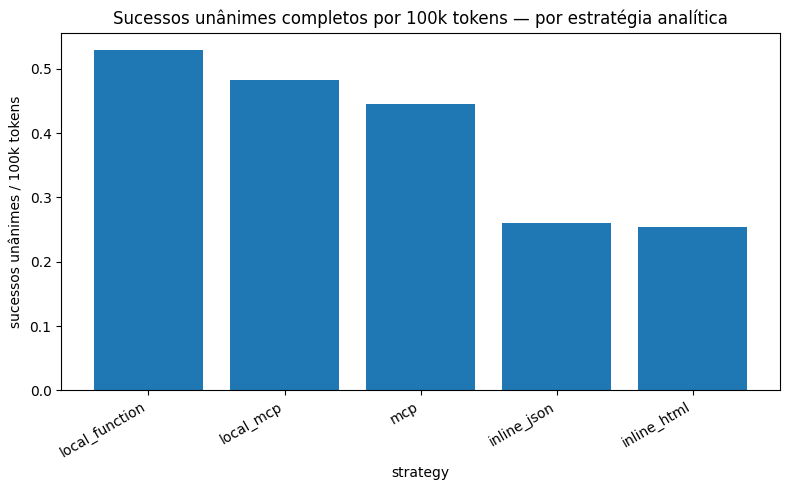

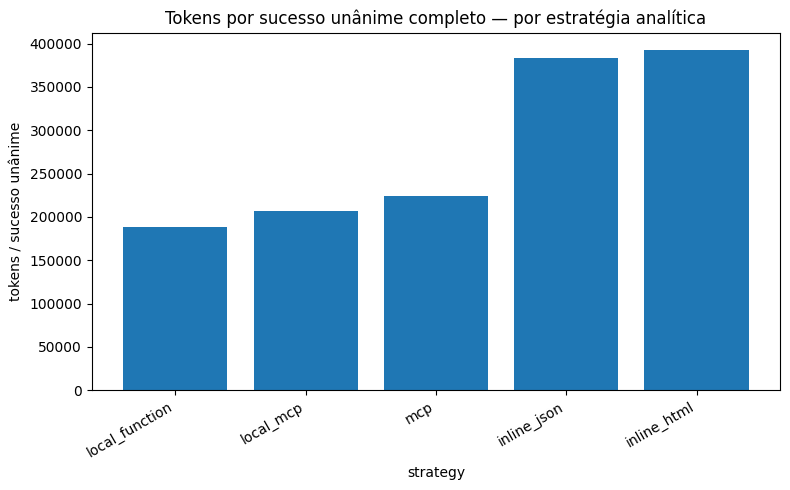

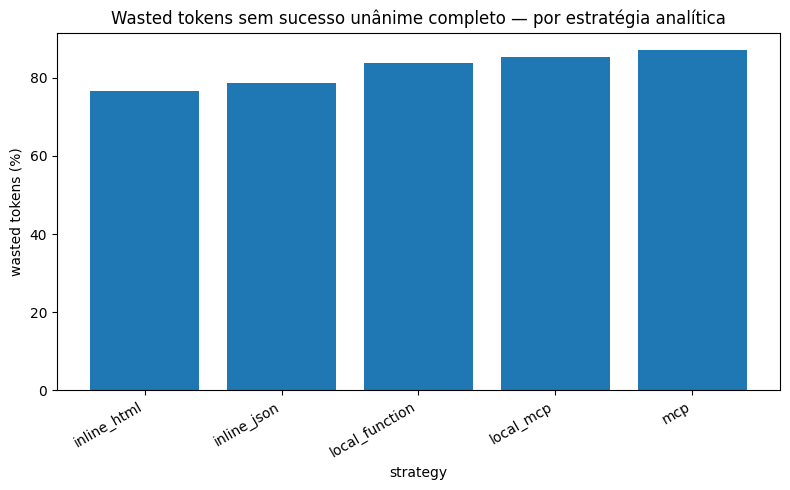

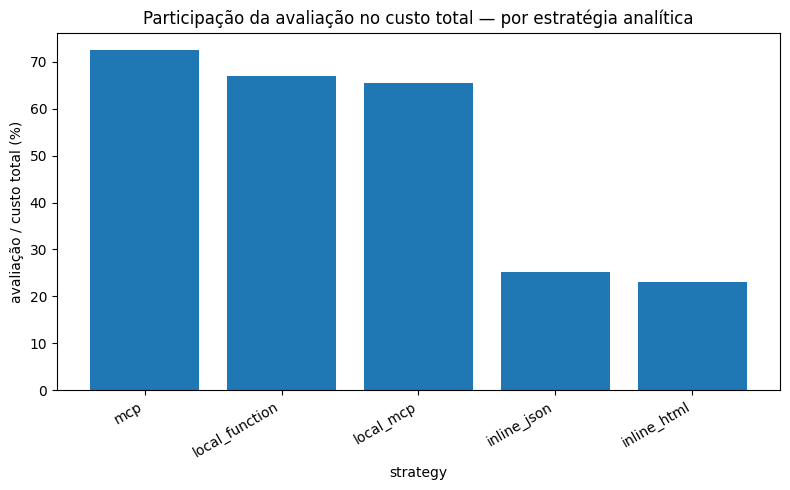

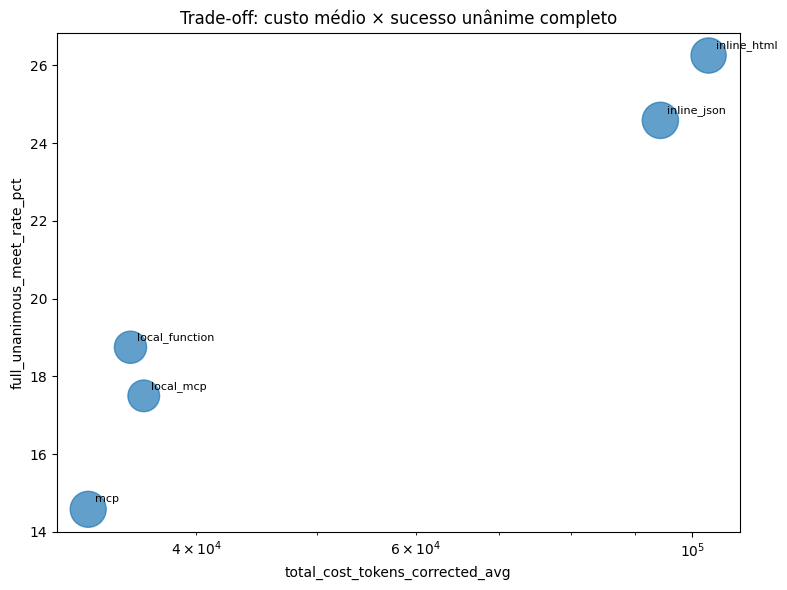

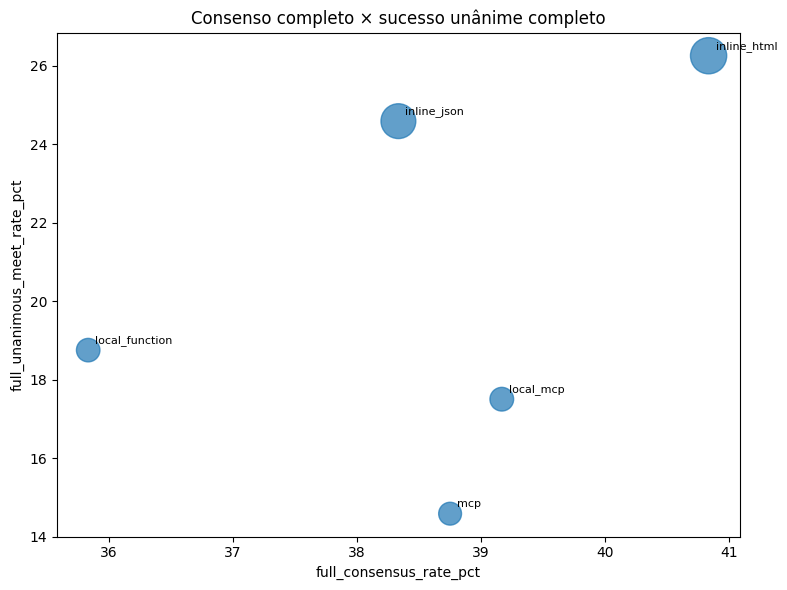

In [15]:
plot_bar(
    summary_by_strategy,
    x="strategy",
    y="full_unanimous_meets_per_100k_tokens",
    title="Sucessos unânimes completos por 100k tokens — por estratégia analítica",
    ylabel="sucessos unânimes / 100k tokens",
    sort_by="full_unanimous_meets_per_100k_tokens",
    ascending=False,
    save_name="fig_unanimous_success_per_100k_by_strategy"
)

plot_bar(
    summary_by_strategy,
    x="strategy",
    y="tokens_per_full_unanimous_meet",
    title="Tokens por sucesso unânime completo — por estratégia analítica",
    ylabel="tokens / sucesso unânime",
    sort_by="tokens_per_full_unanimous_meet",
    ascending=True,
    save_name="fig_tokens_per_unanimous_success_by_strategy"
)

plot_bar(
    summary_by_strategy,
    x="strategy",
    y="wasted_tokens_no_full_meet_pct",
    title="Wasted tokens sem sucesso unânime completo — por estratégia analítica",
    ylabel="wasted tokens (%)",
    sort_by="wasted_tokens_no_full_meet_pct",
    ascending=True,
    save_name="fig_wasted_tokens_pct_by_strategy"
)

plot_bar(
    summary_by_strategy,
    x="strategy",
    y="eval_share_of_total_cost_pct",
    title="Participação da avaliação no custo total — por estratégia analítica",
    ylabel="avaliação / custo total (%)",
    sort_by="eval_share_of_total_cost_pct",
    ascending=False,
    save_name="fig_eval_share_cost_by_strategy"
)

scatter_with_labels(
    summary_by_strategy,
    x="total_cost_tokens_corrected_avg",
    y="full_unanimous_meet_rate_pct",
    label="strategy",
    title="Trade-off: custo médio × sucesso unânime completo",
    size="answer_duration_ms_avg",
    logx=True,
    save_name="fig_tradeoff_cost_unanimous_success_by_strategy"
)

scatter_with_labels(
    summary_by_strategy,
    x="full_consensus_rate_pct",
    y="full_unanimous_meet_rate_pct",
    label="strategy",
    title="Consenso completo × sucesso unânime completo",
    size="total_cost_tokens_corrected_sum",
    logx=False,
    save_name="fig_consensus_vs_unanimous_success_by_strategy"
)


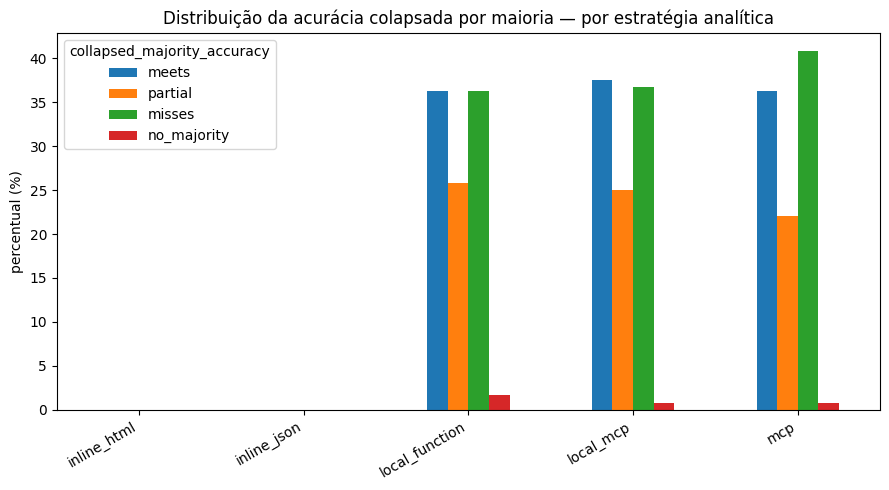

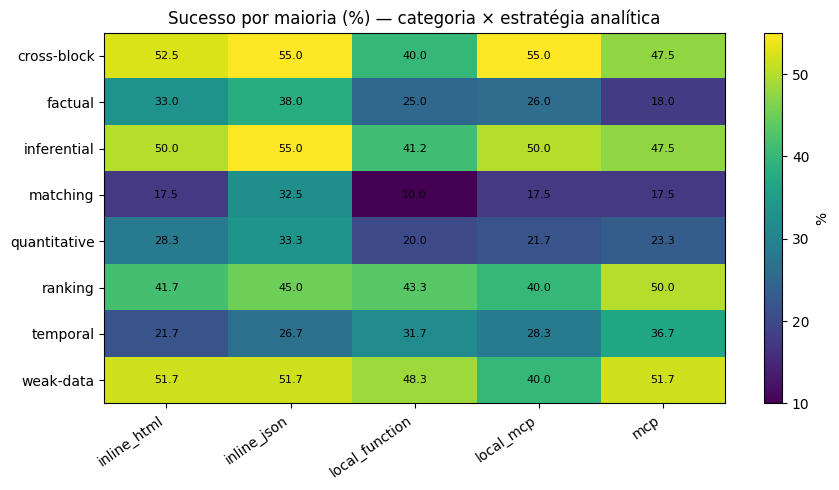

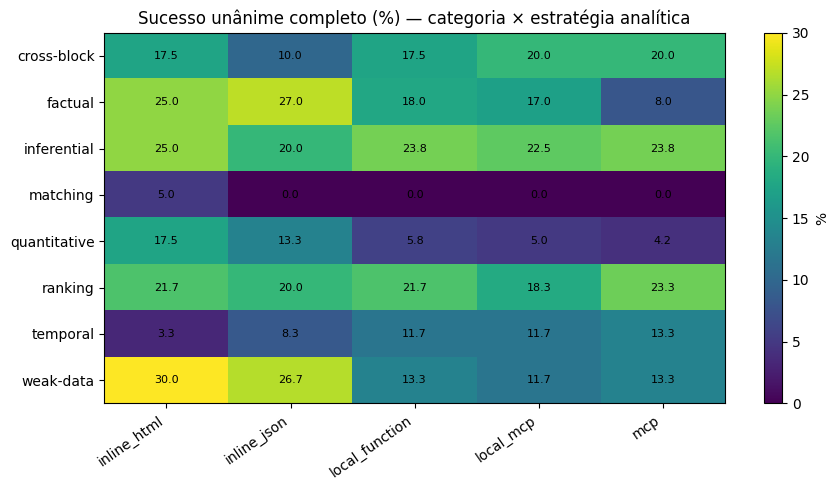

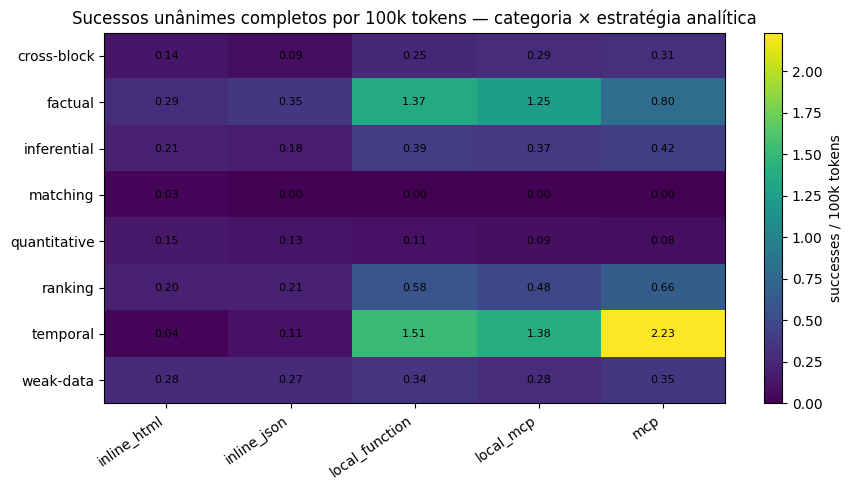

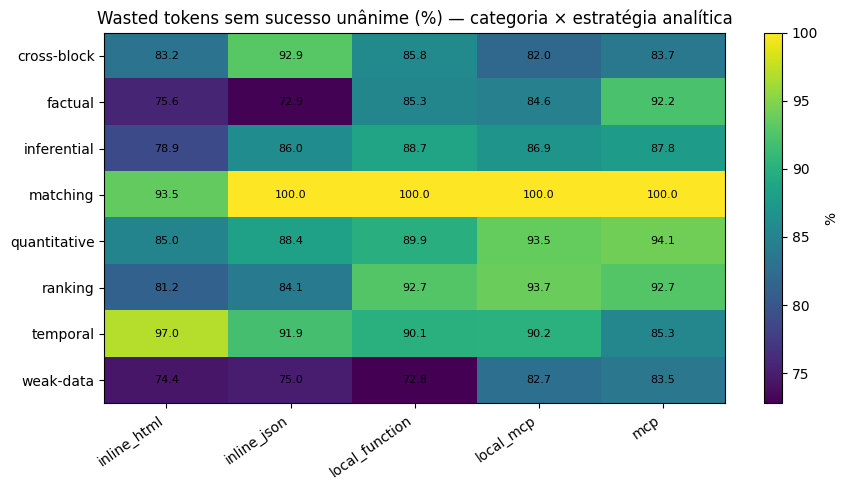

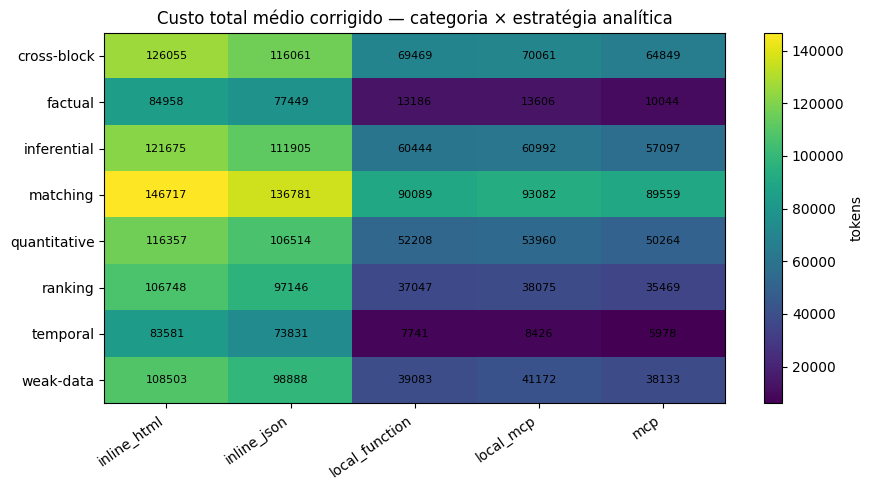

In [16]:
collapsed_strategy = runs.groupby(["strategy", "collapsed_majority_accuracy"]).size().rename("count").reset_index()
collapsed_strategy["pct"] = collapsed_strategy.groupby("strategy")["count"].transform(lambda s: s / s.sum() * 100)
collapsed_pivot = collapsed_strategy.pivot(index="strategy", columns="collapsed_majority_accuracy", values="pct").fillna(0).reindex(strategy_order)
for col in ["meets", "partial", "misses", "no_majority"]:
    if col not in collapsed_pivot:
        collapsed_pivot[col] = 0
collapsed_pivot = collapsed_pivot[["meets", "partial", "misses", "no_majority"]]
plot_grouped_bar(
    collapsed_pivot,
    title="Distribuição da acurácia colapsada por maioria — por estratégia analítica",
    ylabel="percentual (%)",
    figsize=(9, 5),
    save_name="fig_collapsed_majority_accuracy_by_strategy"
)

plot_heatmap(success_pivot, "Sucesso por maioria (%) — categoria × estratégia analítica", fmt="{:.1f}", cbar_label="%", save_name="fig_heatmap_majority_success_category_strategy")
plot_heatmap(unanimous_pivot, "Sucesso unânime completo (%) — categoria × estratégia analítica", fmt="{:.1f}", cbar_label="%", save_name="fig_heatmap_unanimous_success_category_strategy")
plot_heatmap(efficiency_pivot, "Sucessos unânimes completos por 100k tokens — categoria × estratégia analítica", fmt="{:.2f}", cbar_label="successes / 100k tokens", save_name="fig_heatmap_efficiency_category_strategy")
plot_heatmap(wasted_pivot, "Wasted tokens sem sucesso unânime (%) — categoria × estratégia analítica", fmt="{:.1f}", cbar_label="%", save_name="fig_heatmap_wasted_tokens_category_strategy")
plot_heatmap(cost_pivot, "Custo total médio corrigido — categoria × estratégia analítica", fmt="{:.0f}", cbar_label="tokens", save_name="fig_heatmap_cost_category_strategy")


/tmp/ipykernel_297788/646837522.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(series, labels=labels)


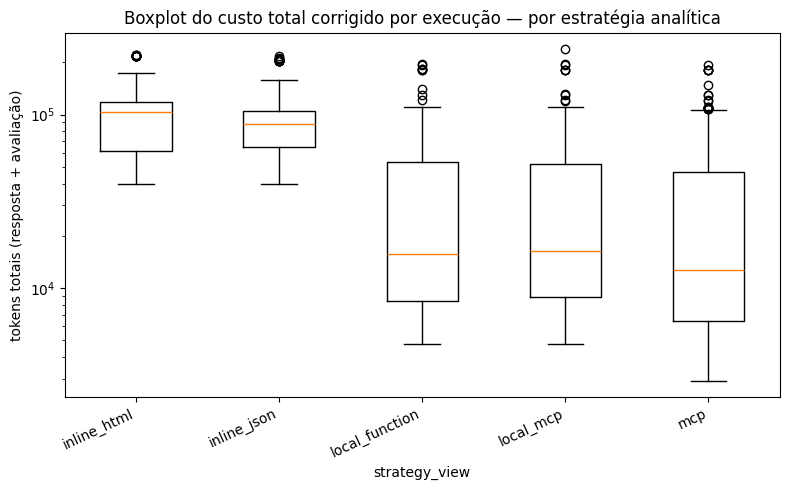

/tmp/ipykernel_297788/646837522.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(series, labels=labels)


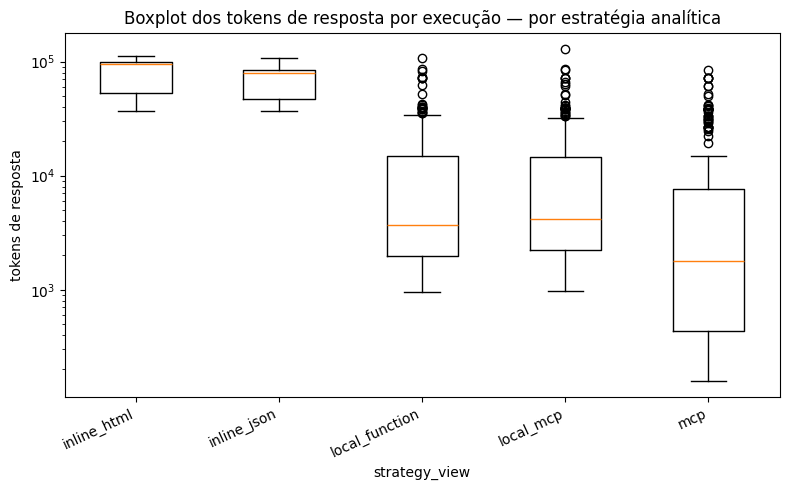

/tmp/ipykernel_297788/646837522.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(series, labels=labels)


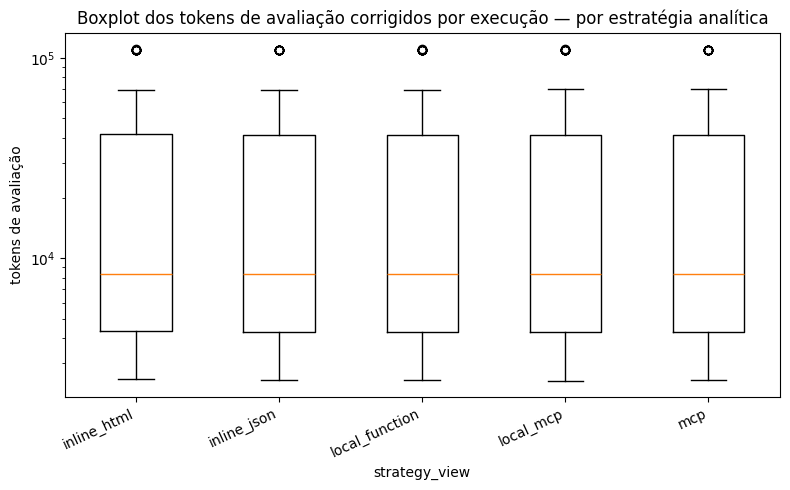

/tmp/ipykernel_297788/646837522.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(series, labels=labels)


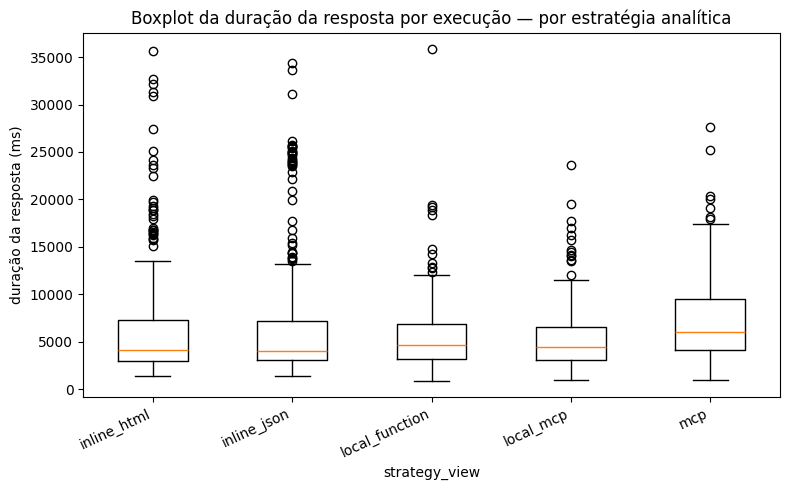

/tmp/ipykernel_297788/646837522.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(series, labels=labels)


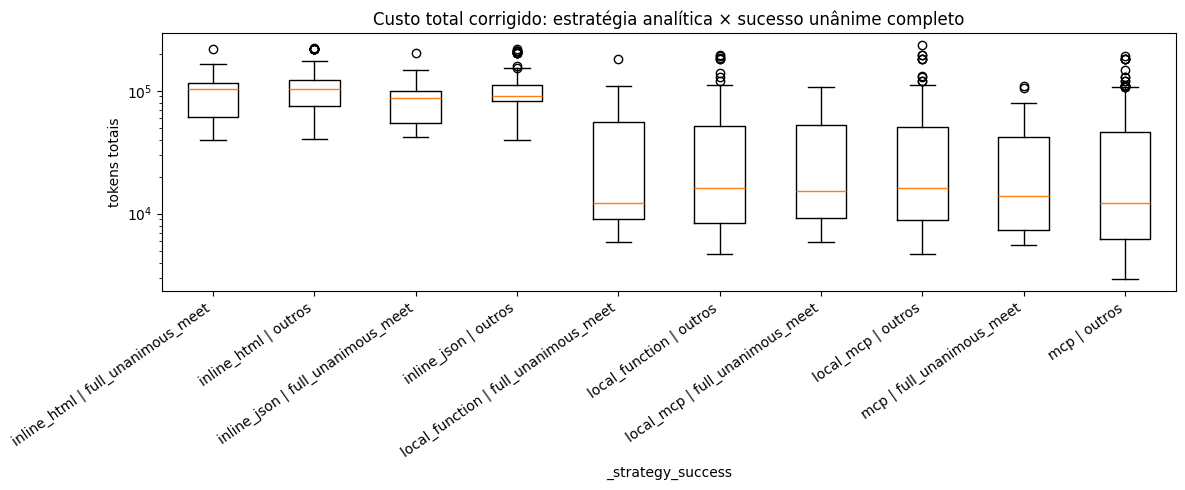

In [17]:
box_runs = runs_behavior[runs_behavior["has_eval"]].copy()

boxplot_by_group(
    box_runs,
    group_col="strategy_view",
    value_col="total_cost_tokens_corrected",
    title="Boxplot do custo total corrigido por execução — por estratégia analítica",
    ylabel="tokens totais (resposta + avaliação)",
    order=strategy_order,
    logy=True,
    save_name="fig_boxplot_total_cost_by_strategy"
)

boxplot_by_group(
    box_runs,
    group_col="strategy_view",
    value_col="answer_tokens_cost",
    title="Boxplot dos tokens de resposta por execução — por estratégia analítica",
    ylabel="tokens de resposta",
    order=strategy_order,
    logy=True,
    save_name="fig_boxplot_answer_tokens_by_strategy"
)

boxplot_by_group(
    box_runs,
    group_col="strategy_view",
    value_col="evaluation_tokens_corrected",
    title="Boxplot dos tokens de avaliação corrigidos por execução — por estratégia analítica",
    ylabel="tokens de avaliação",
    order=strategy_order,
    logy=True,
    save_name="fig_boxplot_eval_tokens_by_strategy"
)

boxplot_by_group(
    box_runs,
    group_col="strategy_view",
    value_col="answer_duration_ms",
    title="Boxplot da duração da resposta por execução — por estratégia analítica",
    ylabel="duração da resposta (ms)",
    order=strategy_order,
    save_name="fig_boxplot_answer_duration_by_strategy"
)

box_runs["_success_group"] = np.where(box_runs["full_unanimous_meet"], "full_unanimous_meet", "outros")
box_runs["_strategy_success"] = box_runs["strategy_view"] + " | " + box_runs["_success_group"]
success_order = [f"{s} | {g}" for s in strategy_order for g in ["full_unanimous_meet", "outros"] if f"{s} | {g}" in set(box_runs["_strategy_success"])]
boxplot_by_group(
    box_runs,
    group_col="_strategy_success",
    value_col="total_cost_tokens_corrected",
    title="Custo total corrigido: estratégia analítica × sucesso unânime completo",
    ylabel="tokens totais",
    order=success_order,
    logy=True,
    figsize=(12, 5),
    rotation=35,
    save_name="fig_boxplot_cost_strategy_by_unanimous_success"
)


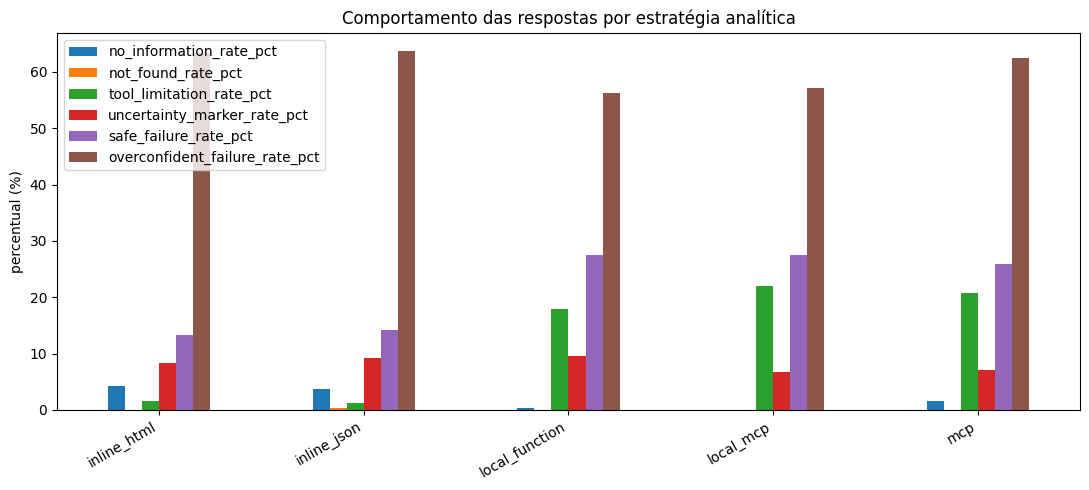

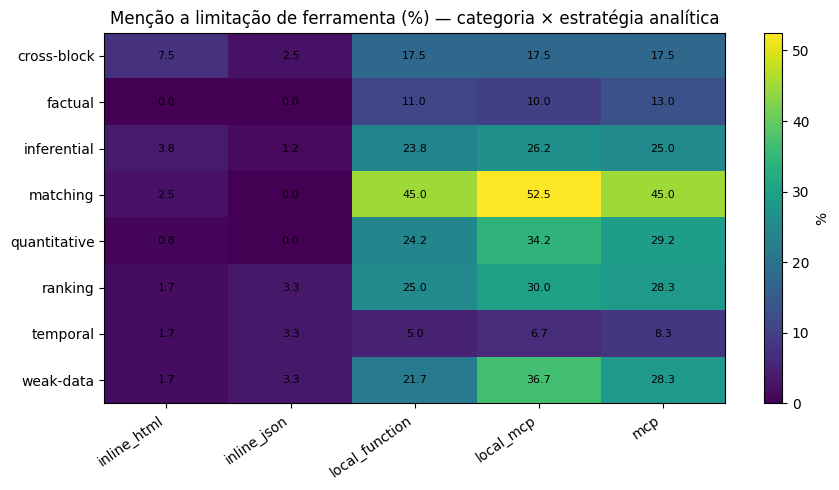

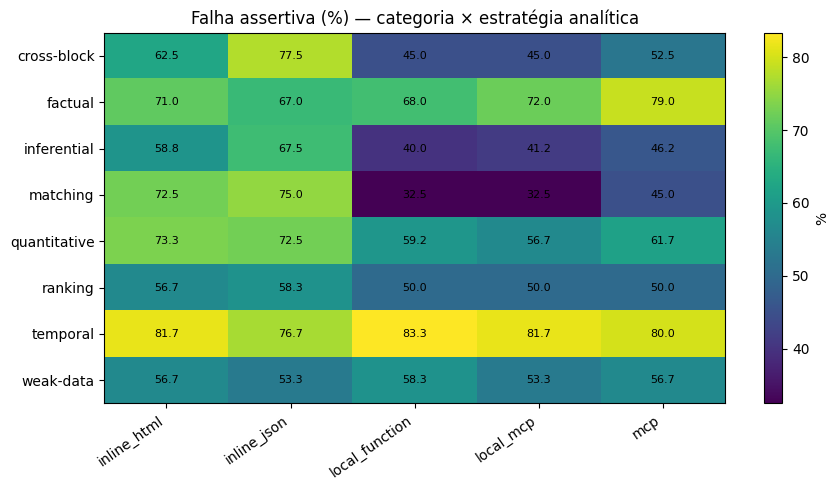

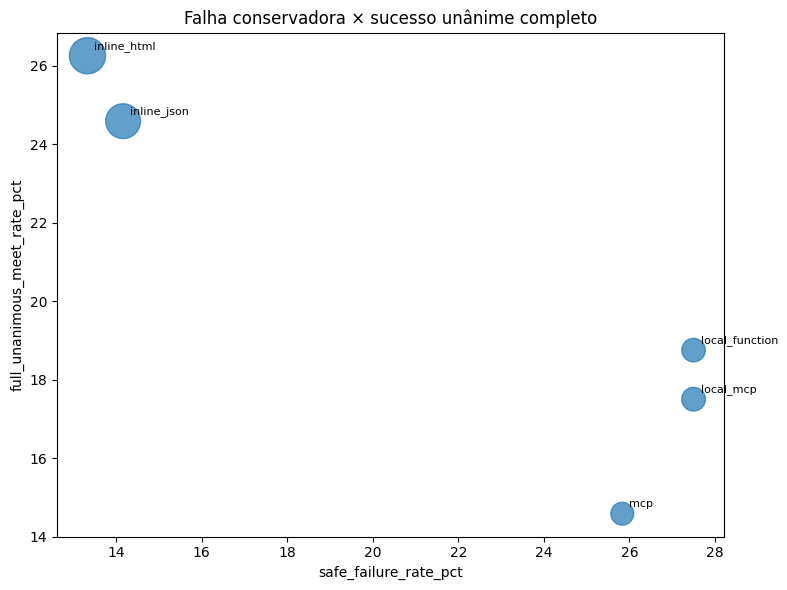

In [18]:
behavior_cols_for_plot = [
    "no_information_rate_pct",
    "not_found_rate_pct",
    "tool_limitation_rate_pct",
    "uncertainty_marker_rate_pct",
    "safe_failure_rate_pct",
    "overconfident_failure_rate_pct",
]
behavior_plot = behavior_by_strategy.set_index("strategy")[behavior_cols_for_plot].reindex(strategy_order)
plot_grouped_bar(
    behavior_plot,
    title="Comportamento das respostas por estratégia analítica",
    ylabel="percentual (%)",
    figsize=(11, 5),
    save_name="fig_answer_behavior_by_strategy"
)

behavior_cat_tool = behavior_by_category_strategy.pivot(index="category", columns="strategy", values="tool_limitation_rate_pct").reindex(columns=strategy_order)
plot_heatmap(
    behavior_cat_tool,
    title="Menção a limitação de ferramenta (%) — categoria × estratégia analítica",
    fmt="{:.1f}",
    cbar_label="%",
    save_name="fig_heatmap_tool_limitation_category_strategy"
)

behavior_cat_overconf = behavior_by_category_strategy.pivot(index="category", columns="strategy", values="overconfident_failure_rate_pct").reindex(columns=strategy_order)
plot_heatmap(
    behavior_cat_overconf,
    title="Falha assertiva (%) — categoria × estratégia analítica",
    fmt="{:.1f}",
    cbar_label="%",
    save_name="fig_heatmap_overconfident_failure_category_strategy"
)

scatter_with_labels(
    behavior_by_strategy,
    x="safe_failure_rate_pct",
    y="full_unanimous_meet_rate_pct",
    label="strategy",
    title="Falha conservadora × sucesso unânime completo",
    size="total_cost_tokens_corrected_avg",
    save_name="fig_safe_failure_vs_unanimous_success"
)


## 12. Exportação de CSVs, PNGs e SVGs

In [19]:
exports = {
    "answers_flat.csv": answers,
    "evals_flat.csv": evals,
    "votes_flat.csv": votes,
    "vote_agg_by_run_criterion.csv": vote_agg,
    "runs_flat_corrected.csv": runs,
    "runs_tags_flat_corrected.csv": runs_tags,
    "runs_behavior.csv": runs_behavior,
    "runs_behavior_tags.csv": runs_behavior_tags,

    "summary_overall.csv": summary_overall,
    "summary_by_original_strategy.csv": summary_by_original_strategy,
    "summary_by_strategy.csv": summary_by_strategy,
    "summary_by_model.csv": summary_by_model,
    "summary_by_model_strategy.csv": summary_by_model_strategy,
    "summary_by_question.csv": summary_by_question,
    "summary_by_question_strategy.csv": summary_by_question_strategy,
    "summary_by_category.csv": summary_by_category,
    "summary_by_category_strategy.csv": summary_by_category_strategy,
    "summary_by_model_category.csv": summary_by_model_category,
    "summary_by_format_strategy.csv": summary_by_format_strategy,

    "judge_cost.csv": judge_cost,
    "reported_vs_corrected_eval_cost.csv": reported_vs_corrected_eval_cost,
    "judge_distribution.csv": judge_pivot,
    "vote_pattern_counts.csv": vote_pattern_counts,
    "agreement_check.csv": agreement_check,
    "agreement_summary.csv": agreement_summary,

    "behavior_by_original_strategy.csv": behavior_by_original_strategy,
    "behavior_by_strategy.csv": behavior_by_strategy,
    "behavior_by_model.csv": behavior_by_model,
    "behavior_by_question.csv": behavior_by_question,
    "behavior_by_category.csv": behavior_by_category,
    "behavior_by_category_strategy.csv": behavior_by_category_strategy,

    "answers_trace_features.csv": answers_trace,
    "instrumentation_gap.csv": instrumentation_gap,
    "evals_trace_features.csv": evals_trace,
    "eval_trace_summary.csv": eval_trace_summary,

    "article_strategy_table.csv": article_strategy_table,
    "article_model_strategy_table.csv": article_model_strategy_table,
    "article_category_strategy_table.csv": article_category_strategy_table,
    "pivot_majority_success_category_strategy.csv": success_pivot.reset_index(),B
    "pivot_unanimous_success_category_strategy.csv": unanimous_pivot.reset_index(),
    "pivot_efficiency_category_strategy.csv": efficiency_pivot.reset_index(),
    "pivot_wasted_tokens_category_strategy.csv": wasted_pivot.reset_index(),
    "pivot_cost_category_strategy.csv": cost_pivot.reset_index(),
}

for filename, df in exports.items():
    df.to_csv(OUTPUT_DIR / filename, index=False)

zip_path = Path("baseline_analysis_notebook_outputs.zip")
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for path in sorted(OUTPUT_DIR.glob("*.csv")):
        zf.write(path, arcname=path.relative_to(OUTPUT_DIR))
    for path in sorted(FIG_DIR.glob("*")):
        zf.write(path, arcname=path.relative_to(OUTPUT_DIR))

print("CSV/figuras em:", OUTPUT_DIR.resolve())
print("ZIP gerado em:", zip_path.resolve())
print("Figuras geradas:", len(list(FIG_DIR.glob('*'))))


SyntaxError: ':' expected after dictionary key (1172591379.py, line 45)

## Artigo SBES 2026

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ============================================================
# Configuração geral
# ============================================================

STRATEGY_ORDER = [
    s for s in ["inline_html", "inline_json", "local_function", "local_mcp", "mcp"]
    if s in set(runs["strategy_view"].dropna())
]

# Usar APENAS tokens da fase de consulta/resposta.
QUERY_TOKEN_COL = "totalTokens_answer"
QUERY_DURATION_COL = "totalDurationMs_answer"

# Garantir tipos numéricos.
runs[QUERY_TOKEN_COL] = pd.to_numeric(runs[QUERY_TOKEN_COL], errors="coerce")
runs[QUERY_DURATION_COL] = pd.to_numeric(runs[QUERY_DURATION_COL], errors="coerce")

if "category" in runs_tags.columns:
    runs_tags[QUERY_TOKEN_COL] = pd.to_numeric(runs_tags[QUERY_TOKEN_COL], errors="coerce")
    runs_tags[QUERY_DURATION_COL] = pd.to_numeric(runs_tags[QUERY_DURATION_COL], errors="coerce")


def summarize_query_effectiveness(df, group_cols):
    """
    Resume custo, qualidade e eficiência usando apenas tokens de consulta/resposta.

    Métricas principais:
    - strict_majority_success_rate_pct:
        correctness=meets e completeness=meets pela maioria dos juízes.
    - full_unanimous_meet_rate_pct:
        todos os juízes deram meets em correctness e completeness.
    - full_unanimous_meets_per_100k_query_tokens:
        sucessos unânimes completos por 100k tokens de consulta.
    - query_tokens_per_full_unanimous_meet:
        tokens de consulta gastos por sucesso unânime completo.
    - wasted_query_tokens_no_full_meet_pct:
        percentual de tokens de consulta gastos em execuções sem sucesso unânime completo.
    """
    rows = []

    for keys, g in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = dict(zip(group_cols, keys))
        evaluated = g[g["has_eval"]].copy() if "has_eval" in g.columns else g.copy()

        runs_count = len(g)
        evaluated_count = len(evaluated)

        query_tokens_sum = evaluated[QUERY_TOKEN_COL].sum(min_count=1)
        full_unanimous_count = int(evaluated["full_unanimous_meet"].fillna(False).sum())
        strict_majority_count = int(evaluated["strict_majority_meet"].fillna(False).sum())

        wasted_tokens = evaluated.loc[
            ~evaluated["full_unanimous_meet"].fillna(False),
            QUERY_TOKEN_COL,
        ].sum(min_count=1)

        row.update({
            "runs": runs_count,
            "evaluated": evaluated_count,

            "query_tokens_sum": query_tokens_sum,
            "query_tokens_mean": evaluated[QUERY_TOKEN_COL].mean(),
            "query_tokens_median": evaluated[QUERY_TOKEN_COL].median(),
            "query_tokens_p95": evaluated[QUERY_TOKEN_COL].quantile(0.95),

            "query_duration_ms_mean": evaluated[QUERY_DURATION_COL].mean(),
            "query_duration_ms_median": evaluated[QUERY_DURATION_COL].median(),

            "strict_majority_success_count": strict_majority_count,
            "strict_majority_success_rate_pct": (
                strict_majority_count / evaluated_count * 100
                if evaluated_count else np.nan
            ),

            "full_unanimous_meet_count": full_unanimous_count,
            "full_unanimous_meet_rate_pct": (
                full_unanimous_count / evaluated_count * 100
                if evaluated_count else np.nan
            ),

            "query_tokens_per_full_unanimous_meet": (
                query_tokens_sum / full_unanimous_count
                if full_unanimous_count else np.nan
            ),

            "full_unanimous_meets_per_100k_query_tokens": (
                full_unanimous_count / query_tokens_sum * 100_000
                if query_tokens_sum else np.nan
            ),

            "wasted_query_tokens_no_full_meet": wasted_tokens,
            "wasted_query_tokens_no_full_meet_pct": (
                wasted_tokens / query_tokens_sum * 100
                if query_tokens_sum else np.nan
            ),
        })

        rows.append(row)

    return pd.DataFrame(rows)


summary_strategy_query = summarize_query_effectiveness(
    runs,
    ["strategy_view"],
).sort_values(
    "strategy_view",
    key=lambda s: s.map({v: i for i, v in enumerate(STRATEGY_ORDER)}).fillna(999),
)

summary_model_strategy_query = summarize_query_effectiveness(
    runs,
    ["modelId", "strategy_view"],
)

summary_category_strategy_query = summarize_query_effectiveness(
    runs_tags,
    ["category", "strategy_view"],
)

summary_question_strategy_query = summarize_query_effectiveness(
    runs,
    ["questionId", "strategy_view"],
)

## Visão Por estratégia

In [21]:
table_1_strategy_overall = summary_strategy_query[
    [
        "strategy_view",
        "evaluated",
        "query_tokens_mean",
        "query_tokens_median",
        "query_duration_ms_mean",
        "strict_majority_success_rate_pct",
        "full_unanimous_meet_rate_pct",
        "query_tokens_per_full_unanimous_meet",
        "full_unanimous_meets_per_100k_query_tokens",
        "wasted_query_tokens_no_full_meet_pct",
    ]
].copy()

table_1_strategy_overall = table_1_strategy_overall.rename(columns={
    "strategy_view": "Strategy",
    "evaluated": "Runs",
    "query_tokens_mean": "Avg query tokens",
    "query_tokens_median": "Median query tokens",
    "query_duration_ms_mean": "Avg query duration (ms)",
    "strict_majority_success_rate_pct": "Majority success (%)",
    "full_unanimous_meet_rate_pct": "Unanimous success (%)",
    "query_tokens_per_full_unanimous_meet": "Query tokens / unanimous success",
    "full_unanimous_meets_per_100k_query_tokens": "Unanimous successes / 100k query tokens",
    "wasted_query_tokens_no_full_meet_pct": "Wasted query tokens (%)",
})

display(table_1_strategy_overall.round(2))

,Strategy,Runs,Avg query tokens,Median query tokens,Avg query duration (ms),Majority success (%),Unanimous success (%),Query tokens / unanimous success,Unanimous successes / 100k query tokens,Wasted query tokens (%)
0,inline_html,240,79282.36,96107.5,6710.69,43.33,26.25,302028.05,0.33,75.15
1,inline_json,240,70557.73,78979.5,7179.60,47.08,24.58,287014.51,0.35,76.81
2,local_function,240,11728.32,3664.0,5467.79,36.25,18.75,62551.02,1.60,82.25
3,local_mcp,240,12550.37,4177.5,5250.44,37.50,17.50,71716.38,1.39,83.31
4,mcp,240,9003.57,1791.0,7062.79,36.25,14.58,61738.77,1.62,83.04


## Melhores estratégias por categoria

In [22]:
best_quality_by_category = (
    summary_category_strategy_query
    .sort_values(
        ["category", "full_unanimous_meet_rate_pct", "strict_majority_success_rate_pct"],
        ascending=[True, False, False],
    )
    .groupby("category", as_index=False)
    .head(1)
    [[
        "category",
        "strategy_view",
        "full_unanimous_meet_rate_pct",
        "strict_majority_success_rate_pct",
    ]]
    .rename(columns={
        "strategy_view": "Best quality strategy",
        "full_unanimous_meet_rate_pct": "Best unanimous success (%)",
        "strict_majority_success_rate_pct": "Majority success of best quality (%)",
    })
)

best_efficiency_by_category = (
    summary_category_strategy_query
    .sort_values(
        ["category", "full_unanimous_meets_per_100k_query_tokens"],
        ascending=[True, False],
    )
    .groupby("category", as_index=False)
    .head(1)
    [[
        "category",
        "strategy_view",
        "full_unanimous_meets_per_100k_query_tokens",
    ]]
    .rename(columns={
        "strategy_view": "Best efficiency strategy",
        "full_unanimous_meets_per_100k_query_tokens": "Best unanimous successes / 100k query tokens",
    })
)

lowest_cost_by_category = (
    summary_category_strategy_query
    .sort_values(
        ["category", "query_tokens_mean"],
        ascending=[True, True],
    )
    .groupby("category", as_index=False)
    .head(1)
    [[
        "category",
        "strategy_view",
        "query_tokens_mean",
    ]]
    .rename(columns={
        "strategy_view": "Lowest cost strategy",
        "query_tokens_mean": "Lowest avg query tokens",
    })
)

table_2_best_by_category = (
    best_quality_by_category
    .merge(best_efficiency_by_category, on="category", how="outer")
    .merge(lowest_cost_by_category, on="category", how="outer")
    .rename(columns={"category": "Category"})
    .sort_values("Category")
)

display(table_2_best_by_category.round(2))

,Category,Best quality strategy,Best unanimous success (%),Majority success of best quality (%),Best efficiency strategy,Best unanimous successes / 100k query tokens,Lowest cost strategy,Lowest avg query tokens
0,cross-block,local_mcp,20.00,55.00,mcp,1.08,mcp,18471.95
1,factual,inline_json,27.00,38.00,local_function,2.39,mcp,4302.42
2,inferential,inline_html,25.00,50.00,mcp,1.58,mcp,15040.19
3,matching,inline_html,5.00,17.50,inline_html,0.06,mcp,23078.02
4,quantitative,inline_html,17.50,28.33,local_function,0.38,mcp,13486.46
5,ranking,mcp,23.33,50.00,mcp,2.80,mcp,8347.18
6,temporal,mcp,13.33,36.67,mcp,7.71,mcp,1729.87
7,weak-data,inline_html,30.00,51.67,mcp,1.52,mcp,8790.00


## custo × sucesso por modelo-estratégia

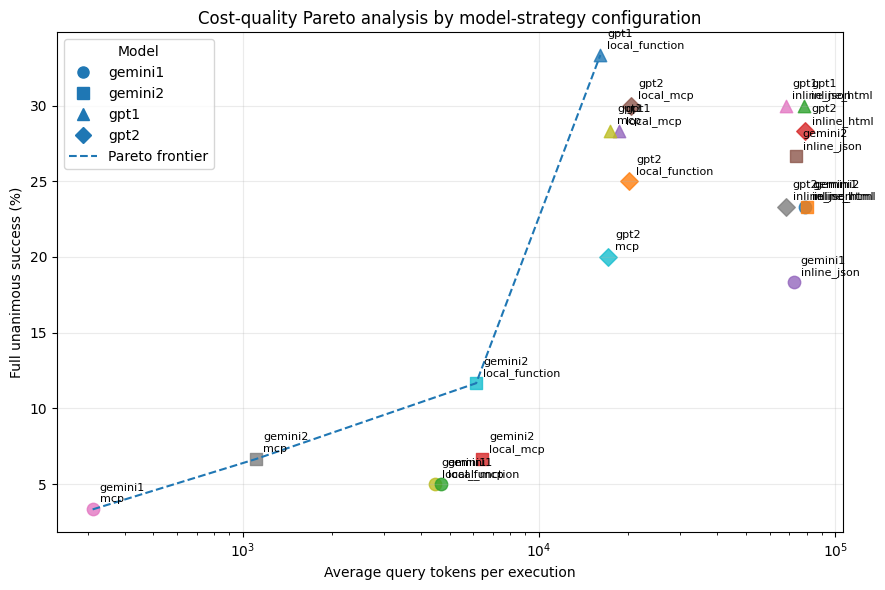

In [23]:
pareto_df = summary_model_strategy_query.dropna(
    subset=[
        "query_tokens_mean",
        "full_unanimous_meet_rate_pct",
    ]
).copy()

# Identificar pontos da fronteira de Pareto:
# menor custo e maior sucesso são melhores.
def pareto_frontier(df, cost_col, quality_col):
    data = df.sort_values(cost_col, ascending=True).copy()
    best_quality_so_far = -np.inf
    frontier_indexes = []

    for idx, row in data.iterrows():
        quality = row[quality_col]
        if quality > best_quality_so_far:
            frontier_indexes.append(idx)
            best_quality_so_far = quality

    return data.loc[frontier_indexes].sort_values(cost_col)

frontier = pareto_frontier(
    pareto_df,
    cost_col="query_tokens_mean",
    quality_col="full_unanimous_meet_rate_pct",
)

fig, ax = plt.subplots(figsize=(9, 6))

markers = ["o", "s", "^", "D", "P", "X"]
model_order = sorted(pareto_df["modelId"].dropna().unique())
marker_by_model = {
    model: markers[i % len(markers)]
    for i, model in enumerate(model_order)
}

for strategy in STRATEGY_ORDER:
    part = pareto_df[pareto_df["strategy_view"].eq(strategy)]
    if part.empty:
        continue

    for model in model_order:
        point = part[part["modelId"].eq(model)]
        if point.empty:
            continue

        ax.scatter(
            point["query_tokens_mean"],
            point["full_unanimous_meet_rate_pct"],
            marker=marker_by_model[model],
            s=80,
            alpha=0.8,
            label=f"{strategy} / {model}",
        )

# Linha de Pareto
if not frontier.empty:
    ax.plot(
        frontier["query_tokens_mean"],
        frontier["full_unanimous_meet_rate_pct"],
        linestyle="--",
        linewidth=1.5,
        label="Pareto frontier",
    )

# Rótulos curtos nos pontos
for _, row in pareto_df.iterrows():
    label = f"{row['modelId']}\n{row['strategy_view']}"
    ax.annotate(
        label,
        (row["query_tokens_mean"], row["full_unanimous_meet_rate_pct"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_xscale("log")
ax.set_xlabel("Average query tokens per execution")
ax.set_ylabel("Full unanimous success (%)")
ax.set_title("Cost-quality Pareto analysis by model-strategy configuration")
ax.grid(True, axis="both", alpha=0.25)

# Evitar legenda enorme; use somente legenda dos markers/modelos.
handles = [
    plt.Line2D(
        [0], [0],
        marker=marker_by_model[m],
        linestyle="",
        label=m,
        markersize=8,
    )
    for m in model_order
]
handles.append(
    plt.Line2D([0], [0], linestyle="--", label="Pareto frontier")
)
ax.legend(handles=handles, title="Model", loc="best")

plt.tight_layout()
plt.show()

## custo por estratégia separado por sucesso

/tmp/ipykernel_297788/1856409598.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(series, labels=labels, vert=True, showfliers=True)


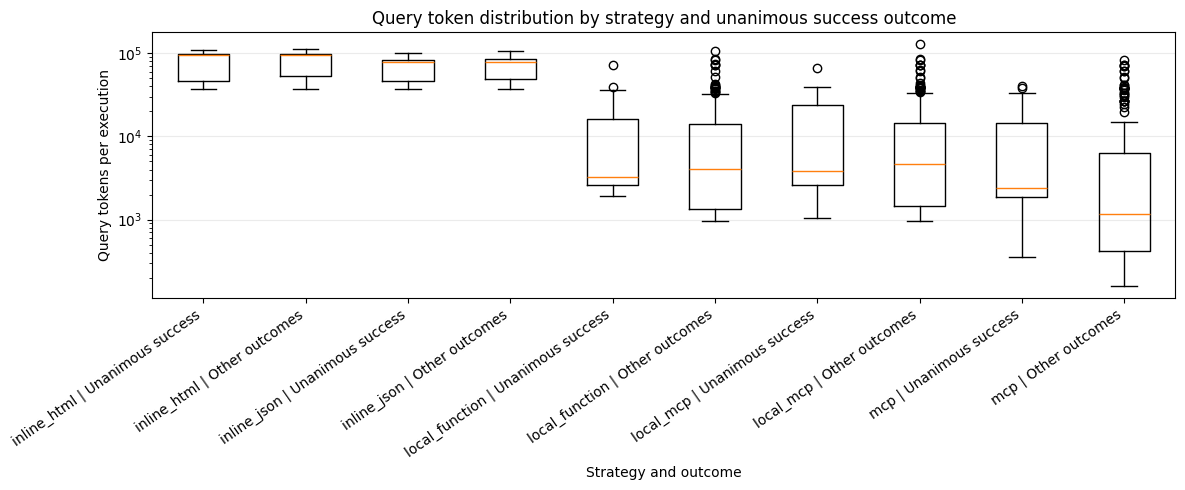

In [24]:
box_df = runs[runs["has_eval"]].copy()
box_df["success_group"] = np.where(
    box_df["full_unanimous_meet"],
    "Unanimous success",
    "Other outcomes",
)

box_df["_box_group"] = box_df["strategy_view"] + " | " + box_df["success_group"]

box_order = []
for strategy in STRATEGY_ORDER:
    for outcome in ["Unanimous success", "Other outcomes"]:
        label = f"{strategy} | {outcome}"
        if label in set(box_df["_box_group"]):
            box_order.append(label)

series = []
labels = []

for label in box_order:
    values = (
        box_df.loc[box_df["_box_group"].eq(label), QUERY_TOKEN_COL]
        .dropna()
        .astype(float)
    )
    if len(values):
        series.append(values.values)
        labels.append(label)

fig, ax = plt.subplots(figsize=(12, 5))

ax.boxplot(series, labels=labels, vert=True, showfliers=True)

ax.set_yscale("log")
ax.set_ylabel("Query tokens per execution")
ax.set_xlabel("Strategy and outcome")
ax.set_title("Query token distribution by strategy and unanimous success outcome")
plt.xticks(rotation=35, ha="right")
ax.grid(True, axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## qualidade absoluta vs eficiência

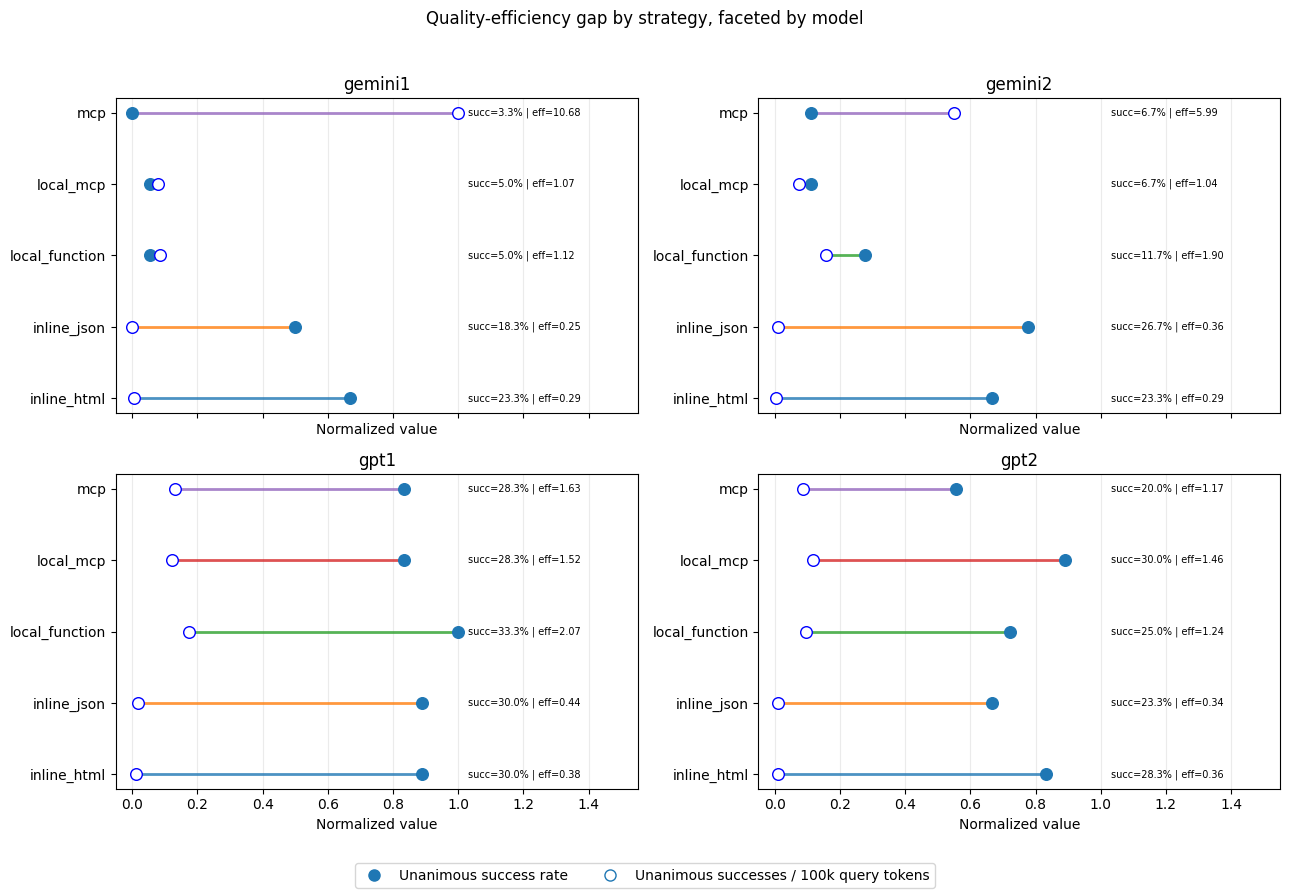

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Dumbbell chart facetado: 1 gráfico por modelo
# ============================================================

# Base esperada:
# summary_model_strategy_query com colunas:
# - modelId
# - strategy_view
# - full_unanimous_meet_rate_pct
# - full_unanimous_meets_per_100k_query_tokens

facet_df = summary_model_strategy_query[
    [
        "modelId",
        "strategy_view",
        "full_unanimous_meet_rate_pct",
        "full_unanimous_meets_per_100k_query_tokens",
    ]
].copy()

facet_df = facet_df.dropna(
    subset=[
        "full_unanimous_meet_rate_pct",
        "full_unanimous_meets_per_100k_query_tokens",
    ]
)

STRATEGY_ORDER = [
    s for s in ["inline_html", "inline_json", "local_function", "local_mcp", "mcp"]
    if s in set(facet_df["strategy_view"].dropna())
]

MODEL_ORDER = sorted(facet_df["modelId"].dropna().unique())

# ------------------------------------------------------------
# Normalização global
# ------------------------------------------------------------
def minmax(series):
    series = pd.to_numeric(series, errors="coerce")
    min_v = series.min()
    max_v = series.max()
    if pd.isna(min_v) or pd.isna(max_v) or max_v == min_v:
        return pd.Series(np.ones(len(series)) * 0.5, index=series.index)
    return (series - min_v) / (max_v - min_v)

facet_df["quality_norm"] = minmax(facet_df["full_unanimous_meet_rate_pct"])
facet_df["efficiency_norm"] = minmax(
    facet_df["full_unanimous_meets_per_100k_query_tokens"]
)

# ------------------------------------------------------------
# Função para desenhar um subgráfico
# ------------------------------------------------------------
def plot_dumbbell_for_model(ax, model_df, model_name, strategy_order):
    if model_df.empty:
        ax.set_title(model_name)
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return

    model_df = model_df.copy()
    model_df["strategy_view"] = pd.Categorical(
        model_df["strategy_view"],
        categories=strategy_order,
        ordered=True,
    )
    model_df = model_df.sort_values("strategy_view").reset_index(drop=True)

    y_positions = np.arange(len(model_df))

    # Linhas do dumbbell
    for y, row in zip(y_positions, model_df.itertuples()):
        ax.plot(
            [row.quality_norm, row.efficiency_norm],
            [y, y],
            linewidth=2,
            alpha=0.8,
        )

    # Ponto da qualidade absoluta
    ax.scatter(
        model_df["quality_norm"],
        y_positions,
        s=70,
        label="Unanimous success rate",
        zorder=3,
    )

    # Ponto da eficiência
    ax.scatter(
        model_df["efficiency_norm"],
        y_positions,
        s=70,
        marker="o",
        facecolors="white",
        edgecolors="blue",
        label="Unanimous successes / 100k query tokens",
        zorder=3,
    )

    # Rótulos com valores reais
    for y, row in zip(y_positions, model_df.itertuples()):
        ax.text(
            1.03,
            y,
            (
                f"succ={row.full_unanimous_meet_rate_pct:.1f}% | "
                f"eff={row.full_unanimous_meets_per_100k_query_tokens:.2f}"
            ),
            va="center",
            fontsize=7,
        )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(model_df["strategy_view"])
    ax.set_xlim(-0.05, 1.55)
    ax.set_xlabel("Normalized value")
    ax.set_title(str(model_name))
    ax.grid(True, axis="x", alpha=0.25)


# ------------------------------------------------------------
# Plot 2x2
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
axes = axes.flatten()

for i, model in enumerate(MODEL_ORDER):
    model_part = facet_df[facet_df["modelId"].eq(model)]
    plot_dumbbell_for_model(
        axes[i],
        model_part,
        model_name=model,
        strategy_order=STRATEGY_ORDER,
    )

# Se houver menos de 4 modelos, esconder eixos sobrando
for j in range(len(MODEL_ORDER), len(axes)):
    axes[j].set_axis_off()

# Legenda única
handles = [
    plt.Line2D([0], [0], marker="o", fillstyle="full", linestyle="", markersize=8, label="Unanimous success rate"),
    plt.Line2D([0], [0], marker="o", fillstyle="none", linestyle="", markersize=8, label="Unanimous successes / 100k query tokens"),
]
fig.legend(handles=handles, loc="lower center", ncol=2, frameon=True)

fig.suptitle("Quality-efficiency gap by strategy, faceted by model", y=0.98)
plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()

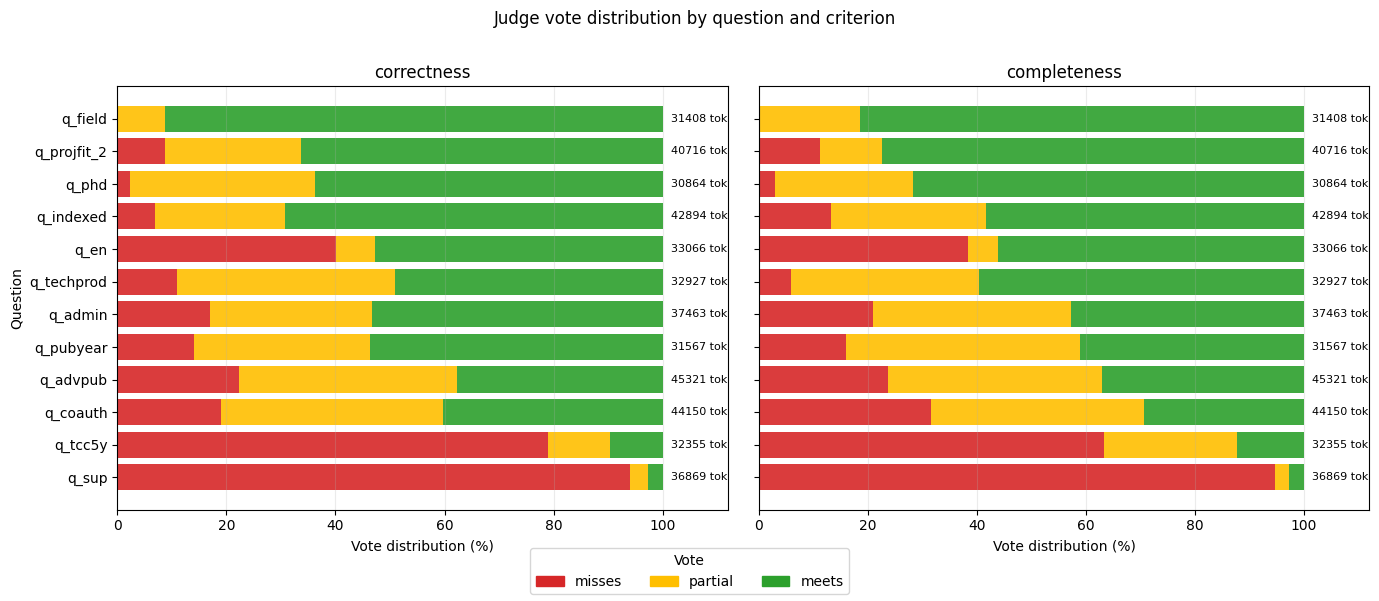

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURAÇÃO
# ============================================================

FILTER_STRATEGY_VIEW = None   # Ex.: "mcp" | "inline_html" | "local_function"
FILTER_MODEL_IDS = None       # Ex.: ["gpt1", "gpt2"]

RATING_ORDER = ["misses", "partial", "meets"]
CRITERION_ORDER = ["correctness", "completeness"]

# ============================================================
# BASE PARA OS GRÁFICOS
# ============================================================

def build_vote_plot_base(runs, votes, filter_strategy_view=None, filter_model_ids=None):
    base = (
        votes[
            [
                "runId",
                "questionId",
                "judgeId",
                "criterion",
                "rating",
            ]
        ]
        .merge(
            runs[
                [
                    "runId",
                    "questionId",
                    "modelId",
                    "strategy_view",
                    "totalTokens_answer",
                    "has_eval",
                ]
            ],
            on=["runId", "questionId"],
            how="left",
        )
        .copy()
    )

    base["totalTokens_answer"] = pd.to_numeric(base["totalTokens_answer"], errors="coerce")

    if "has_eval" in base.columns:
        base = base[base["has_eval"].fillna(False)]

    if filter_strategy_view is not None:
        base = base[base["strategy_view"].eq(filter_strategy_view)]

    if filter_model_ids is not None:
        base = base[base["modelId"].isin(filter_model_ids)]

    base = base.dropna(subset=["criterion", "rating", "questionId", "totalTokens_answer"])
    return base


vote_plot_base = build_vote_plot_base(
    runs=runs,
    votes=votes,
    filter_strategy_view=FILTER_STRATEGY_VIEW,
    filter_model_ids=FILTER_MODEL_IDS,
)

# ============================================================
# AGREGAÇÃO PARA O GRÁFICO
# ============================================================

vote_dist = (
    vote_plot_base
    .groupby(["criterion", "questionId", "rating"])
    .size()
    .rename("n_votes")
    .reset_index()
)

vote_dist_pivot = (
    vote_dist
    .pivot_table(
        index=["criterion", "questionId"],
        columns="rating",
        values="n_votes",
        fill_value=0,
    )
    .reset_index()
)

for col in RATING_ORDER:
    if col not in vote_dist_pivot.columns:
        vote_dist_pivot[col] = 0

vote_dist_pivot["total_votes"] = vote_dist_pivot[RATING_ORDER].sum(axis=1)

for col in RATING_ORDER:
    vote_dist_pivot[f"{col}_pct"] = np.where(
        vote_dist_pivot["total_votes"] > 0,
        vote_dist_pivot[col] / vote_dist_pivot["total_votes"] * 100,
        np.nan,
    )

avg_cost_by_question_criterion = (
    vote_plot_base
    .groupby(["criterion", "questionId"], as_index=False)
    .agg(avg_query_tokens=("totalTokens_answer", "mean"))
)

vote_dist_pivot = vote_dist_pivot.merge(
    avg_cost_by_question_criterion,
    on=["criterion", "questionId"],
    how="left",
)

# Ordenar perguntas: da pior para a melhor, usando meets médio nos dois critérios
question_order = (
    vote_dist_pivot
    .groupby("questionId", as_index=False)
    .agg(mean_meets_pct=("meets_pct", "mean"))
    .sort_values("mean_meets_pct", ascending=True)["questionId"]
    .tolist()
)

# ============================================================
# PLOT
# ============================================================

fig_height = max(6, len(question_order) * 0.45)
fig, axes = plt.subplots(
    1,
    len(CRITERION_ORDER),
    figsize=(14, fig_height),
    sharey=True,
    sharex=True,
)

if len(CRITERION_ORDER) == 1:
    axes = [axes]

color_map = {
    "misses": "#d62728",
    "partial": "#ffbf00",
    "meets": "#2ca02c",
}

for ax, criterion in zip(axes, CRITERION_ORDER):
    part = vote_dist_pivot[vote_dist_pivot["criterion"].eq(criterion)].copy()
    part["questionId"] = pd.Categorical(part["questionId"], categories=question_order, ordered=True)
    part = part.sort_values("questionId")

    y = np.arange(len(part))

    left = np.zeros(len(part))
    for rating in RATING_ORDER:
        values = part[f"{rating}_pct"].fillna(0).values
        ax.barh(
            y,
            values,
            left=left,
            label=rating,
            color=color_map[rating],
            alpha=0.9,
        )
        left += values

    # Anotar custo médio à direita
    for yy, row in zip(y, part.itertuples()):
        ax.text(
            101.5,
            yy,
            f"{row.avg_query_tokens:.0f} tok",
            va="center",
            fontsize=8,
        )

    ax.set_title(criterion)
    ax.set_xlabel("Vote distribution (%)")
    ax.set_xlim(0, 112)
    ax.grid(True, axis="x", alpha=0.25)

axes[0].set_ylabel("Question")
axes[0].set_yticks(np.arange(len(question_order)))
axes[0].set_yticklabels(question_order)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_map[r], label=r)
    for r in RATING_ORDER
]
fig.legend(handles=handles, title="Vote", loc="lower center", ncol=3)

title = "Judge vote distribution by question and criterion"
if FILTER_STRATEGY_VIEW:
    title += f" — strategy={FILTER_STRATEGY_VIEW}"
if FILTER_MODEL_IDS:
    title += f" — models={FILTER_MODEL_IDS}"

fig.suptitle(title, y=0.98)
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURAÇÃO
# ============================================================

MODEL_FILTER = None            # Ex.: "gpt1", "gpt2", "gemini1", "gemini2"
FILTER_STRATEGY_VIEW = None    # Ex.: "mcp", "inline_html", "local_function"

RATING_ORDER = ["misses", "partial", "meets"]
COLOR_MAP = {
    "misses": "#d62728",
    "partial": "#ffbf00",
    "meets": "#2ca02c",
}


# ============================================================
# BASE
# ============================================================

def normalize_tags(value):
    if isinstance(value, (list, tuple)):
        return [x for x in value if pd.notna(x)]
    if pd.isna(value):
        return []
    return [value]


def build_vote_plot_base(runs, votes, model_filter=None, filter_strategy_view=None):
    cols_from_runs = [
        "runId",
        "questionId",
        "modelId",
        "strategy_view",
        "totalTokens_answer",
        "has_eval",
    ]

    if "questionTags" in runs.columns:
        cols_from_runs.append("questionTags")
    elif "question_tags_catalog" in runs.columns:
        cols_from_runs.append("question_tags_catalog")

    base = (
        votes[
            [
                "runId",
                "questionId",
                "judgeId",
                "criterion",
                "rating",
            ]
        ]
        .merge(
            runs[cols_from_runs],
            on=["runId", "questionId"],
            how="left",
        )
        .copy()
    )

    base["totalTokens_answer"] = pd.to_numeric(
        base["totalTokens_answer"],
        errors="coerce",
    )

    if "has_eval" in base.columns:
        base = base[base["has_eval"].fillna(False)]

    if model_filter is not None:
        base = base[base["modelId"].eq(model_filter)]

    if filter_strategy_view is not None:
        base = base[base["strategy_view"].eq(filter_strategy_view)]

    if "questionTags" in base.columns:
        base["tags_norm"] = base["questionTags"].apply(normalize_tags)
    elif "question_tags_catalog" in base.columns:
        base["tags_norm"] = base["question_tags_catalog"].apply(normalize_tags)
    else:
        base["tags_norm"] = [[] for _ in range(len(base))]

    return base.dropna(
        subset=["criterion", "rating", "questionId", "modelId", "totalTokens_answer"]
    )


vote_plot_base = build_vote_plot_base(
    runs=runs,
    votes=votes,
    model_filter=MODEL_FILTER,
    filter_strategy_view=FILTER_STRATEGY_VIEW,
)

question_df = vote_plot_base.copy()

tag_df = (
    vote_plot_base
    .explode("tags_norm")
    .rename(columns={"tags_norm": "tag"})
)
tag_df = tag_df.dropna(subset=["tag"])
tag_df = tag_df[tag_df["tag"] != ""]


# ============================================================
# AGREGAÇÃO
# ============================================================

def build_pct_distribution(df, group_col):
    counts = (
        df.groupby(["criterion", group_col, "rating"])
        .size()
        .rename("n_votes")
        .reset_index()
    )

    pivot = (
        counts
        .pivot_table(
            index=["criterion", group_col],
            columns="rating",
            values="n_votes",
            fill_value=0,
        )
        .reset_index()
    )

    for col in RATING_ORDER:
        if col not in pivot.columns:
            pivot[col] = 0

    pivot["total_votes"] = pivot[RATING_ORDER].sum(axis=1)

    for col in RATING_ORDER:
        pivot[f"{col}_pct"] = np.where(
            pivot["total_votes"] > 0,
            pivot[col] / pivot["total_votes"] * 100,
            np.nan,
        )

    avg_cost = (
        df.groupby(["criterion", group_col], as_index=False)
        .agg(avg_query_tokens=("totalTokens_answer", "mean"))
    )

    return pivot.merge(avg_cost, on=["criterion", group_col], how="left")


question_pct = build_pct_distribution(question_df, "questionId")
tag_pct = build_pct_distribution(tag_df, "tag")


def order_by_mean_meets(df, group_col):
    return (
        df.groupby(group_col, as_index=False)
        .agg(mean_meets_pct=("meets_pct", "mean"))
        .sort_values("mean_meets_pct", ascending=True)[group_col]
        .tolist()
    )


question_order = order_by_mean_meets(question_pct, "questionId")
tag_order = order_by_mean_meets(tag_pct, "tag")


# ============================================================
# PLOT
# ============================================================

def plot_stacked_barh_panel(ax, df, criterion, group_col, order, title):
    part = df[df["criterion"].eq(criterion)].copy()
    part[group_col] = pd.Categorical(
        part[group_col],
        categories=order,
        ordered=True,
    )
    part = part.sort_values(group_col)

    y = np.arange(len(part))
    left = np.zeros(len(part))

    for rating in RATING_ORDER:
        values = part[f"{rating}_pct"].fillna(0).values
        ax.barh(
            y,
            values,
            left=left,
            color=COLOR_MAP[rating],
            alpha=0.9,
            label=rating,
        )
        left += values

    for yy, row in zip(y, part.itertuples()):
        ax.text(
            101.0,
            yy,
            f"{row.avg_query_tokens:.0f}",
            va="center",
            fontsize=8,
        )

    ax.set_yticks(y)
    ax.set_yticklabels(part[group_col], fontsize=8)
    ax.set_xlim(0, 112)
    ax.set_xlabel("Vote distribution (%)")
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.25)


fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10),
    sharex=True,
)

plot_stacked_barh_panel(
    axes[0, 0],
    question_pct,
    criterion="correctness",
    group_col="questionId",
    order=question_order,
    title="Correctness by question",
)

plot_stacked_barh_panel(
    axes[0, 1],
    question_pct,
    criterion="completeness",
    group_col="questionId",
    order=question_order,
    title="Completeness by question",
)

plot_stacked_barh_panel(
    axes[1, 0],
    tag_pct,
    criterion="correctness",
    group_col="tag",
    order=tag_order,
    title="Correctness by category",
)

plot_stacked_barh_panel(
    axes[1, 1],
    tag_pct,
    criterion="completeness",
    group_col="tag",
    order=tag_order,
    title="Completeness by category",
)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=COLOR_MAP[r], label=r)
    for r in RATING_ORDER
]

fig.legend(
    handles=handles,
    title="Vote",
    loc="lower center",
    ncol=3,
    frameon=True,
)

title = "Judge vote distribution by question/category and criterion"
if MODEL_FILTER:
    title += f" — model={MODEL_FILTER}"
if FILTER_STRATEGY_VIEW:
    title += f" — strategy={FILTER_STRATEGY_VIEW}"

fig.suptitle(
    title + "\n(numbers at right = average query tokens)",
    y=0.99,
    fontsize=14,
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURAÇÃO
# ============================================================

# Métrica de tempo: apenas resposta/consulta
TIME_COL = "totalDurationMs_answer"

# Métrica de sucesso:
# - "strict_majority_meet"  -> maioria dos juízes em correctness e completeness
# - "full_unanimous_meet"   -> todos os juízes deram meets em correctness e completeness
SUCCESS_COL = "strict_majority_meet"

# Estratégia analítica
STRATEGY_COL = "strategy_view" if "strategy_view" in runs.columns else "strategy"

# Ordens preferidas
STRATEGY_ORDER = [
    s for s in ["inline_html", "inline_json", "local_function", "local_mcp", "mcp"]
    if s in set(runs[STRATEGY_COL].dropna())
]

MODEL_ORDER = sorted(runs["modelId"].dropna().unique())

# Garantir tipos corretos
runs[TIME_COL] = pd.to_numeric(runs[TIME_COL], errors="coerce")
if "has_eval" not in runs.columns:
    runs["has_eval"] = True

if "category" in runs_tags.columns:
    runs_tags[TIME_COL] = pd.to_numeric(runs_tags[TIME_COL], errors="coerce")


# ============================================================
# HELPERS
# ============================================================

def boxplot_by_group(df, group_col, value_col, title, ylabel=None, order=None, logy=False, figsize=(9, 5), rotation=25):
    data = df.copy()
    if order is None:
        order = list(dict.fromkeys(data[group_col].dropna().tolist()))

    series = []
    labels = []
    for group in order:
        vals = pd.to_numeric(
            data.loc[data[group_col].eq(group), value_col],
            errors="coerce"
        ).dropna()
        if len(vals) > 0:
            series.append(vals.values)
            labels.append(group)

    if not series:
        print(f"Sem dados para boxplot de {value_col}")
        return

    plt.figure(figsize=figsize)
    plt.boxplot(series, labels=labels, vert=True)
    if logy:
        plt.yscale("log")
    plt.title(title)
    plt.xlabel(group_col)
    plt.ylabel(ylabel or value_col)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    plt.show()


def build_success_heatmap(df, row_col, col_col, success_col):
    agg = (
        df[df["has_eval"].fillna(False)]
        .groupby([row_col, col_col], as_index=False)
        .agg(
            runs=("runId", "nunique"),
            success_rate_pct=(success_col, lambda s: pd.Series(s).fillna(False).mean() * 100),
            avg_time_ms=(TIME_COL, "mean"),
        )
    )

    pivot = agg.pivot(index=row_col, columns=col_col, values="success_rate_pct")
    return agg, pivot


def plot_heatmap(pivot_df, title, figsize=(10, 5), fmt="{:.1f}"):
    # ordenação
    data = pivot_df.copy()

    # ordenar colunas se forem estratégias ou modelos
    if set(data.columns).issubset(set(STRATEGY_ORDER)):
        ordered_cols = [c for c in STRATEGY_ORDER if c in data.columns]
        data = data.reindex(columns=ordered_cols)
    elif set(data.columns).issubset(set(MODEL_ORDER)):
        ordered_cols = [c for c in MODEL_ORDER if c in data.columns]
        data = data.reindex(columns=ordered_cols)

    # ordenar linhas alfabeticamente
    data = data.sort_index()

    arr = data.values.astype(float)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(arr, aspect="auto")

    ax.set_title(title)
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(list(data.columns), rotation=35, ha="right")
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(list(data.index))

    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            val = arr[i, j]
            txt = "" if pd.isna(val) else fmt.format(val)
            ax.text(j, i, txt, ha="center", va="center", fontsize=9)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Success rate (%)")

    plt.tight_layout()
    plt.show()

In [ ]:
box_df_strategy = runs[runs["has_eval"].fillna(False)].copy()

boxplot_by_group(
    df=box_df_strategy,
    group_col=STRATEGY_COL,
    value_col=TIME_COL,
    title="Execution time by strategy",
    ylabel="Execution time (ms)",
    order=STRATEGY_ORDER,
    logy=False,
    figsize=(8, 5),
)

box_df_model = runs[runs["has_eval"].fillna(False)].copy()

boxplot_by_group(
    df=box_df_model,
    group_col="modelId",
    value_col=TIME_COL,
    title="Execution time by model",
    ylabel="Execution time (ms)",
    order=MODEL_ORDER,
    logy=False,
    figsize=(8, 5),
)

In [ ]:
import pandas as pd
from IPython.display import display, HTML

QUESTIONS_OF_INTEREST = ["q_en"]
STRATEGIES_OF_INTEREST = ["inline_html", "inline_json"]

STRATEGY_COL = "strategy_view" if "strategy_view" in runs.columns else "strategy"

answers_inline_sup_tcc = (
    runs[
        runs["questionId"].isin(QUESTIONS_OF_INTEREST)
        & runs[STRATEGY_COL].isin(STRATEGIES_OF_INTEREST)
    ]
    [
        [
            "runId",
            "instanceId",
            "modelId",
            STRATEGY_COL,
            "questionId",
            "question",
            "answer",
            "strict_majority_meet",
            "full_unanimous_meet",
            "collapsed_majority_accuracy",
            "totalTokens_answer",
            "totalDurationMs_answer",
        ]
    ]
    .sort_values(
        [
            "questionId",
            STRATEGY_COL,
            "modelId",
            "instanceId",
        ]
    )
)

display(answers_inline_sup_tcc)

In [ ]:
import json
import tarfile
import shutil
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURAÇÃO
# ============================================================

# Pode ser:
# - Path("baseline_001.tar.gz")
# - Path("baseline_001")
# - Path("/mnt/data/baseline_001.tar.gz")
BASELINE_INPUT = Path("outputs/baseline_001/")

# Opcional: usado para recuperar categorias caso não venham nas answers.
QUESTIONS_JSON = Path("datasets/lattes/questions.json")

# "question" ou "category"
AGG_LEVEL = "question"

# Filtrar estratégia, se quiser.
# Ex.: None, "mcp", "local_mcp", "local_function"
FILTER_STRATEGY_VIEW = None

# Filtrar modelos, se quiser.
# Ex.: None, ["gpt1", "gpt2", "gemini1", "gemini2"]
FILTER_MODEL_IDS = None

# Inline normalmente não chama ferramentas
INCLUDE_INLINE = False

# Quantas ferramentas mostrar por pergunta/categoria em cada modelo
TOP_K_PER_ENTITY_MODEL = 3

# Esconder ativações muito raras
MIN_ACTIVATION_RATE = 1.0

# Performance/cache
MAX_WORKERS = 8
USE_CACHE = True
FORCE_REBUILD_CACHE = False

EXTRACT_DIR = Path("baseline_extract_bar_tools")
OUTPUT_DIR = Path("baseline_tool_bar_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

CACHE_PATH = OUTPUT_DIR / "tool_events_bar_cache.csv"


# ============================================================
# FUNÇÕES DE LEITURA
# ============================================================

def safe_extract_tar_gz(tar_path: Path, extract_dir: Path) -> Path:
    extract_dir.mkdir(parents=True, exist_ok=True)
    marker = extract_dir / ".extracted_from"

    if marker.exists() and marker.read_text(encoding="utf-8") == str(tar_path.resolve()):
        return extract_dir

    for child in extract_dir.iterdir():
        if child.name == ".extracted_from":
            continue
        if child.is_dir():
            shutil.rmtree(child)
        else:
            child.unlink()

    with tarfile.open(tar_path, "r:gz") as tf:
        try:
            tf.extractall(extract_dir, filter="data")
        except TypeError:
            tf.extractall(extract_dir)

    marker.write_text(str(tar_path.resolve()), encoding="utf-8")
    return extract_dir


def find_baseline_dir(path: Path) -> Path:
    path = Path(path)

    if not path.exists():
        candidates = [
            Path("/mnt/data/baseline_001.tar.gz"),
            Path("/mnt/data/baseline_001"),
            Path("baseline_001.tar.gz"),
            Path("baseline_001"),
            Path("/mnt/data/baseline.tar.gz"),
            Path("/mnt/data/baseline"),
            Path("baseline.tar.gz"),
            Path("baseline"),
        ]

        for candidate in candidates:
            if candidate.exists():
                path = candidate
                break

    if not path.exists():
        raise FileNotFoundError(f"Não encontrei a baseline em {path}")

    if path.is_file() and path.suffixes[-2:] == [".tar", ".gz"]:
        path = safe_extract_tar_gz(path, EXTRACT_DIR)

    candidates = []
    for p in [path, *path.rglob("*")]:
        if p.is_dir() and (p / "answers.jsonl").exists():
            candidates.append(p)

    if not candidates:
        raise FileNotFoundError(f"Não encontrei answers.jsonl dentro de {path}")

    candidates = sorted(candidates, key=lambda p: len(str(p)))
    return candidates[0]


def read_jsonl(path: Path):
    rows = []
    if not path.exists():
        return rows

    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))

    return rows


def load_questions_meta(path: Path) -> pd.DataFrame:
    if not path.exists() and Path("/mnt/data/questions.json").exists():
        path = Path("/mnt/data/questions.json")

    if not path.exists():
        return pd.DataFrame(columns=["questionId", "question_tags_catalog"])

    doc = json.loads(path.read_text(encoding="utf-8"))
    rows = []

    for q in doc.get("questions", []):
        rows.append({
            "questionId": q.get("id"),
            "question_tags_catalog": tuple(q.get("tags") or []),
        })

    return pd.DataFrame(rows, columns=["questionId", "question_tags_catalog"])


# ============================================================
# NORMALIZAÇÃO DE ANSWERS
# ============================================================

def make_strategy_view(strategy, fmt):
    if strategy == "inline":
        return f"inline_{fmt or 'unknown'}"
    return strategy


def flatten_answers(rows: list[dict]) -> pd.DataFrame:
    out = []

    for r in rows:
        usage = r.get("usage") or {}
        ms = r.get("metricsSummary") or {}
        timing = r.get("timing") or {}

        total_tokens = usage.get("totalTokens", ms.get("totalTokens"))
        duration_ms = ms.get("totalDurationMs", timing.get("durationMs"))

        strategy = r.get("strategy")
        fmt = r.get("format")

        out.append({
            "runId": r.get("runId"),
            "experimentId": r.get("experimentId"),
            "questionId": r.get("questionId"),
            "instanceId": r.get("instanceId"),
            "modelId": r.get("modelId"),
            "model": r.get("model"),
            "provider": r.get("provider"),
            "strategy": strategy,
            "format": fmt,
            "strategy_view": make_strategy_view(strategy, fmt),
            "status_answer": r.get("status"),
            "traceRef_answer": r.get("traceRef"),
            "questionTags": tuple(r.get("questionTags") or []),
            "totalTokens_answer": total_tokens,
            "totalDurationMs_answer": duration_ms,
        })

    df = pd.DataFrame(out)

    for col in ["totalTokens_answer", "totalDurationMs_answer"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


# ============================================================
# EXTRAÇÃO DE TOOL CALLS DOS TRACES
# ============================================================

def normalize_tool_name(name):
    if name is None or pd.isna(name):
        return None

    name = str(name)

    if name.startswith("copa_lattes_"):
        name = name.replace("copa_lattes_", "", 1)

    return name


def compact_json(value, limit=500):
    if value is None:
        return None
    try:
        text = json.dumps(value, ensure_ascii=False, sort_keys=True)
    except TypeError:
        text = str(value)
    return text[:limit]


def resolve_trace_path(row: dict, baseline_dir: Path):
    baseline_dir = Path(baseline_dir)
    candidates = []

    trace_ref = row.get("traceRef_answer")

    if trace_ref is not None and pd.notna(trace_ref):
        trace_ref = str(trace_ref)
        p = Path(trace_ref)
        candidates.append(p if p.is_absolute() else baseline_dir / p)

    run_id = row.get("runId")
    if run_id is not None and pd.notna(run_id):
        candidates.append(baseline_dir / "traces" / "queries" / f"{run_id}.json")

    for p in candidates:
        if p.exists():
            return p

    return None


def load_json_fast(path: Path):
    try:
        import orjson
        return orjson.loads(Path(path).read_bytes())
    except Exception:
        with Path(path).open("r", encoding="utf-8") as f:
            return json.load(f)


def extract_calls_fast(obj: dict):
    trace = obj.get("trace", obj)
    calls = []

    for c in trace.get("toolCalls") or []:
        name = normalize_tool_name(c.get("name") or c.get("toolName"))
        if name:
            calls.append({
                "tool_name": name,
                "tool_source": "trace.toolCalls",
                "arguments": compact_json(c.get("arguments")),
            })

    native = trace.get("nativeMcp") or {}
    for c in native.get("visibleToolCalls") or []:
        name = normalize_tool_name(c.get("name") or c.get("toolName"))
        if name:
            calls.append({
                "tool_name": name,
                "tool_source": "trace.nativeMcp.visibleToolCalls",
                "arguments": compact_json(c.get("arguments")),
            })

    for c in trace.get("serverMcp") or []:
        name = normalize_tool_name(c.get("toolName") or c.get("name"))
        if name:
            calls.append({
                "tool_name": name,
                "tool_source": "trace.serverMcp",
                "arguments": compact_json(c.get("arguments")),
            })

    events = ((trace.get("aiTrace") or {}).get("events") or [])
    for ev in events:
        ev_name = ev.get("name") or ev.get("type")
        meta = ev.get("metadata") or {}

        if ev_name == "mcp.tool_call":
            name = (
                meta.get("toolName")
                or meta.get("name")
                or (meta.get("server_event") or {}).get("toolName")
            )
            name = normalize_tool_name(name)
            if name:
                calls.append({
                    "tool_name": name,
                    "tool_source": "aiTrace.events:mcp.tool_call",
                    "arguments": compact_json(meta.get("arguments")),
                })

        native_meta = meta.get("native_mcp") or {}
        for c in native_meta.get("visibleToolCalls") or []:
            name = normalize_tool_name(c.get("name") or c.get("toolName"))
            if name:
                calls.append({
                    "tool_name": name,
                    "tool_source": "aiTrace.events:native_mcp",
                    "arguments": compact_json(c.get("arguments")),
                })

    dedup = []
    seen = set()

    for c in calls:
        key = (c["tool_name"], c["tool_source"], c.get("arguments"))
        if key not in seen:
            seen.add(key)
            dedup.append(c)

    return dedup


def process_one_trace(row: dict, baseline_dir: Path):
    trace_path = resolve_trace_path(row, baseline_dir)

    if trace_path is None:
        return []

    try:
        obj = load_json_fast(trace_path)
    except Exception:
        return []

    calls = extract_calls_fast(obj)
    rows = []

    for i, call in enumerate(calls, start=1):
        rows.append({
            "runId": row.get("runId"),
            "questionId": row.get("questionId"),
            "modelId": row.get("modelId"),
            "strategy": row.get("strategy"),
            "strategy_view": row.get("strategy_view"),
            "format": row.get("format"),
            "call_index": i,
            "tool_name": call.get("tool_name"),
            "tool_source": call.get("tool_source"),
            "trace_path": str(trace_path),
        })

    return rows


def build_tool_events(runs_to_scan: pd.DataFrame, baseline_dir: Path) -> pd.DataFrame:
    rows = []
    dict_rows = runs_to_scan.drop_duplicates("runId").to_dict("records")

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = [
            executor.submit(process_one_trace, row, baseline_dir)
            for row in dict_rows
        ]

        for i, fut in enumerate(as_completed(futures), start=1):
            rows.extend(fut.result())

            if i % 50 == 0:
                print(f"Processados {i}/{len(futures)} traces...")

    return pd.DataFrame(rows)


# ============================================================
# CARREGAMENTO
# ============================================================

baseline_dir = find_baseline_dir(BASELINE_INPUT)
answers_raw = read_jsonl(baseline_dir / "answers.jsonl")
answers = flatten_answers(answers_raw)
questions_meta = load_questions_meta(QUESTIONS_JSON)

answers = answers.merge(
    questions_meta,
    on="questionId",
    how="left",
)

def normalize_tags(row):
    tags = row.get("questionTags")

    if isinstance(tags, tuple) and len(tags) > 0:
        return list(tags)

    tags = row.get("question_tags_catalog")

    if isinstance(tags, tuple):
        return list(tags)

    return []

answers["categories"] = answers.apply(normalize_tags, axis=1)

runs_tool_base = answers.copy()

if not INCLUDE_INLINE:
    runs_tool_base = runs_tool_base[
        ~runs_tool_base["strategy_view"].astype(str).str.startswith("inline")
    ].copy()

if FILTER_STRATEGY_VIEW is not None:
    runs_tool_base = runs_tool_base[
        runs_tool_base["strategy_view"].eq(FILTER_STRATEGY_VIEW)
    ].copy()

if FILTER_MODEL_IDS is not None:
    runs_tool_base = runs_tool_base[
        runs_tool_base["modelId"].isin(FILTER_MODEL_IDS)
    ].copy()

print("Baseline dir:", baseline_dir)
print("Runs considerados:", runs_tool_base["runId"].nunique())


# ============================================================
# EXTRAÇÃO OU CACHE
# ============================================================

if USE_CACHE and CACHE_PATH.exists() and not FORCE_REBUILD_CACHE:
    print("Carregando cache:", CACHE_PATH)
    tool_events = pd.read_csv(CACHE_PATH)
else:
    print("Extraindo chamadas de ferramentas dos traces...")
    tool_events = build_tool_events(runs_tool_base, baseline_dir)

    if USE_CACHE:
        tool_events.to_csv(CACHE_PATH, index=False)
        print("Cache salvo em:", CACHE_PATH)

tool_events = tool_events[
    tool_events["runId"].isin(runs_tool_base["runId"])
].copy()

tool_events = tool_events.dropna(subset=["tool_name"]).copy()

if tool_events.empty:
    raise ValueError("Nenhuma chamada de ferramenta foi encontrada.")


# ============================================================
# AGREGAÇÃO
# ============================================================

if AGG_LEVEL not in {"question", "category"}:
    raise ValueError("AGG_LEVEL deve ser 'question' ou 'category'.")

if AGG_LEVEL == "question":
    entity_col = "questionId"
    runs_entities = runs_tool_base[["runId", "modelId", "questionId"]].copy()
    events_entities = tool_events.merge(
        runs_entities[["runId", "questionId"]],
        on="runId",
        how="left",
    )
else:
    entity_col = "category"
    runs_entities = (
        runs_tool_base[["runId", "modelId", "categories"]]
        .explode("categories")
        .rename(columns={"categories": "category"})
    )
    runs_entities["category"] = runs_entities["category"].fillna("uncategorized")

    events_entities = tool_events.merge(
        runs_entities[["runId", "category"]],
        on="runId",
        how="left",
    ).dropna(subset=["category"])

runs_by_entity_model = (
    runs_entities
    .groupby([entity_col, "modelId"], as_index=False)
    .agg(total_runs=("runId", "nunique"))
)

tool_entity_model = (
    events_entities
    .dropna(subset=["tool_name"])
    .groupby([entity_col, "modelId", "tool_name"], as_index=False)
    .agg(
        runs_with_tool=("runId", "nunique"),
        tool_calls=("tool_name", "count"),
    )
    .merge(
        runs_by_entity_model,
        on=[entity_col, "modelId"],
        how="left",
    )
)

tool_entity_model["activation_rate_pct"] = (
    tool_entity_model["runs_with_tool"] / tool_entity_model["total_runs"] * 100
)

tool_entity_model = tool_entity_model[
    tool_entity_model["activation_rate_pct"].ge(MIN_ACTIVATION_RATE)
].copy()

plot_df = (
    tool_entity_model
    .sort_values(
        ["modelId", entity_col, "activation_rate_pct"],
        ascending=[True, True, False],
    )
    .groupby(["modelId", entity_col], as_index=False)
    .head(TOP_K_PER_ENTITY_MODEL)
    .copy()
)

if plot_df.empty:
    raise ValueError("Nenhum dado restou após filtros.")


# ============================================================
# ORDENAÇÃO DOS MODELOS NO GRID 2x2
# Primeira linha GPT, segunda Gemini
# ============================================================

all_models = sorted(plot_df["modelId"].dropna().unique())

gpt_models = sorted([m for m in all_models if "gpt" in str(m).lower()])
gemini_models = sorted([m for m in all_models if "gemini" in str(m).lower()])
other_models = [m for m in all_models if m not in gpt_models and m not in gemini_models]

model_order = gpt_models + gemini_models + other_models

# Garantir 2x2 quando houver 4 modelos
# Se houver menos, alguns painéis ficam vazios; se houver mais, usa os 4 primeiros
model_order = model_order[:4]

entity_order = (
    plot_df
    .groupby(entity_col)
    .agg(total_activation=("activation_rate_pct", "sum"))
    .sort_values("total_activation", ascending=True)
    .index
    .tolist()
)

tools = sorted(plot_df["tool_name"].dropna().unique())
tool_to_color = {tool: plt.get_cmap("tab20")(i % 20) for i, tool in enumerate(tools)}


# ============================================================
# PLOT
# ============================================================

def prepare_panel_df(model_name):
    part = plot_df[plot_df["modelId"].eq(model_name)].copy()
    if part.empty:
        return part

    part[entity_col] = pd.Categorical(
        part[entity_col],
        categories=entity_order,
        ordered=True,
    )
    part = part.sort_values([entity_col, "activation_rate_pct"], ascending=[True, True])

    # deslocamento para barras múltiplas dentro da mesma pergunta/categoria
    part["rank_in_entity"] = (
        part.groupby(entity_col, observed=False)["activation_rate_pct"]
        .rank(method="first", ascending=True)
    )

    max_rank = int(part["rank_in_entity"].max())
    offsets = np.linspace(-0.24, 0.24, max_rank)

    entity_to_y = {entity: i for i, entity in enumerate(entity_order)}
    part["y_base"] = part[entity_col].map(entity_to_y)
    part["y"] = part["y_base"] + part["rank_in_entity"].apply(lambda r: offsets[int(r) - 1])

    return part


def draw_panel(ax, model_name):
    part = prepare_panel_df(model_name)

    if part.empty:
        ax.set_title(str(model_name))
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return

    bar_h = 0.16

    for row in part.itertuples():
        color = tool_to_color[row.tool_name]

        ax.barh(
            y=row.y,
            width=row.activation_rate_pct,
            height=bar_h,
            color=color,
            alpha=0.9,
        )

        # nome da ferramenta dentro da barra
        inside_x = max(1.2, row.activation_rate_pct * 0.50)

        ax.text(
            inside_x,
            row.y,
            str(row.tool_name),
            va="center",
            ha="center",
            fontsize=7,
            color="white" if row.activation_rate_pct >= 18 else "black",
            clip_on=True,
        )

        # percentual no final da barra
        ax.text(
            row.activation_rate_pct + 1.2,
            row.y,
            f"{row.activation_rate_pct:.0f}%",
            va="center",
            ha="left",
            fontsize=8,
        )

    ax.set_title(str(model_name))
    ax.set_xlim(0, 112)
    ax.grid(True, axis="x", alpha=0.25)
    ax.set_xlabel("% runs with tool activation")
    ax.set_yticks(range(len(entity_order)))
    ax.set_yticklabels(entity_order, fontsize=8)


fig, axes = plt.subplots(2, 2, figsize=(16, max(10, 0.55 * len(entity_order))), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(4):
    ax = axes[i]
    if i < len(model_order):
        draw_panel(ax, model_order[i])
    else:
        ax.set_axis_off()

ylabel = "Question" if AGG_LEVEL == "question" else "Category"
axes[0].set_ylabel(ylabel)
axes[2].set_ylabel(ylabel)

title = f"Top {TOP_K_PER_ENTITY_MODEL} tool activations by {AGG_LEVEL} and model"
if FILTER_STRATEGY_VIEW:
    title += f" — strategy={FILTER_STRATEGY_VIEW}"

fig.suptitle(title, y=0.995, fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


# ============================================================
# EXPORTAÇÃO OPCIONAL DOS DADOS
# ============================================================

tool_entity_model.to_csv(
    OUTPUT_DIR / f"tool_activation_by_{AGG_LEVEL}_model_bar.csv",
    index=False,
)

plot_df.to_csv(
    OUTPUT_DIR / f"tool_activation_bar_plot_data_{AGG_LEVEL}.csv",
    index=False,
)

print("Dados exportados em:", OUTPUT_DIR.resolve())

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURAÇÃO
# ============================================================

AGG_LEVEL = "question"        # "question" ou "category"
FILTER_STRATEGY_VIEW = None   # Ex.: "mcp", "local_mcp", "local_function"
INCLUDE_INLINE = False

TOP_K_PER_ENTITY_MODEL = 3
MIN_ACTIVATION_RATE = 1.0

# Ordem desejada no grid 2x2
MODEL_GRID = [
    ["gpt1", "gpt2"],
    ["gemini1", "gemini2"],
]

STRATEGY_COL = "strategy_view" if "strategy_view" in runs.columns else "strategy"

# Usa tool_events_filtered se existir; senão tenta tool_events
if "tool_events_filtered" in globals():
    tool_events_df = tool_events_filtered.copy()
elif "tool_events" in globals():
    tool_events_df = tool_events.copy()
else:
    raise NameError("Não encontrei tool_events_filtered nem tool_events.")

# ============================================================
# BASE DE RUNS
# ============================================================

runs_tool_base = runs.copy()

if not INCLUDE_INLINE:
    runs_tool_base = runs_tool_base[
        ~runs_tool_base[STRATEGY_COL].astype(str).str.startswith("inline")
    ].copy()

if FILTER_STRATEGY_VIEW is not None:
    runs_tool_base = runs_tool_base[
        runs_tool_base[STRATEGY_COL].eq(FILTER_STRATEGY_VIEW)
    ].copy()

# Completar metadados no tool_events, caso faltem
cols_to_merge = ["runId", "questionId", "modelId", STRATEGY_COL]
cols_to_merge = [c for c in cols_to_merge if c in runs_tool_base.columns]

missing_cols = [c for c in ["questionId", "modelId", STRATEGY_COL] if c not in tool_events_df.columns]

if missing_cols:
    tool_events_df = tool_events_df.merge(
        runs_tool_base[cols_to_merge].drop_duplicates("runId"),
        on="runId",
        how="left",
    )

tool_events_df = tool_events_df[
    tool_events_df["runId"].isin(runs_tool_base["runId"])
].copy()

tool_events_df = tool_events_df.dropna(subset=["tool_name"]).copy()

# ============================================================
# AGREGAR POR PERGUNTA OU CATEGORIA
# ============================================================

if AGG_LEVEL == "question":
    entity_col = "questionId"

    runs_entities = runs_tool_base[
        ["runId", "modelId", "questionId"]
    ].drop_duplicates().copy()

    events_entities = tool_events_df.merge(
        runs_entities[["runId", "questionId"]],
        on="runId",
        how="left",
        suffixes=("", "_run"),
    )

elif AGG_LEVEL == "category":
    entity_col = "category"

    if "runs_tags" in globals():
        runs_entities = runs_tags[
            runs_tags["runId"].isin(runs_tool_base["runId"])
        ][["runId", "modelId", "category"]].drop_duplicates().copy()
    else:
        raise NameError("Para AGG_LEVEL='category', preciso do dataframe runs_tags.")

    events_entities = tool_events_df.merge(
        runs_entities[["runId", "category"]],
        on="runId",
        how="left",
    ).dropna(subset=["category"])

else:
    raise ValueError("AGG_LEVEL deve ser 'question' ou 'category'.")

# Denominador: quantas execuções existem para cada pergunta/categoria + modelo
runs_by_entity_model = (
    runs_entities
    .groupby([entity_col, "modelId"], as_index=False)
    .agg(total_runs=("runId", "nunique"))
)

# Numerador: em quantas execuções cada ferramenta apareceu
tool_entity_model = (
    events_entities
    .groupby([entity_col, "modelId", "tool_name"], as_index=False)
    .agg(
        runs_with_tool=("runId", "nunique"),
        tool_calls=("tool_name", "count"),
    )
    .merge(
        runs_by_entity_model,
        on=[entity_col, "modelId"],
        how="left",
    )
)

tool_entity_model["activation_rate_pct"] = (
    tool_entity_model["runs_with_tool"]
    / tool_entity_model["total_runs"]
    * 100
)

tool_entity_model = tool_entity_model[
    tool_entity_model["activation_rate_pct"].ge(MIN_ACTIVATION_RATE)
].copy()

# Top K ferramentas por pergunta/categoria + modelo
plot_df = (
    tool_entity_model
    .sort_values(
        ["modelId", entity_col, "activation_rate_pct"],
        ascending=[True, True, False],
    )
    .groupby(["modelId", entity_col], as_index=False)
    .head(TOP_K_PER_ENTITY_MODEL)
    .copy()
)

display(
    plot_df.sort_values(
        ["modelId", entity_col, "activation_rate_pct"],
        ascending=[True, True, False],
    ).round(2)
)

# ============================================================
# PLOT 2x2: GPT na primeira linha, Gemini na segunda
# ============================================================

entity_order = (
    plot_df
    .groupby(entity_col)
    .agg(total_activation=("activation_rate_pct", "sum"))
    .sort_values("total_activation", ascending=True)
    .index
    .tolist()
)

tools = sorted(plot_df["tool_name"].dropna().unique())
tool_to_color = {
    tool: plt.get_cmap("tab20")(i % 20)
    for i, tool in enumerate(tools)
}

def prepare_panel_df(model_name):
    part = plot_df[plot_df["modelId"].eq(model_name)].copy()

    if part.empty:
        return part

    part[entity_col] = pd.Categorical(
        part[entity_col],
        categories=entity_order,
        ordered=True,
    )

    part = part.sort_values([entity_col, "activation_rate_pct"], ascending=[True, True])

    part["rank_in_entity"] = (
        part.groupby(entity_col, observed=False)["activation_rate_pct"]
        .rank(method="first", ascending=True)
    )

    max_rank = int(part["rank_in_entity"].max())
    offsets = np.linspace(-0.24, 0.24, max_rank)

    entity_to_y = {entity: i for i, entity in enumerate(entity_order)}
    part["y_base"] = part[entity_col].map(entity_to_y)

    part["y"] = part["y_base"] + part["rank_in_entity"].apply(
        lambda r: offsets[int(r) - 1]
    )

    return part


def draw_panel(ax, model_name):
    part = prepare_panel_df(model_name)

    if part.empty:
        ax.set_title(model_name)
        ax.text(
            0.5,
            0.5,
            "No data",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.set_axis_off()
        return

    bar_h = 0.16

    for row in part.itertuples():
        color = tool_to_color[row.tool_name]

        ax.barh(
            y=row.y,
            width=row.activation_rate_pct,
            height=bar_h,
            color=color,
            alpha=0.9,
        )

        # Nome da ferramenta dentro da barra
        ax.text(
            max(row.activation_rate_pct * 0.50, 1.0),
            row.y,
            str(row.tool_name),
            va="center",
            ha="center",
            fontsize=7,
            color="white" if row.activation_rate_pct >= 18 else "black",
            clip_on=True,
        )

        # Percentual no final da barra
        ax.text(
            row.activation_rate_pct + 1.2,
            row.y,
            f"{row.activation_rate_pct:.0f}%",
            va="center",
            ha="left",
            fontsize=8,
        )

    ax.set_title(model_name)
    ax.set_xlim(0, 112)
    ax.grid(True, axis="x", alpha=0.25)
    ax.set_xlabel("% runs with tool activation")
    ax.set_yticks(range(len(entity_order)))
    ax.set_yticklabels(entity_order, fontsize=8)


fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, max(10, 0.55 * len(entity_order))),
    sharex=True,
    sharey=True,
)

for row_idx in range(2):
    for col_idx in range(2):
        model_name = MODEL_GRID[row_idx][col_idx]
        draw_panel(axes[row_idx, col_idx], model_name)

ylabel = "Question" if AGG_LEVEL == "question" else "Category"
axes[0, 0].set_ylabel(ylabel)
axes[1, 0].set_ylabel(ylabel)

title = f"Top {TOP_K_PER_ENTITY_MODEL} tool activations by {AGG_LEVEL} and model"
if FILTER_STRATEGY_VIEW:
    title += f" — strategy={FILTER_STRATEGY_VIEW}"

fig.suptitle(title, y=0.995, fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURAÇÃO
# ============================================================

ENTITY_COL = entity_col if "entity_col" in globals() else "questionId"

MODEL_ORDER = ["gpt1", "gpt2", "gemini1", "gemini2"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in set(plot_df["modelId"])]

TOP_K_PER_CELL = 3
MAX_LABEL_LEN = 18

# Se quiser ordenar por ativação total:
entity_order = (
    plot_df
    .groupby(ENTITY_COL)
    .agg(total_activation=("activation_rate_pct", "sum"))
    .sort_values("total_activation", ascending=False)
    .index
    .tolist()
)

# Ou, se preferir ordem alfabética:
# entity_order = sorted(plot_df[ENTITY_COL].dropna().unique())

tools = sorted(plot_df["tool_name"].dropna().unique())
cmap = plt.get_cmap("tab20")
tool_to_color = {tool: cmap(i % 20) for i, tool in enumerate(tools)}


def short_label(text, max_len=18):
    text = str(text)
    if len(text) <= max_len:
        return text
    return text[: max_len - 1] + "…"


# ============================================================
# PREPARAÇÃO
# ============================================================

cell_data = {}

for entity in entity_order:
    for model in MODEL_ORDER:
        cell = (
            plot_df[
                plot_df[ENTITY_COL].eq(entity)
                & plot_df["modelId"].eq(model)
            ]
            .sort_values("activation_rate_pct", ascending=False)
            .head(TOP_K_PER_CELL)
            .copy()
        )

        cell_data[(entity, model)] = cell


# ============================================================
# PLOT
# ============================================================

n_rows = len(entity_order)
n_cols = len(MODEL_ORDER)

fig_width = max(10, 3.2 * n_cols)
fig_height = max(6, 0.55 * n_rows)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# sistema de coordenadas:
# x = coluna/modelo
# y = linha/pergunta
ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)

# desenhar grade
for x in range(n_cols + 1):
    ax.axvline(x, color="0.85", linewidth=0.8)

for y in range(n_rows + 1):
    ax.axhline(y, color="0.85", linewidth=0.8)

# desenhar células
for row_idx, entity in enumerate(entity_order):
    # inverter para primeira entidade aparecer no topo
    y_cell = n_rows - row_idx - 1

    for col_idx, model in enumerate(MODEL_ORDER):
        x_cell = col_idx
        cell = cell_data[(entity, model)]

        if cell.empty:
            ax.text(
                x_cell + 0.5,
                y_cell + 0.5,
                "—",
                ha="center",
                va="center",
                fontsize=8,
                color="0.5",
            )
            continue

        # mini-barras dentro da célula
        bar_area_x0 = x_cell + 0.06
        bar_area_width = 0.78
        text_x = x_cell + 0.08
        pct_x = x_cell + 0.88

        k = len(cell)
        # posições verticais dentro da célula
        ys = np.linspace(y_cell + 0.72, y_cell + 0.28, k)

        for yy, item in zip(ys, cell.itertuples()):
            pct = float(item.activation_rate_pct)
            tool = str(item.tool_name)
            color = tool_to_color.get(tool, "0.4")

            width = bar_area_width * min(pct, 100) / 100

            ax.barh(
                yy,
                width,
                left=bar_area_x0,
                height=0.12,
                color=color,
                alpha=0.85,
            )

            # nome da ferramenta
            ax.text(
                text_x,
                yy,
                short_label(tool, MAX_LABEL_LEN),
                ha="left",
                va="center",
                fontsize=7,
                color="black",
            )

            # percentual
            ax.text(
                pct_x,
                yy,
                f"{pct:.0f}%",
                ha="left",
                va="center",
                fontsize=7,
                color="black",
            )

# rótulos dos modelos no topo
ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_xticklabels(MODEL_ORDER, fontsize=10)
ax.xaxis.tick_top()

# rótulos das perguntas/categorias
ax.set_yticks(np.arange(n_rows) + 0.5)
ax.set_yticklabels(list(reversed(entity_order)), fontsize=8)

ylabel = "Question" if ENTITY_COL == "questionId" else "Category"
ax.set_ylabel(ylabel)

ax.tick_params(axis="both", length=0)

title = f"Top {TOP_K_PER_CELL} tool activations by {ylabel.lower()} and model"
ax.set_title(title, pad=28, fontsize=13)

# remover moldura externa
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

## 13. Leitura recomendada

Para o artigo, os indicadores mais fortes são:

1. `strict_majority_meet_rate_pct`: sucesso por maioria.
2. `full_unanimous_meet_rate_pct`: sucesso conservador, com todos os juízes marcando `meets` em todos os critérios.
3. `full_unanimous_meets_per_100k_tokens`: eficiência custo-qualidade.
4. `tokens_per_full_unanimous_meet`: custo por sucesso consensual.
5. `wasted_tokens_no_full_meet_pct`: percentual de tokens sem sucesso unânime completo.
6. `eval_share_of_total_cost_pct`: peso da avaliação no custo total.
7. `agreement_summary`: valida se `agreement` representa maioria ou unanimidade.
8. `behavior_by_strategy`: explica como as estratégias falham.
9. `instrumentation_gap`: mostra lacunas de observabilidade, especialmente em MCP remoto.